In [3]:
# ============================================================
# PHASE 1: DATA UNDERSTANDING AND PREPROCESSING
# Project: HMDA Mortgage 2022
# Environment: Antigravity / Jupyter Notebook
#
# Folder structure expected:
# HMDA Mortgage/
# ├── data/
# │   ├── raw/snapshot-national-loan-level-dataset/loan_application_records_lar/2022_public_lar.csv
# │   ├── sample/
# │   └── processed/
# ├── docs/
# ├── notebooks/
# └── reports/preprocessing/
# ============================================================

import os
import re
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

# ============================================================
# 0. AUTO-DETECT PROJECT ROOT
# ============================================================

def find_project_root():
    """
    Mencari root project secara otomatis.
    Aman digunakan jika notebook dijalankan dari folder root atau dari folder notebooks/.
    """
    current = Path.cwd().resolve()

    for candidate in [current] + list(current.parents):
        if (candidate / "data").exists() and (candidate / "notebooks").exists():
            return candidate

    return current

PROJECT_ROOT = find_project_root()
os.chdir(PROJECT_ROOT)

print(f"[INFO] Project root detected: {PROJECT_ROOT}")

# ============================================================
# 1. PATH CONFIGURATION SESUAI STRUKTUR FOLDER TERBARU
# ============================================================

RAW_FILE = PROJECT_ROOT / "data" / "raw" / "snapshot-national-loan-level-dataset" / "loan_application_records_lar" / "2022_public_lar.csv"

DATA_SAMPLE_DIR = PROJECT_ROOT / "data" / "sample"
DATA_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
REPORT_DIR = PROJECT_ROOT / "reports" / "preprocessing"

DATA_SAMPLE_DIR.mkdir(parents=True, exist_ok=True)
DATA_PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

SAMPLE_FILE = DATA_SAMPLE_DIR / "hmda_2022_sample_100k.csv"
CLEAN_FILE = DATA_PROCESSED_DIR / "hmda_2022_clean_phase1.csv"
MODEL_READY_FILE = DATA_PROCESSED_DIR / "hmda_2022_model_ready_non_sensitive_phase1.csv"

ATTRIBUTE_AUDIT_FILE = REPORT_DIR / "phase1_attribute_audit.csv"
MISSING_REPORT_FILE = REPORT_DIR / "phase1_missing_report.csv"
OUTLIER_REPORT_FILE = REPORT_DIR / "phase1_outlier_report.csv"
CORRELATION_FILE = REPORT_DIR / "phase1_numeric_target_correlation.csv"
INFORMATION_GAIN_FILE = REPORT_DIR / "phase1_information_gain_entropy.csv"
PREPROCESSING_REPORT_FILE = REPORT_DIR / "phase1_preprocessing_report.md"

SAMPLE_SIZE = 100_000
CHUNK_SIZE = 200_000
RANDOM_STATE = 42

MAKE_SAMPLE_FROM_RAW = True

if not RAW_FILE.exists():
    raise FileNotFoundError(f"Raw file tidak ditemukan di path:\n{RAW_FILE}")

print(f"[INFO] Raw file found: {RAW_FILE}")

# ============================================================
# 2. AUTO-DETECT SEPARATOR CSV
# ============================================================

def detect_separator(file_path):
    """
    HMDA public LAR bisa tersedia dalam CSV comma-separated atau pipe-separated.
    Fungsi ini membaca header untuk menentukan separator.
    """
    with open(file_path, "r", encoding="utf-8-sig", errors="replace") as f:
        header = f.readline()

    comma_count = header.count(",")
    pipe_count = header.count("|")
    tab_count = header.count("\t")

    if pipe_count > comma_count and pipe_count > tab_count:
        return "|"
    elif tab_count > comma_count and tab_count > pipe_count:
        return "\t"
    else:
        return ","

CSV_SEPARATOR = detect_separator(RAW_FILE)
print(f"[INFO] Detected CSV separator: {repr(CSV_SEPARATOR)}")

# ============================================================
# 3. HMDA COLUMN GROUPS
# ============================================================

ID_STRING_COLS = [
    "lei",
    "derived_msa_md",
    "state_code",
    "county_code",
    "census_tract"
]

NUMERIC_MIXED_COLS = [
    "loan_amount",
    "combined_loan_to_value_ratio",
    "interest_rate",
    "rate_spread",
    "total_loan_costs",
    "total_points_and_fees",
    "origination_charges",
    "discount_points",
    "lender_credits",
    "loan_term",
    "prepayment_penalty_term",
    "intro_rate_period",
    "property_value",
    "multifamily_affordable_units",
    "income",
    "tract_population",
    "tract_minority_population_percent",
    "ffiec_msa_md_median_family_income",
    "tract_to_msa_income_percentage",
    "tract_owner_occupied_units",
    "tract_one_to_four_family_homes",
    "tract_median_age_of_housing_units"
]

HIGH_CARDINALITY_COLS = [
    "lei",
    "census_tract",
    "county_code",
    "derived_msa_md"
]

TARGET_COL = "action_taken"

ACTION_TAKEN_MAP = {
    "1": "Loan originated",
    "2": "Application approved but not accepted",
    "3": "Application denied",
    "4": "Application withdrawn by applicant",
    "5": "File closed for incompleteness",
    "6": "Purchased loan",
    "7": "Preapproval request denied",
    "8": "Preapproval request approved but not accepted"
}

LOAN_TYPE_MAP = {
    "1": "Conventional",
    "2": "FHA",
    "3": "VA",
    "4": "RHS/FSA"
}

LOAN_PURPOSE_MAP = {
    "1": "Home purchase",
    "2": "Home improvement",
    "31": "Refinancing",
    "32": "Cash-out refinancing",
    "4": "Other purpose",
    "5": "Not applicable"
}

LIEN_STATUS_MAP = {
    "1": "First lien",
    "2": "Subordinate lien"
}

YES_NO_MAP = {
    "1": "Yes",
    "2": "No"
}

SEX_APPLICANT_MAP = {
    "1": "Male",
    "2": "Female",
    "3": "Information not provided",
    "4": "Not applicable",
    "6": "Selected both male and female"
}

SEX_CO_APPLICANT_MAP = {
    "1": "Male",
    "2": "Female",
    "3": "Information not provided",
    "4": "Not applicable",
    "5": "No co-applicant",
    "6": "Selected both male and female"
}

DENIAL_REASON_MAP = {
    "1": "Debt-to-income ratio",
    "2": "Employment history",
    "3": "Credit history",
    "4": "Collateral",
    "5": "Insufficient cash",
    "6": "Unverifiable information",
    "7": "Credit application incomplete",
    "8": "Mortgage insurance denied",
    "9": "Other",
    "10": "Not applicable"
}

AUS_MAP = {
    "1": "Desktop Underwriter",
    "2": "Loan Product Advisor",
    "3": "TOTAL Scorecard",
    "4": "Guaranteed Underwriting System",
    "5": "Other AUS",
    "6": "Not applicable"
}

SENSITIVE_EXACT_COLS = {
    "derived_ethnicity",
    "derived_race",
    "derived_sex",
    "applicant_age",
    "co_applicant_age",
    "applicant_age_above_62",
    "co_applicant_age_above_62",
    "applicant_sex",
    "co_applicant_sex",
    "applicant_sex_observed",
    "co_applicant_sex_observed"
}

SENSITIVE_KEYWORDS = [
    "ethnicity",
    "race",
    "sex"
]

def is_sensitive_col(col):
    """
    Sensitive demographic features untuk ECOA-related modeling exclusion.
    Catatan: tract_median_age_of_housing_units bukan applicant age, jadi tidak otomatis dianggap sensitive.
    """
    c = col.lower()

    if c in SENSITIVE_EXACT_COLS:
        return True

    return any(keyword in c for keyword in SENSITIVE_KEYWORDS)

# ============================================================
# 4. HELPER FUNCTIONS
# ============================================================

def reservoir_sample_csv(input_file, output_file, sample_size=100_000, chunk_size=200_000, random_state=42, sep=","):
    """
    Random sampling exact N records dari CSV besar tanpa load seluruh file ke RAM.
    Metode: random-key sampling.
    """
    rng = np.random.default_rng(random_state)
    reservoir = None
    total_rows_seen = 0

    read_kwargs = {
        "sep": sep,
        "dtype": str,
        "keep_default_na": False,
        "na_filter": False,
        "chunksize": chunk_size,
        "on_bad_lines": "skip",
        "encoding": "utf-8-sig"
    }

    print(f"[INFO] Sampling from raw file: {input_file}")

    for chunk_id, chunk in enumerate(pd.read_csv(input_file, **read_kwargs), start=1):
        total_rows_seen += len(chunk)

        chunk["__random_key__"] = rng.random(len(chunk))

        if reservoir is None:
            reservoir = chunk
        else:
            reservoir = pd.concat([reservoir, chunk], ignore_index=True)

        if len(reservoir) > sample_size:
            reservoir = reservoir.nsmallest(sample_size, "__random_key__").reset_index(drop=True)

        print(
            f"[INFO] Chunk {chunk_id} selesai | "
            f"rows seen: {total_rows_seen:,} | "
            f"reservoir: {len(reservoir):,}"
        )

    if reservoir is None or len(reservoir) == 0:
        raise ValueError("Sampling gagal. File kosong atau tidak terbaca.")

    reservoir = reservoir.drop(columns=["__random_key__"], errors="ignore")

    if len(reservoir) > sample_size:
        reservoir = reservoir.sample(n=sample_size, random_state=random_state)

    reservoir.to_csv(output_file, index=False)
    print(f"[DONE] Sample saved: {output_file}")
    print(f"[DONE] Sample rows : {len(reservoir):,}")

    return reservoir


def clean_text_value(x):
    """
    Membersihkan text value tanpa menghilangkan makna khusus HMDA.
    Blank dipertahankan sebagai BLANK.
    """
    if pd.isna(x):
        return "MISSING"

    x = str(x).strip()

    if x == "":
        return "BLANK"

    return x


def parse_hmda_numeric(x):
    """
    Convert numeric-like HMDA value menjadi float.
    Token NA, Exempt, BLANK, MISSING dianggap missing untuk numeric field.
    """
    if pd.isna(x):
        return np.nan

    x = str(x).strip()

    if x in ["", "NA", "Exempt", "BLANK", "MISSING"]:
        return np.nan

    x = x.replace(",", "")
    x = x.replace("$", "")
    x = x.replace("%", "")

    match = re.search(r"-?\d+(\.\d+)?", x)

    if match:
        try:
            return float(match.group(0))
        except Exception:
            return np.nan

    return np.nan


def map_code(series, mapping):
    """
    Mapping code kategorikal menjadi label.
    Code yang tidak ada di mapping tetap disimpan sebagai code_x.
    """
    s = series.astype(str).str.strip()
    mapped = s.map(mapping)

    return mapped.fillna(
        s.apply(lambda v: "BLANK" if v == "" else f"code_{v}")
    )


def standardize_dti_bucket(x):
    """
    Standardisasi debt_to_income_ratio.
    DTI HMDA dapat berupa angka, bucket, NA, atau Exempt.
    """
    x = clean_text_value(x)

    if x in ["NA", "Exempt", "BLANK", "MISSING"]:
        return x

    raw = x.replace(" ", "")

    if raw in ["<20%", "20%-<30%", "30%-<36%", "50%-60%", ">60%"]:
        return raw

    numeric_value = parse_hmda_numeric(raw)

    if pd.isna(numeric_value):
        return "UNKNOWN"

    if numeric_value < 20:
        return "<20%"
    elif numeric_value < 30:
        return "20%-<30%"
    elif numeric_value < 36:
        return "30%-<36%"
    elif numeric_value < 43:
        return "36%-<43%"
    elif numeric_value < 50:
        return "43%-<50%"
    elif numeric_value <= 60:
        return "50%-60%"
    else:
        return ">60%"


def dti_bucket_midpoint(bucket):
    """
    Approximate midpoint agar DTI bucket dapat dipakai untuk clustering/anomaly numeric.
    """
    mapping = {
        "<20%": 10,
        "20%-<30%": 25,
        "30%-<36%": 33,
        "36%-<43%": 39.5,
        "43%-<50%": 46.5,
        "50%-60%": 55,
        ">60%": 65
    }

    return mapping.get(bucket, np.nan)


def safe_qcut(series, q=4, prefix="bin"):
    """
    Quantile binning aman untuk ARM.
    """
    valid = series.dropna()

    if valid.nunique() < 2:
        return pd.Series(["Unknown"] * len(series), index=series.index)

    try:
        temp = pd.qcut(series, q=q, duplicates="drop")
        categories_count = len(temp.cat.categories)

        if categories_count == 2:
            labels = [f"{prefix}_low", f"{prefix}_high"]
        elif categories_count == 3:
            labels = [f"{prefix}_low", f"{prefix}_medium", f"{prefix}_high"]
        elif categories_count == 4:
            labels = [f"{prefix}_low", f"{prefix}_medium", f"{prefix}_high", f"{prefix}_very_high"]
        else:
            labels = [f"{prefix}_{i+1}" for i in range(categories_count)]

        return pd.qcut(series, q=q, labels=labels, duplicates="drop").astype(str).replace("nan", "Unknown")

    except Exception:
        return pd.Series(["Unknown"] * len(series), index=series.index)


def entropy(series):
    """
    Entropy untuk target/category.
    """
    counts = series.value_counts(dropna=False)
    probs = counts / counts.sum()

    return float(-(probs * np.log2(probs + 1e-12)).sum())


def information_gain(feature, target):
    """
    Information Gain:
    IG(target, feature) = H(target) - H(target | feature)
    """
    df_temp = pd.DataFrame({
        "feature": feature.astype(str).fillna("MISSING"),
        "target": target.astype(str).fillna("MISSING")
    })

    h_target = entropy(df_temp["target"])
    conditional_entropy = 0.0

    for _, group in df_temp.groupby("feature"):
        weight = len(group) / len(df_temp)
        conditional_entropy += weight * entropy(group["target"])

    return h_target - conditional_entropy

# ============================================================
# 5. CREATE OR LOAD SAMPLE 100K
# ============================================================

if MAKE_SAMPLE_FROM_RAW:
    if SAMPLE_FILE.exists():
        print(f"[INFO] Sample sudah ada, tidak sampling ulang: {SAMPLE_FILE}")
    else:
        reservoir_sample_csv(
            input_file=RAW_FILE,
            output_file=SAMPLE_FILE,
            sample_size=SAMPLE_SIZE,
            chunk_size=CHUNK_SIZE,
            random_state=RANDOM_STATE,
            sep=CSV_SEPARATOR
        )

df_raw = pd.read_csv(
    SAMPLE_FILE,
    sep=CSV_SEPARATOR,
    dtype=str,
    keep_default_na=False,
    na_filter=False,
    on_bad_lines="skip",
    encoding="utf-8-sig"
)

print("=" * 80)
print("PHASE 1 - DATA UNDERSTANDING")
print("=" * 80)
print(f"Sample file      : {SAMPLE_FILE}")
print(f"Rows             : {df_raw.shape[0]:,}")
print(f"Columns          : {df_raw.shape[1]:,}")
print(f"Duplicated rows  : {df_raw.duplicated().sum():,}")

# ============================================================
# 6. DATA AUDIT
# ============================================================

special_tokens = ["", "NA", "Exempt", "8888", "9999"]

attribute_audit_records = []
missing_records = []

for col in df_raw.columns:
    s = df_raw[col].astype(str)

    token_counts = {
        token if token != "" else "BLANK": int((s.str.strip() == token).sum())
        for token in special_tokens
    }

    attribute_audit_records.append({
        "column": col,
        "raw_dtype": str(df_raw[col].dtype),
        "n_unique": int(s.nunique(dropna=False)),
        "sample_values": ", ".join(s.drop_duplicates().head(5).tolist()),
        "is_id_string_candidate": col in ID_STRING_COLS,
        "is_numeric_mixed_candidate": col in NUMERIC_MIXED_COLS,
        "is_sensitive_candidate": is_sensitive_col(col),
        "is_high_cardinality_candidate": col in HIGH_CARDINALITY_COLS
    })

    missing_like_total = sum(token_counts.values())

    missing_records.append({
        "column": col,
        "rows": len(s),
        "blank_count": token_counts["BLANK"],
        "na_count": token_counts["NA"],
        "exempt_count": token_counts["Exempt"],
        "code_8888_count": token_counts["8888"],
        "code_9999_count": token_counts["9999"],
        "missing_like_total": missing_like_total,
        "missing_like_percent": round((missing_like_total / len(s)) * 100, 4),
        "n_unique": int(s.nunique(dropna=False))
    })

attribute_audit_df = pd.DataFrame(attribute_audit_records).sort_values(
    ["is_numeric_mixed_candidate", "is_high_cardinality_candidate", "n_unique"],
    ascending=[False, False, False]
)

missing_report_df = pd.DataFrame(missing_records).sort_values(
    "missing_like_percent",
    ascending=False
)

attribute_audit_df.to_csv(ATTRIBUTE_AUDIT_FILE, index=False)
missing_report_df.to_csv(MISSING_REPORT_FILE, index=False)

print("\n[REPORT] Top 10 columns by missing-like percentage:")
display(missing_report_df.head(10))

# ============================================================
# 7. CLEANING
# ============================================================

df_clean = df_raw.copy()

for col in df_clean.columns:
    df_clean[col] = df_clean[col].apply(clean_text_value)

rows_before_dedup = len(df_clean)
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
rows_after_dedup = len(df_clean)
duplicates_removed = rows_before_dedup - rows_after_dedup

print(f"\n[CLEANING] Duplicates removed: {duplicates_removed:,}")

numeric_cols_present = [col for col in NUMERIC_MIXED_COLS if col in df_clean.columns]
parsed_numeric_cols = []

for col in numeric_cols_present:
    missing_flag_col = f"{col}_was_missing"

    parsed = df_clean[col].apply(parse_hmda_numeric)

    df_clean[missing_flag_col] = parsed.isna().astype(int)

    median_value = parsed.median()

    if pd.isna(median_value):
        median_value = 0

    df_clean[col] = parsed.fillna(median_value)
    parsed_numeric_cols.append(col)

if "debt_to_income_ratio" in df_clean.columns:
    df_clean["debt_to_income_ratio_bucket"] = df_clean["debt_to_income_ratio"].apply(standardize_dti_bucket)
    df_clean["debt_to_income_ratio_midpoint"] = df_clean["debt_to_income_ratio_bucket"].apply(dti_bucket_midpoint)

    dti_median = df_clean["debt_to_income_ratio_midpoint"].median()

    if pd.isna(dti_median):
        dti_median = 0

    df_clean["debt_to_income_ratio_midpoint"] = df_clean["debt_to_income_ratio_midpoint"].fillna(dti_median)
    parsed_numeric_cols.append("debt_to_income_ratio_midpoint")

# ============================================================
# 8. CATEGORICAL CODE MAPPING
# ============================================================

if "action_taken" in df_clean.columns:
    df_clean["action_taken_label"] = map_code(df_clean["action_taken"], ACTION_TAKEN_MAP)
    df_clean["target_denied"] = (df_clean["action_taken"].astype(str).str.strip() == "3").astype(int)
    df_clean["target_originated"] = (df_clean["action_taken"].astype(str).str.strip() == "1").astype(int)

if "loan_type" in df_clean.columns:
    df_clean["loan_type_label"] = map_code(df_clean["loan_type"], LOAN_TYPE_MAP)

if "loan_purpose" in df_clean.columns:
    df_clean["loan_purpose_label"] = map_code(df_clean["loan_purpose"], LOAN_PURPOSE_MAP)

if "lien_status" in df_clean.columns:
    df_clean["lien_status_label"] = map_code(df_clean["lien_status"], LIEN_STATUS_MAP)

for yn_col in [
    "reverse_mortgage",
    "open_end_line_of_credit",
    "business_or_commercial_purpose",
    "negative_amortization",
    "interest_only_payment",
    "balloon_payment",
    "other_nonamortizing_features"
]:
    if yn_col in df_clean.columns:
        df_clean[f"{yn_col}_label"] = map_code(df_clean[yn_col], YES_NO_MAP)

if "applicant_sex" in df_clean.columns:
    df_clean["applicant_sex_label"] = map_code(df_clean["applicant_sex"], SEX_APPLICANT_MAP)

if "co_applicant_sex" in df_clean.columns:
    df_clean["co_applicant_sex_label"] = map_code(df_clean["co_applicant_sex"], SEX_CO_APPLICANT_MAP)

for col in ["denial_reason_1", "denial_reason_2", "denial_reason_3", "denial_reason_4"]:
    if col in df_clean.columns:
        df_clean[f"{col}_label"] = map_code(df_clean[col], DENIAL_REASON_MAP)

for col in ["aus_1", "aus_2", "aus_3", "aus_4", "aus_5"]:
    if col in df_clean.columns:
        df_clean[f"{col}_label"] = map_code(df_clean[col], AUS_MAP)

# ============================================================
# 9. TRANSFORMATION: NORMALIZATION AND BINNING
# ============================================================

for col in parsed_numeric_cols:
    if col in df_clean.columns:
        mean_val = df_clean[col].mean()
        std_val = df_clean[col].std()

        if pd.isna(std_val) or std_val == 0:
            df_clean[f"{col}_zscore"] = 0
        else:
            df_clean[f"{col}_zscore"] = (df_clean[col] - mean_val) / std_val

for col in parsed_numeric_cols:
    if col in df_clean.columns:
        min_val = df_clean[col].min()
        max_val = df_clean[col].max()

        if pd.isna(min_val) or pd.isna(max_val) or min_val == max_val:
            df_clean[f"{col}_minmax"] = 0
        else:
            df_clean[f"{col}_minmax"] = (df_clean[col] - min_val) / (max_val - min_val)

BINNING_COLS = [
    "income",
    "loan_amount",
    "property_value",
    "combined_loan_to_value_ratio",
    "interest_rate",
    "rate_spread",
    "tract_minority_population_percent",
    "tract_to_msa_income_percentage"
]

binned_cols = []

for col in BINNING_COLS:
    if col in df_clean.columns:
        bin_col = f"{col}_bin"
        df_clean[bin_col] = safe_qcut(df_clean[col], q=4, prefix=col)
        binned_cols.append(bin_col)

# ============================================================
# 10. OUTLIER REPORT: IQR AND Z-SCORE
# ============================================================

outlier_records = []

for col in parsed_numeric_cols:
    if col not in df_clean.columns:
        continue

    s = df_clean[col].dropna()

    if s.nunique() < 2:
        continue

    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    iqr_outliers = ((df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)).sum()

    z_col = f"{col}_zscore"

    if z_col in df_clean.columns:
        z_outliers = (df_clean[z_col].abs() > 3).sum()
    else:
        z_outliers = np.nan

    outlier_records.append({
        "column": col,
        "min": float(s.min()),
        "q1": float(q1),
        "median": float(s.median()),
        "q3": float(q3),
        "max": float(s.max()),
        "iqr": float(iqr),
        "lower_bound_iqr": float(lower_bound),
        "upper_bound_iqr": float(upper_bound),
        "iqr_outlier_count": int(iqr_outliers),
        "iqr_outlier_percent": round((iqr_outliers / len(df_clean)) * 100, 4),
        "zscore_abs_gt_3_count": int(z_outliers) if not pd.isna(z_outliers) else np.nan
    })

outlier_report_df = pd.DataFrame(outlier_records).sort_values(
    "iqr_outlier_percent",
    ascending=False
)

outlier_report_df.to_csv(OUTLIER_REPORT_FILE, index=False)

print("\n[REPORT] Top 10 numeric columns by IQR outlier percentage:")
display(outlier_report_df.head(10))

# ============================================================
# 11. FEATURE SELECTION: CORRELATION AND INFORMATION GAIN
# ============================================================

correlation_records = []

if "target_denied" in df_clean.columns and df_clean["target_denied"].nunique() > 1:
    for col in parsed_numeric_cols:
        if col in df_clean.columns and df_clean[col].nunique() > 1:
            corr = df_clean[col].corr(df_clean["target_denied"])

            correlation_records.append({
                "feature": col,
                "target": "target_denied",
                "pearson_correlation": corr,
                "abs_correlation": abs(corr)
            })

correlation_df = pd.DataFrame(correlation_records)

if not correlation_df.empty:
    correlation_df = correlation_df.sort_values("abs_correlation", ascending=False)

correlation_df.to_csv(CORRELATION_FILE, index=False)

print("\n[REPORT] Top numeric features correlated with target_denied:")
display(correlation_df.head(15))

information_gain_records = []

if "target_denied" in df_clean.columns and df_clean["target_denied"].nunique() > 1:
    categorical_candidates = []

    for col in df_clean.columns:
        if col in parsed_numeric_cols:
            continue

        if col.endswith("_zscore") or col.endswith("_minmax"):
            continue

        if col in HIGH_CARDINALITY_COLS:
            continue

        nunique = df_clean[col].nunique(dropna=False)

        if 2 <= nunique <= 50:
            categorical_candidates.append(col)

    for col in categorical_candidates:
        ig = information_gain(df_clean[col], df_clean["target_denied"])

        information_gain_records.append({
            "feature": col,
            "target": "target_denied",
            "n_unique": int(df_clean[col].nunique(dropna=False)),
            "information_gain": ig
        })

information_gain_df = pd.DataFrame(information_gain_records)

if not information_gain_df.empty:
    information_gain_df = information_gain_df.sort_values("information_gain", ascending=False)

information_gain_df.to_csv(INFORMATION_GAIN_FILE, index=False)

print("\n[REPORT] Top categorical/binned features by information gain:")
display(information_gain_df.head(20))

# ============================================================
# 12. CREATE NON-SENSITIVE MODEL-READY DATASET - FIXED VERSION
# ============================================================

non_sensitive_cols = [
    col for col in df_clean.columns
    if not is_sensitive_col(col)
]

df_non_sensitive = df_clean[non_sensitive_cols].copy()

encoding_cols = []

for col in df_non_sensitive.columns:
    if col in parsed_numeric_cols:
        continue

    if col.endswith("_zscore") or col.endswith("_minmax"):
        continue

    if col.endswith("_was_missing"):
        continue

    if col in HIGH_CARDINALITY_COLS:
        continue

    if col in ["target_denied", "target_originated"]:
        continue

    nunique = df_non_sensitive[col].nunique(dropna=False)

    if 2 <= nunique <= 20:
        encoding_cols.append(col)

numeric_model_cols = [
    col for col in df_non_sensitive.columns
    if (
        col in parsed_numeric_cols
        or col.endswith("_zscore")
        or col.endswith("_minmax")
        or col.endswith("_was_missing")
        or col in ["target_denied", "target_originated"]
    )
]

numeric_model_cols = list(dict.fromkeys([
    col for col in numeric_model_cols
    if col in df_non_sensitive.columns
]))

# Convert numeric model columns safely
df_numeric_model = df_non_sensitive[numeric_model_cols].copy()

for col in df_numeric_model.columns:
    df_numeric_model[col] = pd.to_numeric(df_numeric_model[col], errors="coerce").fillna(0)

# Important fix:
# Convert all categorical encoding columns to string before get_dummies
if len(encoding_cols) > 0:
    encoding_input = df_non_sensitive[encoding_cols].astype(str)
    encoded_df = pd.get_dummies(
        encoding_input,
        dummy_na=False,
        dtype=int
    )
else:
    encoded_df = pd.DataFrame(index=df_non_sensitive.index)

df_model_ready = pd.concat(
    [
        df_numeric_model.reset_index(drop=True),
        encoded_df.reset_index(drop=True)
    ],
    axis=1
)

print("=" * 80)
print("MODEL-READY DATASET CREATED")
print("=" * 80)
print(f"Non-sensitive source columns : {len(non_sensitive_cols):,}")
print(f"Numeric model columns        : {len(numeric_model_cols):,}")
print(f"Categorical encoded columns  : {len(encoding_cols):,}")
print(f"Final model-ready shape      : {df_model_ready.shape[0]:,} rows x {df_model_ready.shape[1]:,} columns")

# ============================================================
# 13. SAVE OUTPUTS - FIXED VERSION
# ============================================================

df_clean.to_csv(CLEAN_FILE, index=False)
df_model_ready.to_csv(MODEL_READY_FILE, index=False)

phase_summary = {
    "project_root": str(PROJECT_ROOT),
    "raw_file": str(RAW_FILE),
    "sample_file": str(SAMPLE_FILE),
    "raw_sample_rows": int(df_raw.shape[0]),
    "raw_sample_columns": int(df_raw.shape[1]),
    "clean_rows": int(df_clean.shape[0]),
    "clean_columns": int(df_clean.shape[1]),
    "duplicates_removed": int(duplicates_removed),
    "numeric_columns_cleaned": parsed_numeric_cols,
    "binned_columns_created": binned_cols,
    "numeric_model_columns": numeric_model_cols,
    "encoding_columns_used_for_non_sensitive_model_ready": encoding_cols,
    "sensitive_columns_kept_for_analysis_but_excluded_from_model_ready": [
        col for col in df_clean.columns if is_sensitive_col(col)
    ],
    "output_clean_file": str(CLEAN_FILE),
    "output_model_ready_file": str(MODEL_READY_FILE),
    "reports": {
        "attribute_audit": str(ATTRIBUTE_AUDIT_FILE),
        "missing_report": str(MISSING_REPORT_FILE),
        "outlier_report": str(OUTLIER_REPORT_FILE),
        "correlation_report": str(CORRELATION_FILE),
        "information_gain_report": str(INFORMATION_GAIN_FILE),
        "preprocessing_report": str(PREPROCESSING_REPORT_FILE)
    }
}

report_lines = []

report_lines.append("# Phase 1 Preprocessing Report")
report_lines.append("")
report_lines.append("## Project")
report_lines.append("HMDA Mortgage 2022 - Data Understanding and Preprocessing")
report_lines.append("")
report_lines.append("## Phase Goal")
report_lines.append(
    "Produce a clean, analysis-ready dataset and document every preprocessing decision "
    "with justification. This phase establishes the factual foundation for subsequent mining steps."
)
report_lines.append("")
report_lines.append("## Dataset Summary")
report_lines.append(f"- Raw file: `{RAW_FILE}`")
report_lines.append(f"- Sample file: `{SAMPLE_FILE}`")
report_lines.append(f"- Sample rows: {df_raw.shape[0]:,}")
report_lines.append(f"- Sample columns: {df_raw.shape[1]:,}")
report_lines.append(f"- Clean rows: {df_clean.shape[0]:,}")
report_lines.append(f"- Clean columns: {df_clean.shape[1]:,}")
report_lines.append(f"- Duplicate rows removed: {duplicates_removed:,}")
report_lines.append("")
report_lines.append("## Cleaning Decisions")
report_lines.append("- The original full HMDA file was not directly used for mining; a reproducible 100,000-record random sample was created first.")
report_lines.append("- All columns were initially read as string to prevent HMDA code fields and location identifiers from being corrupted.")
report_lines.append("- `NA`, `Exempt`, blank values, `8888`, and `9999` were audited separately because they may have different meanings in HMDA.")
report_lines.append("- Numeric mixed columns were converted only after cleaning nonnumeric tokens.")
report_lines.append("- Missing numeric values were imputed using median values.")
report_lines.append("- Missing indicator columns were created using suffix `_was_missing`.")
report_lines.append("- FIPS and tract identifiers were preserved as string/categorical fields.")
report_lines.append("- Sensitive demographic attributes were retained for EDA/fairness-oriented analysis.")
report_lines.append("- Sensitive demographic attributes were excluded from the non-sensitive model-ready dataset for classification.")
report_lines.append("")
report_lines.append("## Transformation Decisions")
report_lines.append("- Z-score normalization was created for clustering and anomaly detection.")
report_lines.append("- Min-max normalization was created for dashboard and modeling convenience.")
report_lines.append("- Quantile binning was created for selected continuous variables for Association Rule Mining.")
report_lines.append("")
report_lines.append("## Feature Selection")
report_lines.append("- Pearson correlation was computed between numeric features and `target_denied`.")
report_lines.append("- Entropy-based information gain was computed between categorical/binned features and `target_denied`.")
report_lines.append("")
report_lines.append("## Generated Files")

for key, value in phase_summary["reports"].items():
    report_lines.append(f"- {key}: `{value}`")

report_lines.append(f"- clean analysis-ready dataset: `{CLEAN_FILE}`")
report_lines.append(f"- non-sensitive model-ready dataset: `{MODEL_READY_FILE}`")
report_lines.append("")
report_lines.append("## Notes for Next Phases")
report_lines.append("- Use `hmda_2022_clean_phase1.csv` for EDA, clustering, ARM, anomaly detection, and visualization.")
report_lines.append("- Use `hmda_2022_model_ready_non_sensitive_phase1.csv` only if classification is required.")
report_lines.append("- For Association Rule Mining, prioritize binned variables such as `income_bin`, `loan_amount_bin`, and `property_value_bin`.")
report_lines.append("- For K-Means or DBSCAN, prioritize normalized numeric columns with suffix `_zscore` or `_minmax`.")

PREPROCESSING_REPORT_FILE.write_text("\n".join(report_lines), encoding="utf-8")

print("\n" + "=" * 80)
print("PHASE 1 COMPLETED")
print("=" * 80)
print(json.dumps(phase_summary, indent=2))

print("\nSaved files:")
print(f"- Sample dataset                 : {SAMPLE_FILE}")
print(f"- Clean dataset                  : {CLEAN_FILE}")
print(f"- Model-ready non-sensitive data : {MODEL_READY_FILE}")
print(f"- Attribute audit                : {ATTRIBUTE_AUDIT_FILE}")
print(f"- Missing report                 : {MISSING_REPORT_FILE}")
print(f"- Outlier report                 : {OUTLIER_REPORT_FILE}")
print(f"- Correlation report             : {CORRELATION_FILE}")
print(f"- Information gain report        : {INFORMATION_GAIN_FILE}")
print(f"- Preprocessing report           : {PREPROCESSING_REPORT_FILE}")

[INFO] Project root detected: D:\Projects\DM\HMDA Mortgage
[INFO] Raw file found: D:\Projects\DM\HMDA Mortgage\data\raw\snapshot-national-loan-level-dataset\loan_application_records_lar\2022_public_lar.csv
[INFO] Detected CSV separator: ','
[INFO] Sampling from raw file: D:\Projects\DM\HMDA Mortgage\data\raw\snapshot-national-loan-level-dataset\loan_application_records_lar\2022_public_lar.csv
[INFO] Chunk 1 selesai | rows seen: 200,000 | reservoir: 100,000
[INFO] Chunk 2 selesai | rows seen: 400,000 | reservoir: 100,000
[INFO] Chunk 3 selesai | rows seen: 600,000 | reservoir: 100,000
[INFO] Chunk 4 selesai | rows seen: 800,000 | reservoir: 100,000
[INFO] Chunk 5 selesai | rows seen: 1,000,000 | reservoir: 100,000
[INFO] Chunk 6 selesai | rows seen: 1,200,000 | reservoir: 100,000
[INFO] Chunk 7 selesai | rows seen: 1,400,000 | reservoir: 100,000
[INFO] Chunk 8 selesai | rows seen: 1,600,000 | reservoir: 100,000
[INFO] Chunk 9 selesai | rows seen: 1,800,000 | reservoir: 100,000
[INFO] Ch

,column,rows,blank_count,na_count,exempt_count,code_8888_count,code_9999_count,missing_like_total,missing_like_percent,n_unique
58,co_applicant_ethnicity_5,100000,100000,0,0,0,0,100000,100.000,1
53,applicant_ethnicity_5,100000,99999,0,0,0,0,99999,99.999,2
57,co_applicant_ethnicity_4,100000,99999,0,0,0,0,99999,99.999,2
52,applicant_ethnicity_4,100000,99996,0,0,0,0,99996,99.996,4
70,co_applicant_race_5,100000,99995,0,0,0,0,99995,99.995,4
65,applicant_race_5,100000,99987,0,0,0,0,99987,99.987,9
69,co_applicant_race_4,100000,99978,0,0,0,0,99978,99.978,8
56,co_applicant_ethnicity_3,100000,99971,0,0,0,0,99971,99.971,6
64,applicant_race_4,100000,99952,0,0,0,0,99952,99.952,14
91,denial_reason_4,100000,99951,0,0,0,0,99951,99.951,10



[CLEANING] Duplicates removed: 6

[REPORT] Top 10 numeric columns by IQR outlier percentage:


,column,min,q1,median,q3,max,iqr,lower_bound_iqr,upper_bound_iqr,iqr_outlier_count,iqr_outlier_percent,zscore_abs_gt_3_count
3,rate_spread,-7.2900,0.36800,0.3680,0.368,15.090,0.00000,0.368000,0.368000,49065,49.0679,2420
6,origination_charges,0.0000,1919.50000,1919.5000,1919.500,76611.580,0.00000,1919.500000,1919.500000,47068,47.0708,2152
4,total_loan_costs,0.0000,5560.47500,5560.4750,5560.475,834533.830,0.00000,5560.475000,5560.475000,46596,46.5988,1396
1,combined_loan_to_value_ratio,0.1036,71.14425,78.4085,80.000,84758.272,8.85575,57.860625,93.283625,27886,27.8877,6
7,discount_points,0.0100,2567.32500,2567.3250,2567.325,53548.590,0.00000,2567.325000,2567.325000,24856,24.8575,2055
9,loan_term,1.0000,360.00000,360.0000,360.000,618.000,0.00000,360.000000,360.000000,24364,24.3655,2111
8,lender_credits,0.0100,300.00000,300.0000,300.000,34657.030,0.00000,300.000000,300.000000,16252,16.2530,1662
22,debt_to_income_ratio_midpoint,10.0000,33.00000,39.5000,39.500,65.000,6.50000,23.250000,49.250000,14427,14.4279,0
2,interest_rate,0.0000,4.25000,4.7500,5.125,17.990,0.87500,2.937500,6.437500,13516,13.5168,1726
11,intro_rate_period,1.0000,1.00000,1.0000,1.000,360.000,0.00000,1.000000,1.000000,9307,9.3076,3367



[REPORT] Top numeric features correlated with target_denied:


,feature,target,pearson_correlation,abs_correlation
22,debt_to_income_ratio_midpoint,target_denied,0.235151,0.235151
6,origination_charges,target_denied,-0.100330,0.100330
10,prepayment_penalty_term,target_denied,-0.088134,0.088134
8,lender_credits,target_denied,-0.061804,0.061804
7,discount_points,target_denied,-0.060202,0.060202
4,total_loan_costs,target_denied,-0.059813,0.059813
18,tract_to_msa_income_percentage,target_denied,-0.054761,0.054761
16,tract_minority_population_percent,target_denied,0.048714,0.048714
11,intro_rate_period,target_denied,-0.041489,0.041489
0,loan_amount,target_denied,-0.039668,0.039668



[REPORT] Top categorical/binned features by information gain:


,feature,target,n_unique,information_gain
6,action_taken,target_denied,8,0.618405
85,action_taken_label,target_denied,8,0.618405
86,target_denied,target_denied,2,0.618405
100,denial_reason_1_label,target_denied,11,0.582877
66,denial_reason_1,target_denied,11,0.582877
71,interest_rate_was_missing,target_denied,2,0.262016
113,interest_rate_bin,target_denied,4,0.210808
15,hoepa_status,target_denied,3,0.202636
87,target_originated,target_denied,2,0.186415
72,rate_spread_was_missing,target_denied,2,0.168910


MODEL-READY DATASET CREATED
Non-sensitive source columns : 164
Numeric model columns        : 93
Categorical encoded columns  : 64
Final model-ready shape      : 99,994 rows x 445 columns

PHASE 1 COMPLETED
{
  "project_root": "D:\\Projects\\DM\\HMDA Mortgage",
  "raw_file": "D:\\Projects\\DM\\HMDA Mortgage\\data\\raw\\snapshot-national-loan-level-dataset\\loan_application_records_lar\\2022_public_lar.csv",
  "sample_file": "D:\\Projects\\DM\\HMDA Mortgage\\data\\sample\\hmda_2022_sample_100k.csv",
  "raw_sample_rows": 100000,
  "raw_sample_columns": 99,
  "clean_rows": 99994,
  "clean_columns": 201,
  "duplicates_removed": 6,
  "numeric_columns_cleaned": [
    "loan_amount",
    "combined_loan_to_value_ratio",
    "interest_rate",
    "rate_spread",
    "total_loan_costs",
    "total_points_and_fees",
    "origination_charges",
    "discount_points",
    "lender_credits",
    "loan_term",
    "prepayment_penalty_term",
    "intro_rate_period",
    "property_value",
    "multifamily_af

[INFO] Project root detected: D:\Projects\DM\HMDA Mortgage
PHASE 2 - SEGMENTATION VIA CLUSTERING
Input file : D:\Projects\DM\HMDA Mortgage\data\processed\hmda_2022_clean_phase1.csv
Rows       : 99,994
Columns    : 201

[INFO] Clustering base features used:
- income
- debt_to_income_ratio_midpoint
- loan_amount
- property_value
- combined_loan_to_value_ratio
- interest_rate
- rate_spread
- loan_term
- total_loan_costs
- origination_charges
- discount_points
- lender_credits
- tract_population
- tract_minority_population_percent
- ffiec_msa_md_median_family_income
- tract_to_msa_income_percentage
- tract_owner_occupied_units
- tract_one_to_four_family_homes
- tract_median_age_of_housing_units

[INFO] Scaled clustering feature dataset saved to: D:\Projects\DM\HMDA Mortgage\data\processed\hmda_2022_cluster_features_phase2.csv
[INFO] Feature matrix shape: 99,994 rows x 19 columns

K-MEANS EVALUATION
[INFO] Evaluating KMeans with k=2
[INFO] Evaluating KMeans with k=3
[INFO] Evaluating KMeans

,k,inertia_sse,silhouette_score,davies_bouldin_score,calinski_harabasz_score,silhouette_rank,db_rank,ch_rank,average_rank
0,2,157242.354479,0.117570,2.590488,1008.272978,6.0,9.0,4.0,6.333333
1,3,144429.350059,0.115022,2.122626,992.241454,7.0,8.0,5.0,6.666667
2,4,128390.343179,0.117717,1.589321,1160.302835,5.0,4.0,1.0,3.333333
3,5,121637.699204,0.120905,1.643911,1057.161367,3.0,7.0,2.0,4.000000
4,6,114961.190752,0.110558,1.641894,1010.840848,9.0,6.0,3.0,6.000000
5,7,109068.746205,0.113915,1.619556,977.765243,8.0,5.0,7.0,6.666667
6,8,102439.795516,0.120088,1.512976,984.598043,4.0,3.0,6.0,4.333333
7,9,97119.397147,0.128704,1.442756,977.043666,2.0,2.0,8.0,4.000000
8,10,92339.139714,0.129884,1.371477,970.815419,1.0,1.0,9.0,3.666667



[INFO] Suggested K based on average internal validity rank: 4


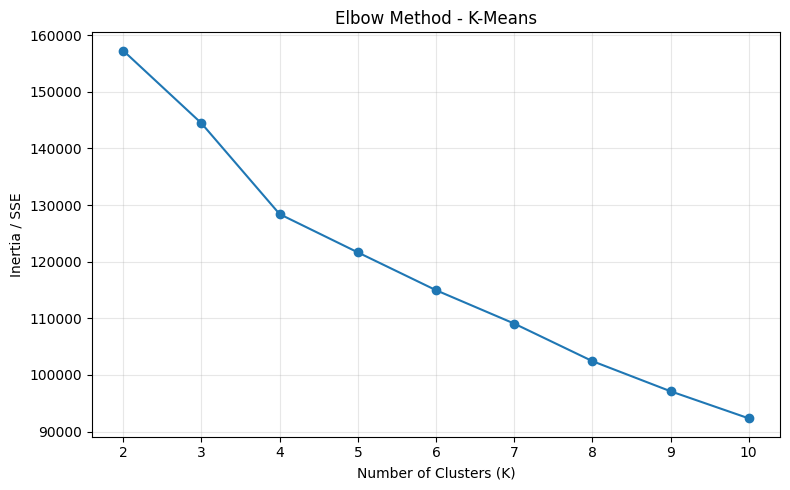

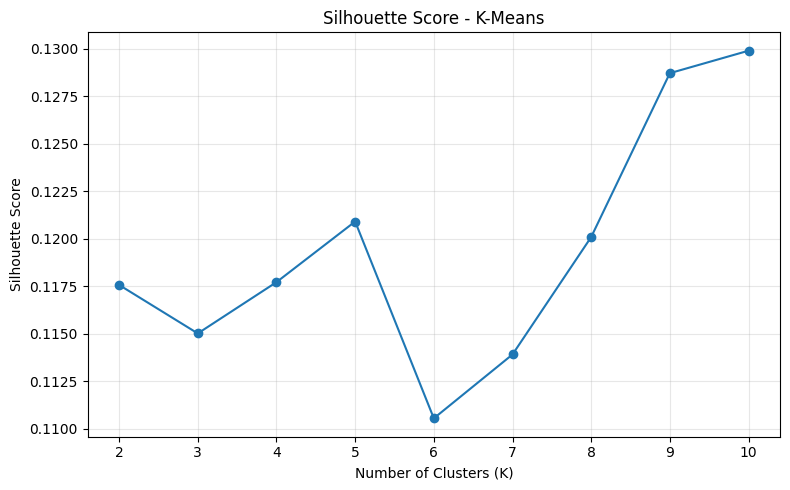


FINAL K-MEANS MODEL | K = 4

Cluster size:


,cluster_kmeans,record_count,record_percent
0,0,40332,40.33
1,1,5470,5.47
2,2,54161,54.16
3,3,31,0.03


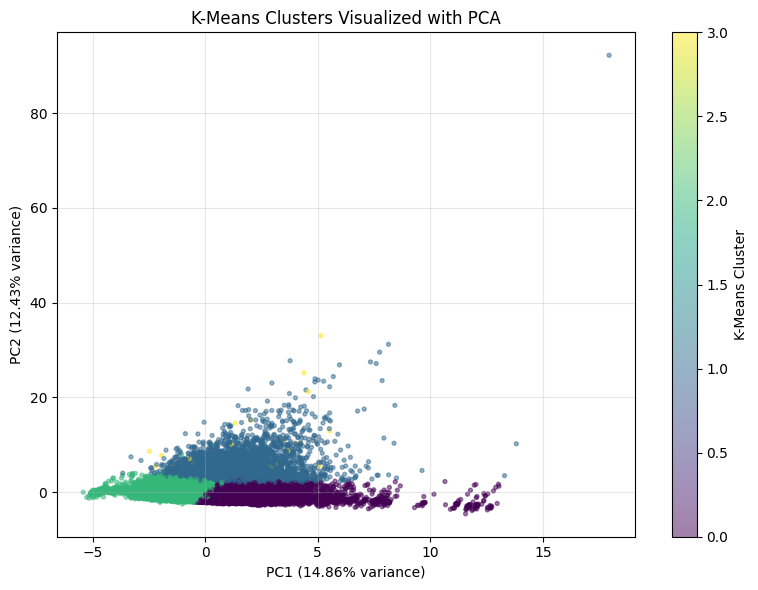


Cluster numeric profile:


,cluster_kmeans,record_count,record_percent,income_mean,income_median,income_relative_to_overall,debt_to_income_ratio_midpoint_mean,debt_to_income_ratio_midpoint_median,debt_to_income_ratio_midpoint_relative_to_overall,loan_amount_mean,...,tract_to_msa_income_percentage_relative_to_overall,tract_owner_occupied_units_mean,tract_owner_occupied_units_median,tract_owner_occupied_units_relative_to_overall,tract_one_to_four_family_homes_mean,tract_one_to_four_family_homes_median,tract_one_to_four_family_homes_relative_to_overall,tract_median_age_of_housing_units_mean,tract_median_age_of_housing_units_median,tract_median_age_of_housing_units_relative_to_overall
0,0,40332,40.33,210.780,95.0,high,38.301,39.5,medium,3.024769e+05,...,medium,1715.523,1623.0,high,2179.247,2091.0,high,31.102,29.0,medium
1,1,5470,5.47,166.793,114.0,medium,39.850,39.5,medium,5.326417e+05,...,medium,1230.593,1184.5,medium,1616.528,1576.0,medium,33.501,32.0,medium
2,2,54161,54.16,125.028,95.0,medium,39.136,39.5,medium,2.716070e+05,...,medium,824.570,862.0,low,1213.121,1255.0,low,38.424,40.0,medium
3,3,31,0.03,93.484,95.0,low,41.968,39.5,medium,3.616500e+07,...,medium,949.581,1098.0,medium,914.323,893.0,low,32.613,37.0,medium



Readable cluster profile with business interpretation:


,cluster_kmeans,cluster_name,record_count,record_percent,business_interpretation,avg_income,avg_loan_amount,avg_property_value,avg_combined_loan_to_value_ratio,avg_debt_to_income_ratio_midpoint,avg_interest_rate,avg_rate_spread,avg_tract_minority_population_percent,avg_tract_to_msa_income_percentage
0,0,Moderate Mixed Financial Profile Segment,40332,40.33,Cluster 0 is interpreted as 'Moderate Mixed Fi...,210.780,3.024769e+05,5.049291e+05,74.413,38.301,4.655,0.310,30.746,125.954
1,1,Moderate Mixed Financial Profile Segment,5470,5.47,Cluster 1 is interpreted as 'Moderate Mixed Fi...,166.793,5.326417e+05,6.992212e+05,79.353,39.850,4.835,0.370,42.580,118.452
2,2,Moderate Mixed Financial Profile Segment,54161,54.16,Cluster 2 is interpreted as 'Moderate Mixed Fi...,125.028,2.716070e+05,4.405998e+05,77.352,39.136,4.853,0.451,40.591,94.958
3,3,Financially Constrained Higher-Risk Segment,31,0.03,Cluster 3 is interpreted as 'Financially Const...,93.484,3.616500e+07,7.739145e+07,2781.752,41.968,4.023,0.357,43.409,117.806



Categorical distribution by cluster:


,cluster_kmeans,attribute,value,proportion,count
0,0,action_taken_label,Loan originated,53.32,21506
1,0,action_taken_label,Application denied,14.62,5897
2,0,action_taken_label,Application withdrawn by applicant,14.56,5872
3,0,action_taken_label,Purchased loan,9.40,3790
4,0,action_taken_label,File closed for incompleteness,5.18,2089
5,0,loan_type_label,Conventional,81.24,32765
6,0,loan_type_label,FHA,10.18,4107
7,0,loan_type_label,VA,7.98,3217
8,0,loan_type_label,RHS/FSA,0.60,243
9,0,loan_purpose_label,Home purchase,46.42,18723



DBSCAN NOISE DETECTION


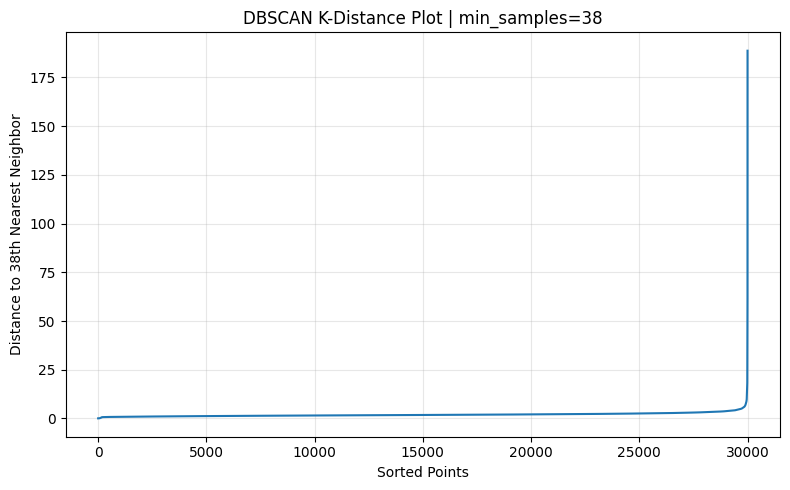

[INFO] DBSCAN min_samples: 38
[INFO] DBSCAN eps auto-estimate: 3.4065

DBSCAN summary:


,sample_size,min_samples,eps,dbscan_cluster_count_excluding_noise,noise_count,noise_percent
0,30000,38,3.406487,1,458,1.53


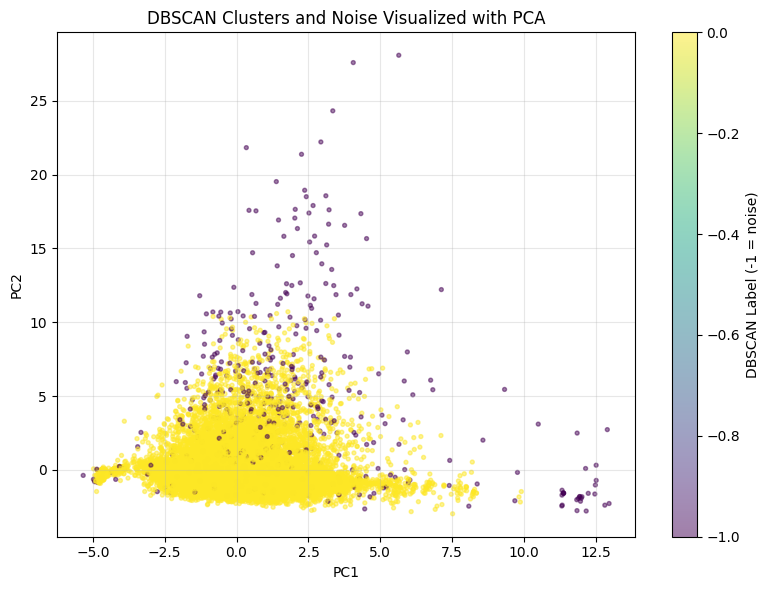


DBSCAN noise profile:


,count,mean,std,min,25%,50%,75%,max
income,458.0,2868.072,5.046434e+04,-138.00,95.000,130.000,284.750,1.077401e+06
debt_to_income_ratio_midpoint,458.0,38.697,1.115800e+01,10.00,39.500,39.500,46.500,6.500000e+01
loan_amount,458.0,1832598.253,5.910645e+06,5000.00,375000.000,615000.000,1125000.000,9.730500e+07
property_value,458.0,3053908.297,1.090462e+07,5000.00,455000.000,760000.000,1532500.000,1.379050e+08
combined_loan_to_value_ratio,458.0,98.822,4.640140e+02,0.65,70.000,78.408,89.990,9.999999e+03
interest_rate,458.0,5.012,2.492000e+00,0.00,3.631,4.750,5.875,1.450000e+01
rate_spread,458.0,0.362,2.249000e+00,-7.21,-0.176,0.368,0.818,8.496000e+00
loan_term,458.0,319.168,9.587600e+01,6.00,360.000,360.000,360.000,4.800000e+02
total_loan_costs,458.0,16086.246,1.295142e+04,0.00,5560.475,12974.555,23736.517,6.972065e+04
origination_charges,458.0,9890.233,1.064291e+04,0.00,1919.500,5640.610,15655.875,4.990813e+04



HIERARCHICAL CLUSTERING
[INFO] Generating dendrogram using linkage='ward'


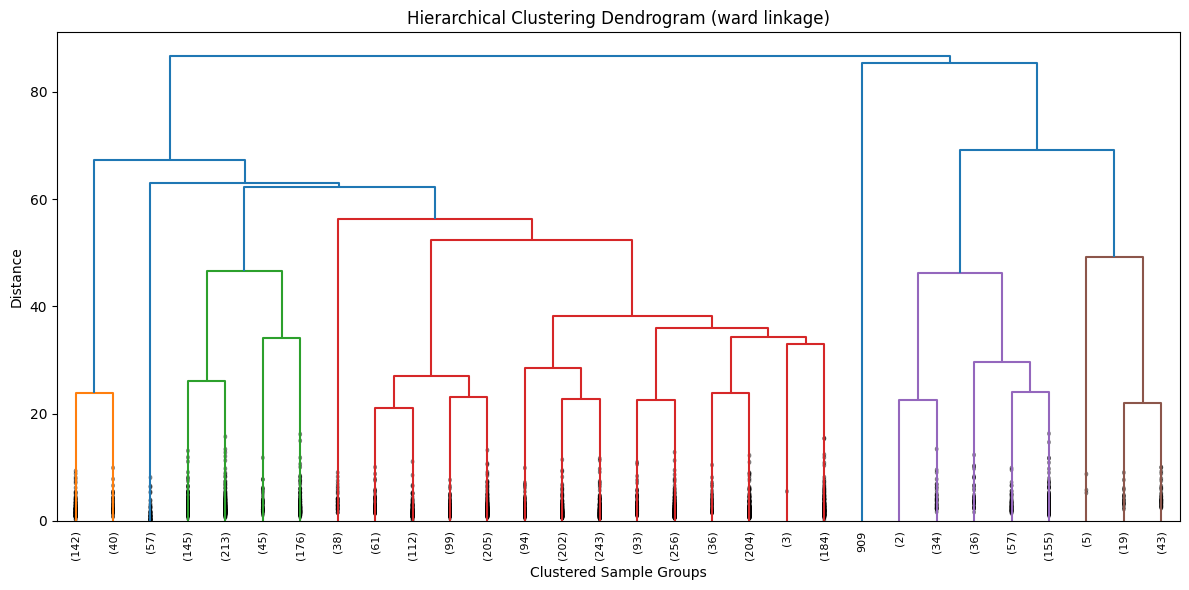

[INFO] Generating dendrogram using linkage='complete'


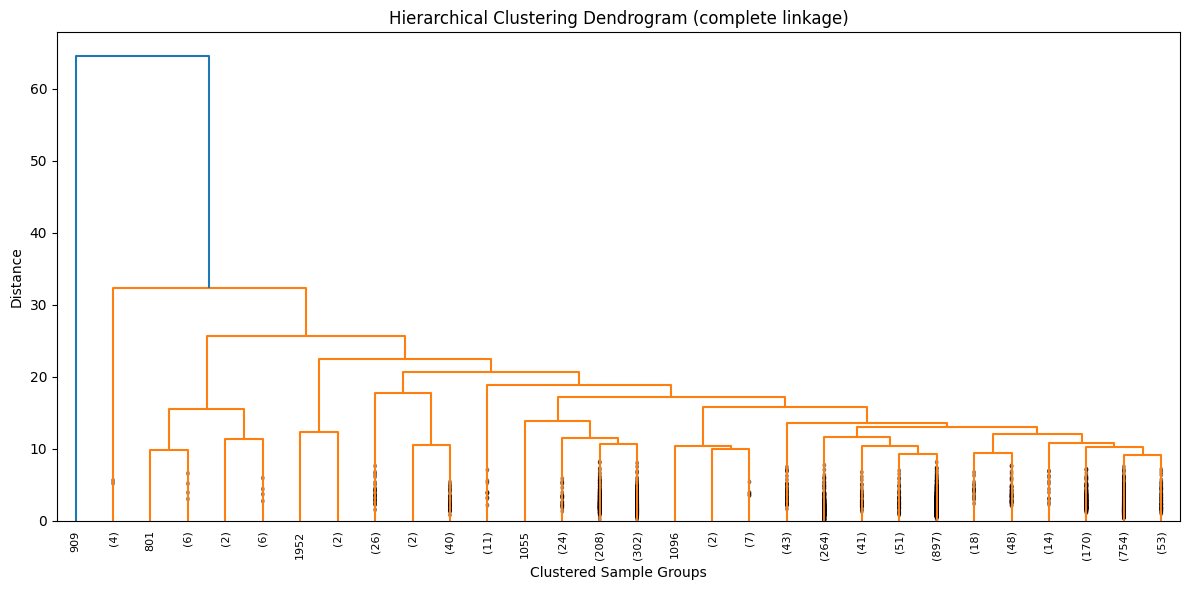

[INFO] Generating dendrogram using linkage='average'


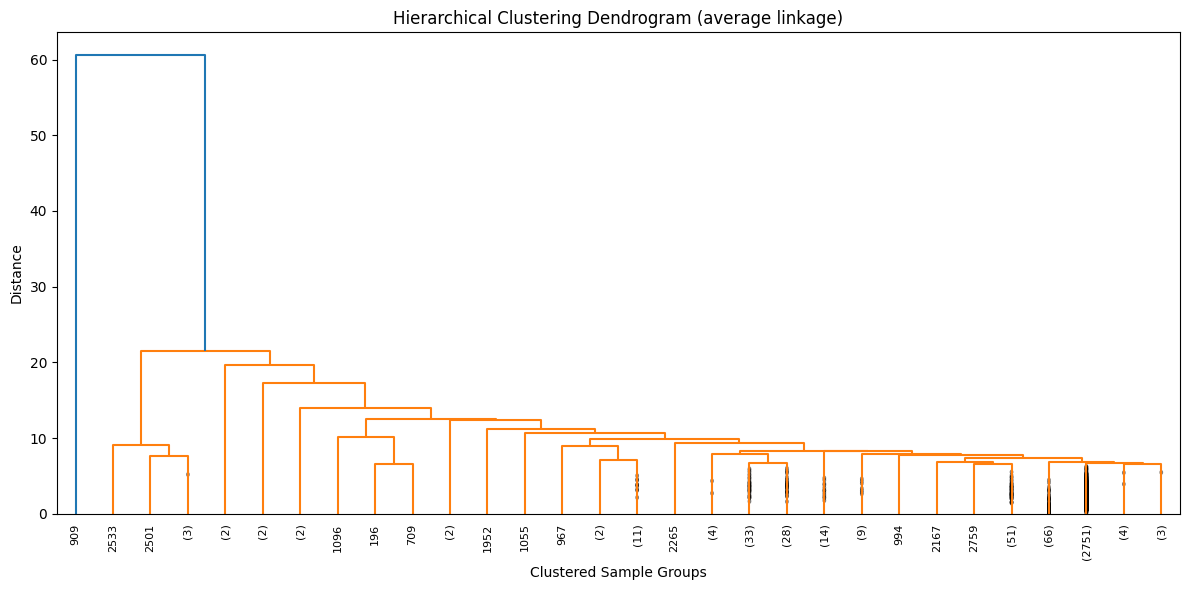

[INFO] Generating dendrogram using linkage='single'


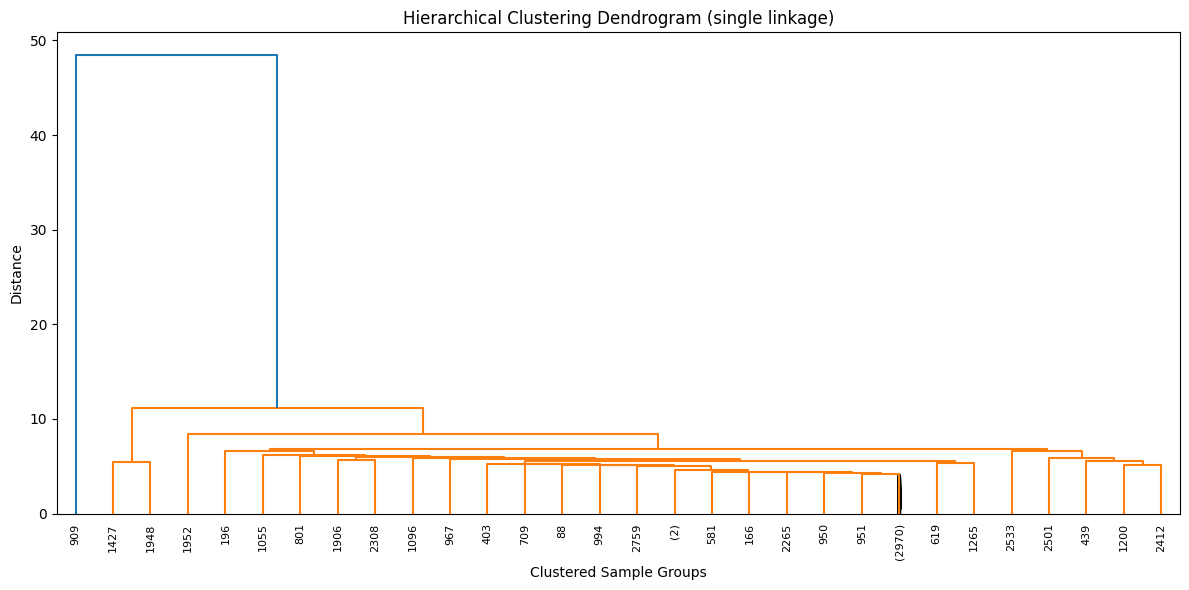


Hierarchical clustering comparison:


,linkage_method,sample_size,n_clusters,silhouette_score,davies_bouldin_score,calinski_harabasz_score,dendrogram_file
0,ward,3000,4,0.243977,1.284097,247.106997,D:\Projects\DM\HMDA Mortgage\reports\clusterin...
1,complete,3000,4,0.588982,0.571169,171.243325,D:\Projects\DM\HMDA Mortgage\reports\clusterin...
2,average,3000,4,0.741672,0.296024,152.524464,D:\Projects\DM\HMDA Mortgage\reports\clusterin...
3,single,3000,4,0.558827,0.280428,95.691651,D:\Projects\DM\HMDA Mortgage\reports\clusterin...



[DONE] Clustered dataset saved to: D:\Projects\DM\HMDA Mortgage\data\processed\hmda_2022_clustered_phase2.csv

PHASE 2 COMPLETED
{
  "input_clean_file": "D:\\Projects\\DM\\HMDA Mortgage\\data\\processed\\hmda_2022_clean_phase1.csv",
  "clustered_output_file": "D:\\Projects\\DM\\HMDA Mortgage\\data\\processed\\hmda_2022_clustered_phase2.csv",
  "rows": 99994,
  "features_used": [
    "income",
    "debt_to_income_ratio_midpoint",
    "loan_amount",
    "property_value",
    "combined_loan_to_value_ratio",
    "interest_rate",
    "rate_spread",
    "loan_term",
    "total_loan_costs",
    "origination_charges",
    "discount_points",
    "lender_credits",
    "tract_population",
    "tract_minority_population_percent",
    "ffiec_msa_md_median_family_income",
    "tract_to_msa_income_percentage",
    "tract_owner_occupied_units",
    "tract_one_to_four_family_homes",
    "tract_median_age_of_housing_units"
  ],
  "final_kmeans_k": 4,
  "kmeans_cluster_counts": {
    "0": 40332,
    "1"

In [5]:
# ============================================================
# PHASE 2: SEGMENTATION VIA CLUSTERING
# Project: HMDA Mortgage 2022
# Owner: Segmentation Specialist
#
# Goals:
# 1. Apply K-Means clustering to segment mortgage/application profiles
# 2. Determine optimal K using Elbow Method and Silhouette Score
# 3. Use DBSCAN to identify noise/outlier profiles
# 4. Apply Hierarchical Clustering and compare dendrogram linkage methods
# 5. Profile each cluster with business/financial interpretation
# 6. Deliverable: cluster labels, cluster profiles, visualizations, and report
# ============================================================

import os
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

from scipy.cluster.hierarchy import linkage, dendrogram

warnings.filterwarnings("ignore")

# ============================================================
# 0. AUTO-DETECT PROJECT ROOT
# ============================================================

def find_project_root():
    current = Path.cwd().resolve()

    for candidate in [current] + list(current.parents):
        if (candidate / "data").exists() and (candidate / "notebooks").exists():
            return candidate

    return current

PROJECT_ROOT = find_project_root()
os.chdir(PROJECT_ROOT)

print(f"[INFO] Project root detected: {PROJECT_ROOT}")

# ============================================================
# 1. PATH CONFIGURATION
# ============================================================

CLEAN_FILE = PROJECT_ROOT / "data" / "processed" / "hmda_2022_clean_phase1.csv"

DATA_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
REPORT_DIR = PROJECT_ROOT / "reports" / "clustering"
PLOT_DIR = REPORT_DIR / "plots"

DATA_PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

CLUSTERED_OUTPUT_FILE = DATA_PROCESSED_DIR / "hmda_2022_clustered_phase2.csv"
CLUSTER_FEATURE_DATA_FILE = DATA_PROCESSED_DIR / "hmda_2022_cluster_features_phase2.csv"

KMEANS_EVALUATION_FILE = REPORT_DIR / "phase2_kmeans_evaluation.csv"
CLUSTER_PROFILE_FILE = REPORT_DIR / "phase2_cluster_profile.csv"
CLUSTER_PROFILE_READABLE_FILE = REPORT_DIR / "phase2_cluster_profile_readable.csv"
DBSCAN_REPORT_FILE = REPORT_DIR / "phase2_dbscan_noise_report.csv"
HIERARCHICAL_REPORT_FILE = REPORT_DIR / "phase2_hierarchical_report.csv"
CLUSTERING_REPORT_FILE = REPORT_DIR / "phase2_clustering_report.md"

ELBOW_PLOT_FILE = PLOT_DIR / "phase2_elbow_method.png"
SILHOUETTE_PLOT_FILE = PLOT_DIR / "phase2_silhouette_score.png"
PCA_CLUSTER_PLOT_FILE = PLOT_DIR / "phase2_kmeans_pca_clusters.png"
DBSCAN_PCA_PLOT_FILE = PLOT_DIR / "phase2_dbscan_pca_noise.png"
KDIST_PLOT_FILE = PLOT_DIR / "phase2_dbscan_k_distance.png"

if not CLEAN_FILE.exists():
    raise FileNotFoundError(
        f"Clean dataset tidak ditemukan:\n{CLEAN_FILE}\n\n"
        "Jalankan Phase 1 dulu sampai menghasilkan hmda_2022_clean_phase1.csv."
    )

# ============================================================
# 2. LOAD CLEAN DATASET FROM PHASE 1
# ============================================================

df = pd.read_csv(CLEAN_FILE, low_memory=False)

print("=" * 80)
print("PHASE 2 - SEGMENTATION VIA CLUSTERING")
print("=" * 80)
print(f"Input file : {CLEAN_FILE}")
print(f"Rows       : {df.shape[0]:,}")
print(f"Columns    : {df.shape[1]:,}")

# ============================================================
# 3. SELECT CLUSTERING FEATURES
# ============================================================

# Feature yang merepresentasikan profil finansial, risiko, loan, dan area.
# Fitur sensitif seperti race, ethnicity, sex, applicant_age tidak dimasukkan untuk clustering utama.
# Demographic/sensitive tetap bisa dianalisis setelah cluster terbentuk untuk fairness-oriented EDA,
# tetapi tidak dijadikan input pembentuk cluster.

preferred_base_features = [
    # Borrower financial profile
    "income",
    "debt_to_income_ratio_midpoint",

    # Loan and property profile
    "loan_amount",
    "property_value",
    "combined_loan_to_value_ratio",
    "interest_rate",
    "rate_spread",
    "loan_term",

    # Cost/pricing features
    "total_loan_costs",
    "origination_charges",
    "discount_points",
    "lender_credits",

    # Census tract / area features
    "tract_population",
    "tract_minority_population_percent",
    "ffiec_msa_md_median_family_income",
    "tract_to_msa_income_percentage",
    "tract_owner_occupied_units",
    "tract_one_to_four_family_homes",
    "tract_median_age_of_housing_units"
]

available_base_features = [
    col for col in preferred_base_features
    if col in df.columns and pd.api.types.is_numeric_dtype(df[col])
]

if len(available_base_features) < 3:
    raise ValueError(
        "Fitur numerik untuk clustering terlalu sedikit. "
        "Pastikan Phase 1 berhasil melakukan parsing numeric columns."
    )

print("\n[INFO] Clustering base features used:")
for col in available_base_features:
    print(f"- {col}")

# Copy data fitur
X_raw = df[available_base_features].copy()

# Pastikan numerik dan handle missing
for col in X_raw.columns:
    X_raw[col] = pd.to_numeric(X_raw[col], errors="coerce")

X_raw = X_raw.replace([np.inf, -np.inf], np.nan)

# Impute missing dengan median
for col in X_raw.columns:
    median_value = X_raw[col].median()
    if pd.isna(median_value):
        median_value = 0
    X_raw[col] = X_raw[col].fillna(median_value)

# ============================================================
# 4. SCALE FEATURES
# ============================================================

scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(X_raw)

X_scaled = pd.DataFrame(
    X_scaled_array,
    columns=[f"{col}_scaled" for col in X_raw.columns],
    index=df.index
)

X_scaled.to_csv(CLUSTER_FEATURE_DATA_FILE, index=False)

print(f"\n[INFO] Scaled clustering feature dataset saved to: {CLUSTER_FEATURE_DATA_FILE}")
print(f"[INFO] Feature matrix shape: {X_scaled.shape[0]:,} rows x {X_scaled.shape[1]:,} columns")

# ============================================================
# 5. K-MEANS: ELBOW METHOD AND SILHOUETTE SCORE
# ============================================================

# Silhouette score mahal untuk 100k rows, jadi pakai sample untuk evaluasi.
EVAL_SAMPLE_SIZE = min(10_000, len(X_scaled))
eval_idx = X_scaled.sample(n=EVAL_SAMPLE_SIZE, random_state=42).index
X_eval = X_scaled.loc[eval_idx]

k_values = list(range(2, 11))
kmeans_eval_records = []

print("\n" + "=" * 80)
print("K-MEANS EVALUATION")
print("=" * 80)

for k in k_values:
    print(f"[INFO] Evaluating KMeans with k={k}")

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10,
        max_iter=300
    )

    labels_eval = kmeans.fit_predict(X_eval)

    inertia = kmeans.inertia_
    silhouette = silhouette_score(X_eval, labels_eval)
    davies_bouldin = davies_bouldin_score(X_eval, labels_eval)
    calinski_harabasz = calinski_harabasz_score(X_eval, labels_eval)

    kmeans_eval_records.append({
        "k": k,
        "inertia_sse": inertia,
        "silhouette_score": silhouette,
        "davies_bouldin_score": davies_bouldin,
        "calinski_harabasz_score": calinski_harabasz
    })

kmeans_eval_df = pd.DataFrame(kmeans_eval_records)

# Rank sederhana:
# - silhouette semakin tinggi semakin baik
# - DB index semakin rendah semakin baik
# - CH index semakin tinggi semakin baik
kmeans_eval_df["silhouette_rank"] = kmeans_eval_df["silhouette_score"].rank(ascending=False)
kmeans_eval_df["db_rank"] = kmeans_eval_df["davies_bouldin_score"].rank(ascending=True)
kmeans_eval_df["ch_rank"] = kmeans_eval_df["calinski_harabasz_score"].rank(ascending=False)
kmeans_eval_df["average_rank"] = kmeans_eval_df[["silhouette_rank", "db_rank", "ch_rank"]].mean(axis=1)

kmeans_eval_df = kmeans_eval_df.sort_values("k")
kmeans_eval_df.to_csv(KMEANS_EVALUATION_FILE, index=False)

print("\nK-Means evaluation result:")
display(kmeans_eval_df)

# Suggested K based on best average rank
suggested_k = int(kmeans_eval_df.sort_values("average_rank").iloc[0]["k"])

print(f"\n[INFO] Suggested K based on average internal validity rank: {suggested_k}")

# ============================================================
# 6. SAVE ELBOW AND SILHOUETTE PLOTS
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(kmeans_eval_df["k"], kmeans_eval_df["inertia_sse"], marker="o")
plt.title("Elbow Method - K-Means")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia / SSE")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(ELBOW_PLOT_FILE, dpi=150)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(kmeans_eval_df["k"], kmeans_eval_df["silhouette_score"], marker="o")
plt.title("Silhouette Score - K-Means")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(SILHOUETTE_PLOT_FILE, dpi=150)
plt.show()

# ============================================================
# 7. FINAL K-MEANS MODEL
# ============================================================

FINAL_K = suggested_k

print("\n" + "=" * 80)
print(f"FINAL K-MEANS MODEL | K = {FINAL_K}")
print("=" * 80)

final_kmeans = KMeans(
    n_clusters=FINAL_K,
    random_state=42,
    n_init=20,
    max_iter=500
)

df["cluster_kmeans"] = final_kmeans.fit_predict(X_scaled)

cluster_counts = df["cluster_kmeans"].value_counts().sort_index()
cluster_percent = (cluster_counts / len(df) * 100).round(2)

cluster_size_df = pd.DataFrame({
    "cluster_kmeans": cluster_counts.index,
    "record_count": cluster_counts.values,
    "record_percent": cluster_percent.values
})

print("\nCluster size:")
display(cluster_size_df)

# ============================================================
# 8. PCA VISUALIZATION FOR K-MEANS CLUSTERS
# ============================================================

pca = PCA(n_components=2, random_state=42)
pca_components = pca.fit_transform(X_scaled)

df["pca_1"] = pca_components[:, 0]
df["pca_2"] = pca_components[:, 1]

explained_var = pca.explained_variance_ratio_

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    df["pca_1"],
    df["pca_2"],
    c=df["cluster_kmeans"],
    s=8,
    alpha=0.5
)
plt.title("K-Means Clusters Visualized with PCA")
plt.xlabel(f"PC1 ({explained_var[0] * 100:.2f}% variance)")
plt.ylabel(f"PC2 ({explained_var[1] * 100:.2f}% variance)")
plt.colorbar(scatter, label="K-Means Cluster")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(PCA_CLUSTER_PLOT_FILE, dpi=150)
plt.show()

# ============================================================
# 9. CLUSTER PROFILING
# ============================================================

# Numeric profile: mean, median, min, max
profile_mean = df.groupby("cluster_kmeans")[available_base_features].mean().round(3)
profile_median = df.groupby("cluster_kmeans")[available_base_features].median().round(3)

# Overall mean untuk interpretasi relatif
overall_mean = df[available_base_features].mean()

cluster_profile_records = []

for cluster_id in sorted(df["cluster_kmeans"].unique()):
    cluster_df = df[df["cluster_kmeans"] == cluster_id]
    record_count = len(cluster_df)
    record_percent = round(record_count / len(df) * 100, 2)

    profile = {
        "cluster_kmeans": cluster_id,
        "record_count": record_count,
        "record_percent": record_percent
    }

    for col in available_base_features:
        cluster_mean = cluster_df[col].mean()
        cluster_median = cluster_df[col].median()
        global_mean = overall_mean[col]

        profile[f"{col}_mean"] = round(cluster_mean, 3)
        profile[f"{col}_median"] = round(cluster_median, 3)

        if pd.isna(global_mean) or global_mean == 0:
            profile[f"{col}_relative_to_overall"] = "neutral"
        elif cluster_mean >= global_mean * 1.25:
            profile[f"{col}_relative_to_overall"] = "high"
        elif cluster_mean <= global_mean * 0.75:
            profile[f"{col}_relative_to_overall"] = "low"
        else:
            profile[f"{col}_relative_to_overall"] = "medium"

    cluster_profile_records.append(profile)

cluster_profile_df = pd.DataFrame(cluster_profile_records)
cluster_profile_df.to_csv(CLUSTER_PROFILE_FILE, index=False)

print("\nCluster numeric profile:")
display(cluster_profile_df)

# ============================================================
# 10. BUSINESS INTERPRETATION / CLUSTER NAMING
# ============================================================

def safe_cluster_mean(cluster_df, col):
    if col in cluster_df.columns:
        return cluster_df[col].mean()
    return np.nan

def compare_to_overall(value, overall):
    if pd.isna(value) or pd.isna(overall) or overall == 0:
        return "medium"
    if value >= overall * 1.25:
        return "high"
    if value <= overall * 0.75:
        return "low"
    return "medium"

def build_cluster_interpretation(cluster_id, cluster_df, overall_df):
    """
    Membuat interpretasi bisnis sederhana berbasis profil finansial/risk.
    Output ini harus tetap divalidasi manual oleh tim.
    """

    metrics = {}

    for col in [
        "income",
        "loan_amount",
        "property_value",
        "combined_loan_to_value_ratio",
        "debt_to_income_ratio_midpoint",
        "interest_rate",
        "rate_spread",
        "tract_minority_population_percent",
        "tract_to_msa_income_percentage"
    ]:
        if col in cluster_df.columns:
            metrics[col] = compare_to_overall(cluster_df[col].mean(), overall_df[col].mean())

    income_level = metrics.get("income", "medium")
    loan_level = metrics.get("loan_amount", "medium")
    property_level = metrics.get("property_value", "medium")
    cltv_level = metrics.get("combined_loan_to_value_ratio", "medium")
    dti_level = metrics.get("debt_to_income_ratio_midpoint", "medium")
    interest_level = metrics.get("interest_rate", "medium")
    rate_spread_level = metrics.get("rate_spread", "medium")
    minority_level = metrics.get("tract_minority_population_percent", "medium")
    tract_income_level = metrics.get("tract_to_msa_income_percentage", "medium")

    risk_signals = []

    if dti_level == "high":
        risk_signals.append("high debt-to-income burden")
    if cltv_level == "high":
        risk_signals.append("high loan-to-value exposure")
    if interest_level == "high":
        risk_signals.append("higher interest rate")
    if rate_spread_level == "high":
        risk_signals.append("higher rate spread")
    if income_level == "low":
        risk_signals.append("lower borrower income")

    strength_signals = []

    if income_level == "high":
        strength_signals.append("higher borrower income")
    if cltv_level == "low":
        strength_signals.append("lower loan-to-value exposure")
    if dti_level == "low":
        strength_signals.append("lower debt burden")
    if tract_income_level == "high":
        strength_signals.append("higher-income tract context")

    # Naming logic
    if income_level == "high" and loan_level == "high" and property_level == "high":
        cluster_name = "High-Value / High-Income Mortgage Segment"
    elif income_level == "low" and (dti_level == "high" or cltv_level == "high"):
        cluster_name = "Financially Constrained Higher-Risk Segment"
    elif cltv_level == "high" and rate_spread_level == "high":
        cluster_name = "High Leverage and Higher Pricing Segment"
    elif dti_level == "low" and cltv_level == "low":
        cluster_name = "Lower-Risk Stable Borrower Segment"
    elif minority_level == "high" and tract_income_level == "low":
        cluster_name = "Lower-Income / High-Minority Tract Segment"
    elif loan_level == "low" and property_level == "low":
        cluster_name = "Lower-Value Mortgage Segment"
    else:
        cluster_name = "Moderate Mixed Financial Profile Segment"

    if len(risk_signals) == 0:
        risk_text = "No strong elevated risk signal from the selected numeric features."
    else:
        risk_text = "; ".join(risk_signals)

    if len(strength_signals) == 0:
        strength_text = "No strong financial strength signal from the selected numeric features."
    else:
        strength_text = "; ".join(strength_signals)

    interpretation = (
        f"Cluster {cluster_id} is interpreted as '{cluster_name}'. "
        f"It represents {len(cluster_df):,} records "
        f"({len(cluster_df) / len(overall_df) * 100:.2f}% of the sample). "
        f"Main risk signals: {risk_text}. "
        f"Main strength/context signals: {strength_text}."
    )

    return cluster_name, interpretation

readable_profile_records = []

for cluster_id in sorted(df["cluster_kmeans"].unique()):
    cluster_df = df[df["cluster_kmeans"] == cluster_id]

    cluster_name, interpretation = build_cluster_interpretation(
        cluster_id=cluster_id,
        cluster_df=cluster_df,
        overall_df=df
    )

    record = {
        "cluster_kmeans": cluster_id,
        "cluster_name": cluster_name,
        "record_count": len(cluster_df),
        "record_percent": round(len(cluster_df) / len(df) * 100, 2),
        "business_interpretation": interpretation
    }

    # Add important means
    for col in [
        "income",
        "loan_amount",
        "property_value",
        "combined_loan_to_value_ratio",
        "debt_to_income_ratio_midpoint",
        "interest_rate",
        "rate_spread",
        "tract_minority_population_percent",
        "tract_to_msa_income_percentage"
    ]:
        if col in cluster_df.columns:
            record[f"avg_{col}"] = round(cluster_df[col].mean(), 3)

    readable_profile_records.append(record)

cluster_profile_readable_df = pd.DataFrame(readable_profile_records)
cluster_profile_readable_df.to_csv(CLUSTER_PROFILE_READABLE_FILE, index=False)

print("\nReadable cluster profile with business interpretation:")
display(cluster_profile_readable_df)

# ============================================================
# 11. CATEGORICAL DISTRIBUTION BY CLUSTER
# ============================================================

categorical_profile_cols = [
    "action_taken_label",
    "loan_type_label",
    "loan_purpose_label",
    "lien_status_label",
    "derived_loan_product_type",
    "derived_dwelling_category",
    "occupancy_type",
    "debt_to_income_ratio_bucket"
]

categorical_profile_cols = [col for col in categorical_profile_cols if col in df.columns]

categorical_distribution_records = []

for cluster_id in sorted(df["cluster_kmeans"].unique()):
    cluster_df = df[df["cluster_kmeans"] == cluster_id]

    for col in categorical_profile_cols:
        top_values = cluster_df[col].astype(str).value_counts(normalize=True).head(5)

        for value, proportion in top_values.items():
            categorical_distribution_records.append({
                "cluster_kmeans": cluster_id,
                "attribute": col,
                "value": value,
                "proportion": round(proportion * 100, 2),
                "count": int((cluster_df[col].astype(str) == value).sum())
            })

categorical_distribution_df = pd.DataFrame(categorical_distribution_records)
CATEGORICAL_PROFILE_FILE = REPORT_DIR / "phase2_cluster_categorical_distribution.csv"
categorical_distribution_df.to_csv(CATEGORICAL_PROFILE_FILE, index=False)

print("\nCategorical distribution by cluster:")
display(categorical_distribution_df.head(30))

# ============================================================
# 12. DBSCAN FOR NOISE / OUTLIER PROFILES
# ============================================================

print("\n" + "=" * 80)
print("DBSCAN NOISE DETECTION")
print("=" * 80)

# DBSCAN mahal untuk 100k rows, jadi pakai sample maksimum.
DBSCAN_SAMPLE_SIZE = min(30_000, len(X_scaled))
dbscan_idx = X_scaled.sample(n=DBSCAN_SAMPLE_SIZE, random_state=42).index
X_dbscan = X_scaled.loc[dbscan_idx]

# k-distance plot untuk membantu estimasi eps.
# min_samples biasanya 2 * jumlah fitur atau minimal 10.
MIN_SAMPLES = max(10, 2 * X_scaled.shape[1])

neighbors = NearestNeighbors(n_neighbors=MIN_SAMPLES)
neighbors_fit = neighbors.fit(X_dbscan)
distances, indices = neighbors_fit.kneighbors(X_dbscan)

k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(8, 5))
plt.plot(k_distances)
plt.title(f"DBSCAN K-Distance Plot | min_samples={MIN_SAMPLES}")
plt.xlabel("Sorted Points")
plt.ylabel(f"Distance to {MIN_SAMPLES}th Nearest Neighbor")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(KDIST_PLOT_FILE, dpi=150)
plt.show()

# Auto eps heuristic: 95th percentile dari k-distance.
# Ini bukan aturan mutlak, tapi titik awal praktis.
EPS = float(np.percentile(k_distances, 95))

print(f"[INFO] DBSCAN min_samples: {MIN_SAMPLES}")
print(f"[INFO] DBSCAN eps auto-estimate: {EPS:.4f}")

dbscan = DBSCAN(
    eps=EPS,
    min_samples=MIN_SAMPLES,
    n_jobs=-1
)

dbscan_labels = dbscan.fit_predict(X_dbscan)

dbscan_result_df = pd.DataFrame({
    "original_index": dbscan_idx,
    "cluster_dbscan": dbscan_labels
})

df["cluster_dbscan"] = np.nan
df.loc[dbscan_idx, "cluster_dbscan"] = dbscan_labels

noise_count = int((dbscan_labels == -1).sum())
noise_percent = round(noise_count / len(dbscan_labels) * 100, 2)
dbscan_cluster_count = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)

dbscan_report_df = pd.DataFrame([{
    "sample_size": DBSCAN_SAMPLE_SIZE,
    "min_samples": MIN_SAMPLES,
    "eps": EPS,
    "dbscan_cluster_count_excluding_noise": dbscan_cluster_count,
    "noise_count": noise_count,
    "noise_percent": noise_percent
}])

dbscan_report_df.to_csv(DBSCAN_REPORT_FILE, index=False)

print("\nDBSCAN summary:")
display(dbscan_report_df)

# PCA visualization for DBSCAN sample
dbscan_pca = PCA(n_components=2, random_state=42)
dbscan_pca_components = dbscan_pca.fit_transform(X_dbscan)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    dbscan_pca_components[:, 0],
    dbscan_pca_components[:, 1],
    c=dbscan_labels,
    s=8,
    alpha=0.5
)
plt.title("DBSCAN Clusters and Noise Visualized with PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(scatter, label="DBSCAN Label (-1 = noise)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(DBSCAN_PCA_PLOT_FILE, dpi=150)
plt.show()

# Profile DBSCAN noise points
noise_original_indices = dbscan_result_df.loc[
    dbscan_result_df["cluster_dbscan"] == -1,
    "original_index"
].tolist()

if len(noise_original_indices) > 0:
    noise_profile = df.loc[noise_original_indices, available_base_features].describe().T.round(3)
    NOISE_PROFILE_FILE = REPORT_DIR / "phase2_dbscan_noise_profile.csv"
    noise_profile.to_csv(NOISE_PROFILE_FILE)
    print("\nDBSCAN noise profile:")
    display(noise_profile)
else:
    NOISE_PROFILE_FILE = REPORT_DIR / "phase2_dbscan_noise_profile.csv"
    pd.DataFrame().to_csv(NOISE_PROFILE_FILE)
    print("\n[INFO] No DBSCAN noise points detected with current eps/min_samples.")

# ============================================================
# 13. HIERARCHICAL CLUSTERING AND DENDROGRAMS
# ============================================================

print("\n" + "=" * 80)
print("HIERARCHICAL CLUSTERING")
print("=" * 80)

# Hierarchical clustering tidak scalable untuk 100k.
# Pakai sample kecil untuk dendrogram.
HIER_SAMPLE_SIZE = min(3_000, len(X_scaled))
hier_idx = X_scaled.sample(n=HIER_SAMPLE_SIZE, random_state=42).index
X_hier = X_scaled.loc[hier_idx]

linkage_methods = ["ward", "complete", "average", "single"]

hierarchical_records = []

for method in linkage_methods:
    print(f"[INFO] Generating dendrogram using linkage='{method}'")

    # ward hanya valid untuk Euclidean distance dan cocok untuk numeric scaled features.
    Z = linkage(X_hier, method=method)

    DENDROGRAM_FILE = PLOT_DIR / f"phase2_dendrogram_{method}.png"

    plt.figure(figsize=(12, 6))
    dendrogram(
        Z,
        truncate_mode="lastp",
        p=30,
        leaf_rotation=90,
        leaf_font_size=8,
        show_contracted=True
    )
    plt.title(f"Hierarchical Clustering Dendrogram ({method} linkage)")
    plt.xlabel("Clustered Sample Groups")
    plt.ylabel("Distance")
    plt.tight_layout()
    plt.savefig(DENDROGRAM_FILE, dpi=150)
    plt.show()

    # Agglomerative clustering dengan jumlah cluster sama seperti FINAL_K untuk perbandingan.
    if method == "ward":
        agg = AgglomerativeClustering(n_clusters=FINAL_K, linkage=method)
    else:
        agg = AgglomerativeClustering(n_clusters=FINAL_K, linkage=method)

    agg_labels = agg.fit_predict(X_hier)

    sil = silhouette_score(X_hier, agg_labels)
    db = davies_bouldin_score(X_hier, agg_labels)
    ch = calinski_harabasz_score(X_hier, agg_labels)

    hierarchical_records.append({
        "linkage_method": method,
        "sample_size": HIER_SAMPLE_SIZE,
        "n_clusters": FINAL_K,
        "silhouette_score": sil,
        "davies_bouldin_score": db,
        "calinski_harabasz_score": ch,
        "dendrogram_file": str(DENDROGRAM_FILE)
    })

hierarchical_report_df = pd.DataFrame(hierarchical_records)
hierarchical_report_df.to_csv(HIERARCHICAL_REPORT_FILE, index=False)

print("\nHierarchical clustering comparison:")
display(hierarchical_report_df)

# ============================================================
# 14. SAVE CLUSTERED DATASET
# ============================================================

df.to_csv(CLUSTERED_OUTPUT_FILE, index=False)

print(f"\n[DONE] Clustered dataset saved to: {CLUSTERED_OUTPUT_FILE}")

# ============================================================
# 15. WRITE PHASE 2 REPORT
# ============================================================

report_lines = []

report_lines.append("# Phase 2 Clustering Report")
report_lines.append("")
report_lines.append("## Project")
report_lines.append("HMDA Mortgage 2022 - Segmentation via Clustering")
report_lines.append("")
report_lines.append("## Phase Goal")
report_lines.append(
    "Identify naturally occurring groupings within the data and translate each group "
    "into a meaningful profile that describes real-world financial or mortgage behavior."
)
report_lines.append("")
report_lines.append("## Input Dataset")
report_lines.append(f"- Clean dataset from Phase 1: `{CLEAN_FILE}`")
report_lines.append(f"- Rows: {df.shape[0]:,}")
report_lines.append(f"- Columns: {df.shape[1]:,}")
report_lines.append("")
report_lines.append("## Clustering Feature Set")
report_lines.append("The clustering feature set focuses on financial, risk, loan, pricing, and tract-level characteristics.")
report_lines.append("")
for col in available_base_features:
    report_lines.append(f"- `{col}`")
report_lines.append("")
report_lines.append("Sensitive demographic fields such as race, ethnicity, sex, and applicant age were not used as clustering input. They may be analyzed after cluster creation for fairness-oriented EDA, but they should not be used to form predictive models.")
report_lines.append("")
report_lines.append("## K-Means Evaluation")
report_lines.append(f"- K values tested: {min(k_values)} to {max(k_values)}")
report_lines.append(f"- Evaluation sample size: {EVAL_SAMPLE_SIZE:,}")
report_lines.append(f"- Suggested K based on combined internal validity ranking: `{FINAL_K}`")
report_lines.append(f"- Evaluation file: `{KMEANS_EVALUATION_FILE}`")
report_lines.append(f"- Elbow plot: `{ELBOW_PLOT_FILE}`")
report_lines.append(f"- Silhouette plot: `{SILHOUETTE_PLOT_FILE}`")
report_lines.append("")
report_lines.append("## Final K-Means Cluster Sizes")
for _, row in cluster_size_df.iterrows():
    report_lines.append(
        f"- Cluster {int(row['cluster_kmeans'])}: "
        f"{int(row['record_count']):,} records "
        f"({row['record_percent']:.2f}%)"
    )
report_lines.append("")
report_lines.append("## Cluster Business Profiles")
for _, row in cluster_profile_readable_df.iterrows():
    report_lines.append(f"### Cluster {int(row['cluster_kmeans'])}: {row['cluster_name']}")
    report_lines.append(row["business_interpretation"])
    report_lines.append("")
report_lines.append("## DBSCAN Noise Detection")
report_lines.append(f"- DBSCAN sample size: {DBSCAN_SAMPLE_SIZE:,}")
report_lines.append(f"- min_samples: {MIN_SAMPLES}")
report_lines.append(f"- eps auto-estimate: {EPS:.4f}")
report_lines.append(f"- Number of clusters excluding noise: {dbscan_cluster_count}")
report_lines.append(f"- Noise points: {noise_count:,} ({noise_percent:.2f}%)")
report_lines.append(f"- DBSCAN report file: `{DBSCAN_REPORT_FILE}`")
report_lines.append(f"- K-distance plot: `{KDIST_PLOT_FILE}`")
report_lines.append(f"- DBSCAN PCA plot: `{DBSCAN_PCA_PLOT_FILE}`")
report_lines.append("")
report_lines.append("## Hierarchical Clustering")
report_lines.append(f"- Hierarchical sample size: {HIER_SAMPLE_SIZE:,}")
report_lines.append(f"- Linkage methods compared: {', '.join(linkage_methods)}")
report_lines.append(f"- Hierarchical comparison file: `{HIERARCHICAL_REPORT_FILE}`")
report_lines.append("")
report_lines.append("## Deliverables")
report_lines.append(f"- Clustered dataset: `{CLUSTERED_OUTPUT_FILE}`")
report_lines.append(f"- Cluster feature dataset: `{CLUSTER_FEATURE_DATA_FILE}`")
report_lines.append(f"- K-Means evaluation: `{KMEANS_EVALUATION_FILE}`")
report_lines.append(f"- Cluster numeric profile: `{CLUSTER_PROFILE_FILE}`")
report_lines.append(f"- Cluster readable profile: `{CLUSTER_PROFILE_READABLE_FILE}`")
report_lines.append(f"- Cluster categorical distribution: `{CATEGORICAL_PROFILE_FILE}`")
report_lines.append(f"- DBSCAN report: `{DBSCAN_REPORT_FILE}`")
report_lines.append(f"- Hierarchical report: `{HIERARCHICAL_REPORT_FILE}`")
report_lines.append("")
report_lines.append("## Notes for Next Phase")
report_lines.append("- Use `cluster_kmeans` as a segmentation label for visualization and business interpretation.")
report_lines.append("- Use DBSCAN noise points as candidate anomaly profiles.")
report_lines.append("- For Association Rule Mining, cluster labels can be included as categorical items, for example `cluster_kmeans=2`.")
report_lines.append("- Validate cluster names manually using domain knowledge before final reporting.")

CLUSTERING_REPORT_FILE.write_text("\n".join(report_lines), encoding="utf-8")

# ============================================================
# 16. FINAL SUMMARY
# ============================================================

phase2_summary = {
    "input_clean_file": str(CLEAN_FILE),
    "clustered_output_file": str(CLUSTERED_OUTPUT_FILE),
    "rows": int(df.shape[0]),
    "features_used": available_base_features,
    "final_kmeans_k": int(FINAL_K),
    "kmeans_cluster_counts": {
        str(k): int(v)
        for k, v in cluster_counts.to_dict().items()
    },
    "dbscan": {
        "sample_size": int(DBSCAN_SAMPLE_SIZE),
        "eps": EPS,
        "min_samples": int(MIN_SAMPLES),
        "cluster_count_excluding_noise": int(dbscan_cluster_count),
        "noise_count": int(noise_count),
        "noise_percent": float(noise_percent)
    },
    "hierarchical": {
        "sample_size": int(HIER_SAMPLE_SIZE),
        "linkage_methods": linkage_methods
    },
    "reports": {
        "phase2_report": str(CLUSTERING_REPORT_FILE),
        "kmeans_evaluation": str(KMEANS_EVALUATION_FILE),
        "cluster_profile": str(CLUSTER_PROFILE_FILE),
        "cluster_profile_readable": str(CLUSTER_PROFILE_READABLE_FILE),
        "dbscan_report": str(DBSCAN_REPORT_FILE),
        "hierarchical_report": str(HIERARCHICAL_REPORT_FILE)
    },
    "plots": {
        "elbow": str(ELBOW_PLOT_FILE),
        "silhouette": str(SILHOUETTE_PLOT_FILE),
        "kmeans_pca": str(PCA_CLUSTER_PLOT_FILE),
        "dbscan_k_distance": str(KDIST_PLOT_FILE),
        "dbscan_pca": str(DBSCAN_PCA_PLOT_FILE)
    }
}

print("\n" + "=" * 80)
print("PHASE 2 COMPLETED")
print("=" * 80)
print(json.dumps(phase2_summary, indent=2))

print("\nSaved files:")
print(f"- Clustered dataset              : {CLUSTERED_OUTPUT_FILE}")
print(f"- Cluster feature data           : {CLUSTER_FEATURE_DATA_FILE}")
print(f"- KMeans evaluation              : {KMEANS_EVALUATION_FILE}")
print(f"- Cluster profile                : {CLUSTER_PROFILE_FILE}")
print(f"- Readable cluster profile       : {CLUSTER_PROFILE_READABLE_FILE}")
print(f"- Categorical distribution       : {CATEGORICAL_PROFILE_FILE}")
print(f"- DBSCAN report                  : {DBSCAN_REPORT_FILE}")
print(f"- Hierarchical report            : {HIERARCHICAL_REPORT_FILE}")
print(f"- Phase 2 report                 : {CLUSTERING_REPORT_FILE}")

[INFO] mlxtend belum terinstall. Installing mlxtend...
[INFO] Project root detected: D:\Projects\DM\HMDA Mortgage
[INFO] Using Phase 2 clustered dataset: D:\Projects\DM\HMDA Mortgage\data\processed\hmda_2022_clustered_phase2.csv
PHASE 3 - ASSOCIATION RULE MINING
Input file : D:\Projects\DM\HMDA Mortgage\data\processed\hmda_2022_clustered_phase2.csv
Rows       : 99,994
Columns    : 205

[INFO] Binning completed.
Created new bin columns: ['ffiec_msa_md_median_family_income_bin', 'tract_population_bin']

[INFO] ARM item columns selected:
- action_taken_label | unique=8
- cluster_kmeans_label | unique=4
- loan_type_label | unique=4
- loan_purpose_label | unique=6
- lien_status_label | unique=2
- preapproval_label | unique=2
- conforming_loan_limit | unique=4
- construction_method_label | unique=2
- occupancy_type_label | unique=3
- derived_dwelling_category | unique=4
- reverse_mortgage_label | unique=3
- open_end_line_of_credit_label | unique=3
- business_or_commercial_purpose_label | uni

,item,support
0,negative_amortization_label=No,0.978999
1,other_nonamortizing_features_label=No,0.977789
2,reverse_mortgage_label=No,0.974768
3,preapproval_label=Preapproval not requested,0.970438
4,construction_method_label=Site-built,0.954497
5,conforming_loan_limit=C,0.951507
6,balloon_payment_label=No,0.950867
7,derived_dwelling_category=Single Family (1-4 U...,0.950247
8,business_or_commercial_purpose_label=No,0.934016
9,occupancy_type_label=Principal residence,0.901824



APRIORI SEARCH

[INFO] Running Apriori with min_support=0.03
[INFO] Frequent itemsets found: 45,195
[INFO] Generating rules with min_confidence=0.6
[INFO] Rules raw=69,236 | filtered=9,221 | useful=3,413

APRIORI SEARCH COMPLETED
Used min_support    : 0.03
Used min_confidence : 0.6
Frequent itemsets   : 45,195
All rules           : 69,236
Filtered rules      : 9,221
Selected rules      : 3,413

Top business rules:


,rank,rule,rule_category,antecedents_text,consequents_text,support,support_percent,confidence,confidence_percent,lift,leverage,conviction,zhangs_metric,business_commentary
51949,1,applicant_age=8888 AND occupancy_type_label=Pr...,Application outcome pattern,applicant_age=8888 AND occupancy_type_label=Pr...,action_taken_label=Purchased loan,0.080015,8.001480,0.985223,98.522349,10.160524,0.072140,61.112838,0.981274,Ketika kondisi [applicant_age=8888; occupancy_...
48458,2,applicant_age=8888 AND business_or_commercial_...,Application outcome pattern,applicant_age=8888 AND business_or_commercial_...,action_taken_label=Purchased loan,0.082295,8.229494,0.984683,98.468350,10.154955,0.074191,58.958255,0.983742,Ketika kondisi [applicant_age=8888; business_o...
40422,3,applicant_age=8888 AND balloon_payment_label=N...,Application outcome pattern,applicant_age=8888 AND balloon_payment_label=No,action_taken_label=Purchased loan,0.083825,8.382503,0.916566,91.656643,9.452469,0.074957,10.823391,0.984220,Ketika kondisi [applicant_age=8888; balloon_pa...
68844,4,applicant_age=8888 AND interest_rate_bin=inter...,Application outcome pattern,applicant_age=8888 AND interest_rate_bin=inter...,action_taken_label=Purchased loan,0.032192,3.219193,0.912933,91.293250,9.414993,0.028773,10.371656,0.926455,Ketika kondisi [applicant_age=8888; interest_r...
68608,5,applicant_age=8888 AND combined_loan_to_value_...,Application outcome pattern,applicant_age=8888 AND combined_loan_to_value_...,action_taken_label=Purchased loan,0.084525,8.452507,0.898384,89.838435,9.264959,0.075402,8.886763,0.984714,Ketika kondisi [applicant_age=8888; combined_l...
54990,6,applicant_age=8888 AND interest_only_payment_l...,Application outcome pattern,applicant_age=8888 AND interest_only_payment_l...,action_taken_label=Purchased loan,0.082935,8.293498,0.895669,89.566908,9.236957,0.073956,8.655480,0.982736,Ketika kondisi [applicant_age=8888; interest_o...
68713,7,applicant_age=8888 AND cluster_kmeans_label=Cl...,Application outcome pattern,applicant_age=8888 AND cluster_kmeans_label=Cl...,action_taken_label=Purchased loan,0.032552,3.255195,0.884271,88.427058,9.119405,0.028982,7.802978,0.924372,Ketika kondisi [applicant_age=8888; cluster_km...
35905,8,applicant_age=8888 AND conforming_loan_limit=C...,Application outcome pattern,applicant_age=8888 AND conforming_loan_limit=C,action_taken_label=Purchased loan,0.080895,8.089485,0.852551,85.255059,8.792280,0.071694,6.124366,0.979173,Ketika kondisi [applicant_age=8888; conforming...
68168,9,applicant_age=8888 AND loan_purpose_label=Home...,Application outcome pattern,applicant_age=8888 AND loan_purpose_label=Home...,action_taken_label=Purchased loan,0.061604,6.160370,0.850594,85.059376,8.772099,0.054581,6.044153,0.955181,Ketika kondisi [applicant_age=8888; loan_purpo...
44586,10,applicant_age=8888 AND derived_dwelling_catego...,Application outcome pattern,applicant_age=8888 AND derived_dwelling_catego...,action_taken_label=Purchased loan,0.081995,8.199492,0.843085,84.308483,8.694660,0.072564,5.754920,0.980330,Ketika kondisi [applicant_age=8888; derived_dw...


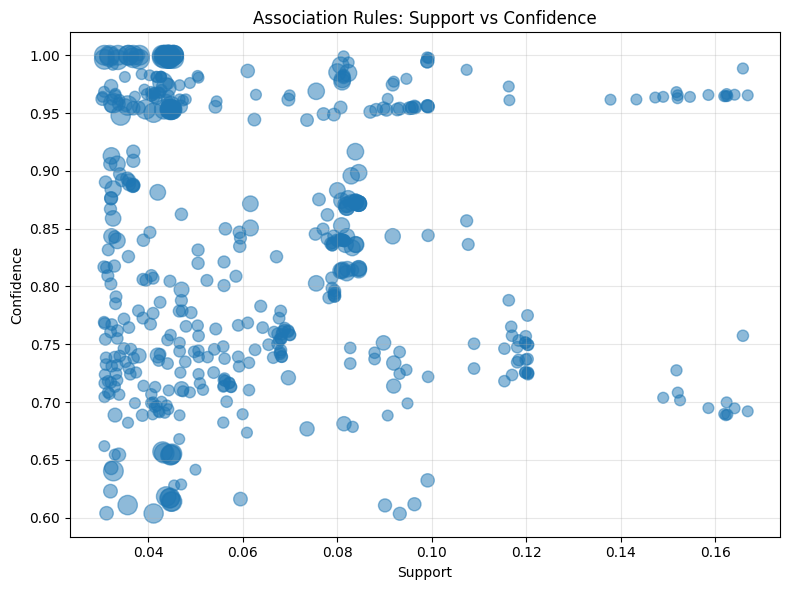

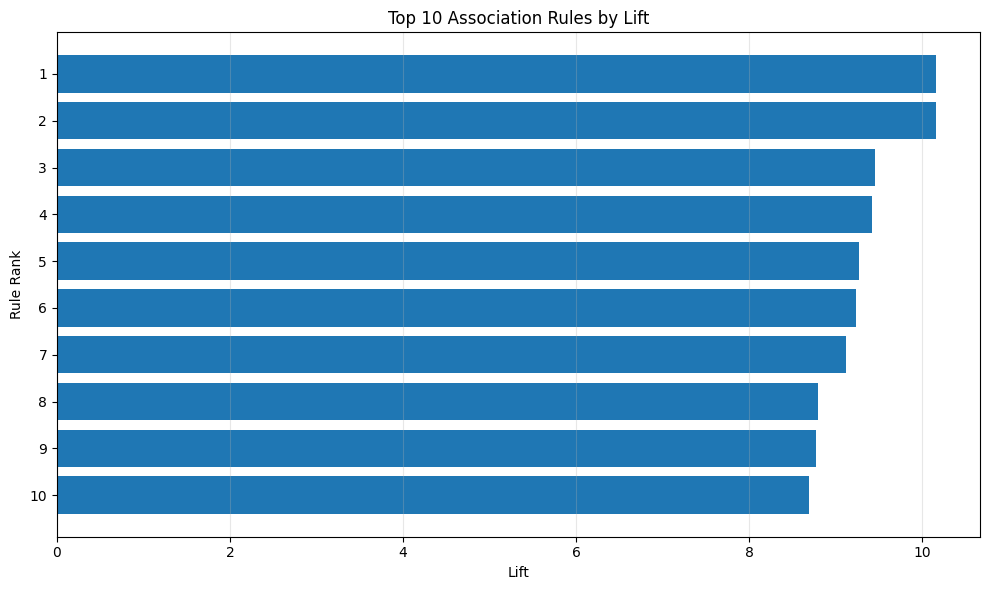


PHASE 3 COMPLETED
{
  "input_file": "D:\\Projects\\DM\\HMDA Mortgage\\data\\processed\\hmda_2022_clustered_phase2.csv",
  "rows_used_for_arm": 99994,
  "item_columns_used": [
    "action_taken_label",
    "cluster_kmeans_label",
    "loan_type_label",
    "loan_purpose_label",
    "lien_status_label",
    "preapproval_label",
    "conforming_loan_limit",
    "construction_method_label",
    "occupancy_type_label",
    "derived_dwelling_category",
    "reverse_mortgage_label",
    "open_end_line_of_credit_label",
    "business_or_commercial_purpose_label",
    "negative_amortization_label",
    "interest_only_payment_label",
    "balloon_payment_label",
    "other_nonamortizing_features_label",
    "debt_to_income_ratio_bucket",
    "income_bin",
    "loan_amount_bin",
    "property_value_bin",
    "combined_loan_to_value_ratio_bin",
    "interest_rate_bin",
    "rate_spread_bin",
    "tract_minority_population_percent_bin",
    "tract_to_msa_income_percentage_bin",
    "ffiec_msa_md_m

In [6]:
# ============================================================
# PHASE 3: ASSOCIATION RULE MINING
# Project: HMDA Mortgage 2022
# Owner: Pattern Analyst
#
# Goals:
# 1. Discretize continuous variables into meaningful categorical groups
# 2. Apply Apriori algorithm to discover frequent itemsets
# 3. Generate association rules with Support, Confidence, and Lift
# 4. Filter meaningful, non-trivial, high-lift rules
# 5. Document at least 10 rules with business interpretation
# 6. Deliverable: ranked rule table + business commentary
# ============================================================

import os
import sys
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# ============================================================
# 0. INSTALL / IMPORT MLXTEND
# ============================================================

try:
    from mlxtend.frequent_patterns import apriori, association_rules
except ImportError:
    print("[INFO] mlxtend belum terinstall. Installing mlxtend...")
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "mlxtend"])
    from mlxtend.frequent_patterns import apriori, association_rules

# ============================================================
# 1. AUTO-DETECT PROJECT ROOT
# ============================================================

def find_project_root():
    current = Path.cwd().resolve()

    for candidate in [current] + list(current.parents):
        if (candidate / "data").exists() and (candidate / "notebooks").exists():
            return candidate

    return current

PROJECT_ROOT = find_project_root()
os.chdir(PROJECT_ROOT)

print(f"[INFO] Project root detected: {PROJECT_ROOT}")

# ============================================================
# 2. PATH CONFIGURATION
# ============================================================

PHASE2_FILE = PROJECT_ROOT / "data" / "processed" / "hmda_2022_clustered_phase2.csv"
PHASE1_FILE = PROJECT_ROOT / "data" / "processed" / "hmda_2022_clean_phase1.csv"

DATA_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
REPORT_DIR = PROJECT_ROOT / "reports" / "association_rules"
PLOT_DIR = REPORT_DIR / "plots"

DATA_PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

ARM_TRANSACTION_FILE = DATA_PROCESSED_DIR / "hmda_2022_arm_transactions_phase3.csv"
FREQUENT_ITEMSETS_FILE = REPORT_DIR / "phase3_frequent_itemsets.csv"
ALL_RULES_FILE = REPORT_DIR / "phase3_association_rules_all.csv"
FILTERED_RULES_FILE = REPORT_DIR / "phase3_association_rules_filtered.csv"
TOP10_RULES_FILE = REPORT_DIR / "phase3_top10_business_rules.csv"
ARM_REPORT_FILE = REPORT_DIR / "phase3_association_rule_mining_report.md"

SUPPORT_CONFIDENCE_PLOT_FILE = PLOT_DIR / "phase3_support_confidence_scatter.png"
TOP10_LIFT_PLOT_FILE = PLOT_DIR / "phase3_top10_rules_by_lift.png"

if PHASE2_FILE.exists():
    INPUT_FILE = PHASE2_FILE
    print(f"[INFO] Using Phase 2 clustered dataset: {INPUT_FILE}")
elif PHASE1_FILE.exists():
    INPUT_FILE = PHASE1_FILE
    print(f"[WARNING] Phase 2 file not found. Using Phase 1 clean dataset: {INPUT_FILE}")
else:
    raise FileNotFoundError(
        "Tidak ditemukan file Phase 2 maupun Phase 1.\n"
        f"Expected Phase 2: {PHASE2_FILE}\n"
        f"Expected Phase 1: {PHASE1_FILE}"
    )

# ============================================================
# 3. LOAD DATASET
# ============================================================

df = pd.read_csv(INPUT_FILE, low_memory=False)

print("=" * 80)
print("PHASE 3 - ASSOCIATION RULE MINING")
print("=" * 80)
print(f"Input file : {INPUT_FILE}")
print(f"Rows       : {df.shape[0]:,}")
print(f"Columns    : {df.shape[1]:,}")

# ============================================================
# 4. CONFIGURATION
# ============================================================

RANDOM_STATE = 42

# Jika dataset lebih dari 100k, ARM bisa berat.
# Untuk dataset HMDA project ini, target utama adalah 100k records.
ARM_SAMPLE_SIZE = min(100_000, len(df))

# Sensitive demographic features boleh untuk analysis/EDA sesuai arahan dosen.
# Untuk classification/predictive modeling tetap harus dikeluarkan.
INCLUDE_SENSITIVE_FOR_EDA = True

# Denial reason bisa menciptakan rule yang trivial karena hanya muncul ketika denied.
# Default False agar rule utama tidak terlalu obvious.
INCLUDE_DENIAL_REASON_ITEMS = False

# Apriori config
MAX_ITEMSET_LENGTH = 3

# Akan dicoba otomatis dari tinggi ke rendah.
MIN_SUPPORT_CANDIDATES = [0.03, 0.02, 0.01, 0.005, 0.003]
MIN_CONFIDENCE_CANDIDATES = [0.60, 0.50, 0.40, 0.30]

MIN_LIFT_FILTER = 1.10
TOP_N_RULES = 10

# Pre-filter item sangat jarang untuk menjaga performa.
MIN_ITEM_SUPPORT_PREFILTER = 0.003

# ============================================================
# 5. HELPER FUNCTIONS
# ============================================================

def clean_text_value(x):
    if pd.isna(x):
        return "MISSING"

    x = str(x).strip()

    if x == "":
        return "BLANK"

    return x


def safe_qcut(series, q=4, prefix="bin"):
    valid = series.dropna()

    if valid.nunique() < 2:
        return pd.Series(["Unknown"] * len(series), index=series.index)

    try:
        temp = pd.qcut(series, q=q, duplicates="drop")
        categories_count = len(temp.cat.categories)

        if categories_count == 2:
            labels = [f"{prefix}_low", f"{prefix}_high"]
        elif categories_count == 3:
            labels = [f"{prefix}_low", f"{prefix}_medium", f"{prefix}_high"]
        elif categories_count == 4:
            labels = [f"{prefix}_low", f"{prefix}_medium", f"{prefix}_high", f"{prefix}_very_high"]
        else:
            labels = [f"{prefix}_{i + 1}" for i in range(categories_count)]

        return pd.qcut(series, q=q, labels=labels, duplicates="drop").astype(str).replace("nan", "Unknown")

    except Exception:
        return pd.Series(["Unknown"] * len(series), index=series.index)


def map_code(series, mapping):
    s = series.astype(str).str.strip()
    mapped = s.map(mapping)

    return mapped.fillna(
        s.apply(lambda v: "BLANK" if v == "" else f"code_{v}")
    )


def itemset_to_text(itemset):
    return " AND ".join(sorted(list(itemset)))


def item_feature_name(item):
    """
    Dari item seperti 'income_bin=income_low',
    ambil feature name 'income_bin'.
    """
    return str(item).split("=", 1)[0]


def item_value_name(item):
    """
    Dari item seperti 'income_bin=income_low',
    ambil value 'income_low'.
    """
    parts = str(item).split("=", 1)
    return parts[1] if len(parts) > 1 else str(item)


def is_missing_like_value(v):
    v = clean_text_value(v)

    missing_like = {
        "NA",
        "BLANK",
        "MISSING",
        "Exempt",
        "UNKNOWN",
        "Unknown",
        "nan",
        "None",
        "code_NA",
        "code_BLANK",
        "code_MISSING",
        "code_Exempt"
    }

    return v in missing_like


def feature_family(feature):
    """
    Mengelompokkan fitur yang konsepnya mirip agar rule redundant bisa difilter.
    Contoh:
    loan_type_label dan derived_loan_product_type sama-sama keluarga loan_product.
    """
    f = feature.lower()

    if "loan_type" in f or "loan_product" in f or "lien_status" in f:
        return "loan_product"

    if "action_taken" in f or "target_denied" in f or "target_originated" in f:
        return "action_outcome"

    if "race" in f:
        return "race"

    if "ethnicity" in f:
        return "ethnicity"

    if "sex" in f:
        return "sex"

    if "age" in f and "housing" not in f:
        return "applicant_age"

    if "denial_reason" in f:
        return "denial_reason"

    if "debt_to_income" in f:
        return "dti"

    if "interest_rate" in f or "rate_spread" in f:
        return "pricing"

    if "income_bin" in f or f == "income":
        return "borrower_income"

    if "loan_amount" in f:
        return "loan_amount"

    if "property_value" in f:
        return "property_value"

    if "tract_minority" in f or "tract_to_msa_income" in f:
        return "tract_demographic_context"

    if "cluster_kmeans" in f:
        return "cluster"

    return feature


def is_trivial_or_redundant_rule(row):
    antecedent_items = list(row["antecedents"])
    consequent_items = list(row["consequents"])

    antecedent_features = [item_feature_name(item) for item in antecedent_items]
    consequent_features = [item_feature_name(item) for item in consequent_items]

    # Rule dari feature yang sama ke dirinya sendiri tidak meaningful.
    if len(set(antecedent_features).intersection(set(consequent_features))) > 0:
        return True

    antecedent_families = {feature_family(f) for f in antecedent_features}
    consequent_families = {feature_family(f) for f in consequent_features}

    overlapping_families = antecedent_families.intersection(consequent_families)

    # Beberapa keluarga fitur sangat redundant bila muncul di dua sisi rule.
    redundant_families = {
        "loan_product",
        "race",
        "ethnicity",
        "sex",
        "applicant_age",
        "denial_reason"
    }

    if len(overlapping_families.intersection(redundant_families)) > 0:
        return True

    return False


def call_association_rules(frequent_itemsets, confidence_threshold, total_itemsets_count):
    """
    Kompatibel untuk beberapa versi mlxtend.
    """
    try:
        return association_rules(
            frequent_itemsets,
            metric="confidence",
            min_threshold=confidence_threshold
        )
    except TypeError:
        return association_rules(
            frequent_itemsets,
            num_itemsets=total_itemsets_count,
            metric="confidence",
            min_threshold=confidence_threshold
        )


def prepare_rules_dataframe(rules_df):
    if rules_df.empty:
        return rules_df.copy()

    rules = rules_df.copy()

    rules["antecedents_text"] = rules["antecedents"].apply(itemset_to_text)
    rules["consequents_text"] = rules["consequents"].apply(itemset_to_text)
    rules["rule"] = rules["antecedents_text"] + " -> " + rules["consequents_text"]

    rules["antecedent_len"] = rules["antecedents"].apply(len)
    rules["consequent_len"] = rules["consequents"].apply(len)

    rules["is_trivial_or_redundant"] = rules.apply(is_trivial_or_redundant_rule, axis=1)

    rules["support_percent"] = rules["support"] * 100
    rules["confidence_percent"] = rules["confidence"] * 100
    rules["consequent_support_percent"] = rules["consequent support"] * 100

    # Skor ranking gabungan.
    # Lift utama, tetapi confidence dan support tetap ikut agar rule tidak terlalu rare.
    rules["interestingness_score"] = (
        rules["lift"] * 0.60
        + rules["confidence"] * 0.25
        + rules["support"] * 0.15
    )

    return rules


def rule_category(consequent_text):
    c = consequent_text.lower()

    if "action_taken_label" in c:
        return "Application outcome pattern"

    if "cluster_kmeans_label" in c:
        return "Segmentation pattern"

    if "debt_to_income_ratio_bucket" in c:
        return "Risk / DTI pattern"

    if "interest_rate_bin" in c or "rate_spread_bin" in c:
        return "Pricing pattern"

    if "loan_type_label" in c or "loan_purpose_label" in c:
        return "Loan characteristic pattern"

    if "income_bin" in c or "loan_amount_bin" in c or "property_value_bin" in c:
        return "Financial profile pattern"

    return "General co-occurrence pattern"


def make_business_commentary(row, total_records):
    antecedent = row["antecedents_text"].replace(" AND ", "; ")
    consequent = row["consequents_text"]

    support_pct = row["support_percent"]
    confidence_pct = row["confidence_percent"]
    lift = row["lift"]
    consequent_support_pct = row["consequent_support_percent"]

    estimated_count = int(round(row["support"] * total_records, 0))

    if lift > 1:
        lift_text = f"{lift:.2f}x lebih sering dibanding baseline consequent"
    elif lift < 1:
        lift_text = f"{lift:.2f}x dari baseline consequent, sehingga cenderung lebih rendah dari baseline"
    else:
        lift_text = "setara dengan baseline consequent"

    commentary = (
        f"Ketika kondisi [{antecedent}] muncul, maka [{consequent}] terjadi dengan confidence "
        f"{confidence_pct:.2f}%. Rule ini mencakup sekitar {support_pct:.2f}% data "
        f"(estimasi {estimated_count:,} records dari sample). "
        f"Baseline consequent adalah {consequent_support_pct:.2f}%, sehingga lift {lift:.2f} berarti "
        f"{lift_text}. Interpretasi ini menunjukkan pola ko-occurence, bukan hubungan sebab-akibat."
    )

    return commentary


# ============================================================
# 6. BASIC CATEGORICAL MAPPING IF NEEDED
# ============================================================

ACTION_TAKEN_MAP = {
    "1": "Loan originated",
    "2": "Application approved but not accepted",
    "3": "Application denied",
    "4": "Application withdrawn by applicant",
    "5": "File closed for incompleteness",
    "6": "Purchased loan",
    "7": "Preapproval request denied",
    "8": "Preapproval request approved but not accepted"
}

LOAN_TYPE_MAP = {
    "1": "Conventional",
    "2": "FHA",
    "3": "VA",
    "4": "RHS/FSA"
}

LOAN_PURPOSE_MAP = {
    "1": "Home purchase",
    "2": "Home improvement",
    "31": "Refinancing",
    "32": "Cash-out refinancing",
    "4": "Other purpose",
    "5": "Not applicable"
}

LIEN_STATUS_MAP = {
    "1": "First lien",
    "2": "Subordinate lien"
}

YES_NO_MAP = {
    "1": "Yes",
    "2": "No"
}

PREAPPROVAL_MAP = {
    "1": "Preapproval requested",
    "2": "Preapproval not requested"
}

CONSTRUCTION_METHOD_MAP = {
    "1": "Site-built",
    "2": "Manufactured home"
}

OCCUPANCY_TYPE_MAP = {
    "1": "Principal residence",
    "2": "Second residence",
    "3": "Investment property"
}

if "action_taken_label" not in df.columns and "action_taken" in df.columns:
    df["action_taken_label"] = map_code(df["action_taken"], ACTION_TAKEN_MAP)

if "loan_type_label" not in df.columns and "loan_type" in df.columns:
    df["loan_type_label"] = map_code(df["loan_type"], LOAN_TYPE_MAP)

if "loan_purpose_label" not in df.columns and "loan_purpose" in df.columns:
    df["loan_purpose_label"] = map_code(df["loan_purpose"], LOAN_PURPOSE_MAP)

if "lien_status_label" not in df.columns and "lien_status" in df.columns:
    df["lien_status_label"] = map_code(df["lien_status"], LIEN_STATUS_MAP)

if "preapproval_label" not in df.columns and "preapproval" in df.columns:
    df["preapproval_label"] = map_code(df["preapproval"], PREAPPROVAL_MAP)

if "construction_method_label" not in df.columns and "construction_method" in df.columns:
    df["construction_method_label"] = map_code(df["construction_method"], CONSTRUCTION_METHOD_MAP)

if "occupancy_type_label" not in df.columns and "occupancy_type" in df.columns:
    df["occupancy_type_label"] = map_code(df["occupancy_type"], OCCUPANCY_TYPE_MAP)

for col in [
    "reverse_mortgage",
    "open_end_line_of_credit",
    "business_or_commercial_purpose",
    "negative_amortization",
    "interest_only_payment",
    "balloon_payment",
    "other_nonamortizing_features"
]:
    label_col = f"{col}_label"

    if label_col not in df.columns and col in df.columns:
        df[label_col] = map_code(df[col], YES_NO_MAP)

if "cluster_kmeans" in df.columns and "cluster_kmeans_label" not in df.columns:
    df["cluster_kmeans_label"] = df["cluster_kmeans"].apply(
        lambda x: f"Cluster_{int(x)}" if pd.notna(x) else "MISSING"
    )

# ============================================================
# 7. DISCRETIZE CONTINUOUS VARIABLES
# ============================================================

# Jika bin dari Phase 1 sudah ada, tidak dibuat ulang.
# Jika belum ada, dibuat di Phase 3.

binning_specs = {
    "income": "income",
    "loan_amount": "loan_amount",
    "property_value": "property_value",
    "combined_loan_to_value_ratio": "cltv",
    "interest_rate": "interest_rate",
    "rate_spread": "rate_spread",
    "tract_minority_population_percent": "tract_minority",
    "tract_to_msa_income_percentage": "tract_to_msa_income",
    "ffiec_msa_md_median_family_income": "msa_median_income",
    "tract_population": "tract_population"
}

created_bins = []

for col, prefix in binning_specs.items():
    bin_col = f"{col}_bin"

    if col in df.columns and bin_col not in df.columns:
        numeric_series = pd.to_numeric(df[col], errors="coerce")
        df[bin_col] = safe_qcut(numeric_series, q=4, prefix=prefix)
        created_bins.append(bin_col)

print("\n[INFO] Binning completed.")
print(f"Created new bin columns: {created_bins if created_bins else 'No new bins; existing bins used.'}")

# ============================================================
# 8. SELECT COLUMNS FOR ASSOCIATION RULE MINING
# ============================================================

base_item_cols = [
    # Outcome
    "action_taken_label",

    # Cluster from Phase 2
    "cluster_kmeans_label",

    # Loan characteristics
    "loan_type_label",
    "loan_purpose_label",
    "lien_status_label",
    "preapproval_label",
    "conforming_loan_limit",
    "construction_method_label",
    "occupancy_type_label",
    "derived_dwelling_category",

    # Product features
    "reverse_mortgage_label",
    "open_end_line_of_credit_label",
    "business_or_commercial_purpose_label",
    "negative_amortization_label",
    "interest_only_payment_label",
    "balloon_payment_label",
    "other_nonamortizing_features_label",

    # Risk / financial bins
    "debt_to_income_ratio_bucket",
    "income_bin",
    "loan_amount_bin",
    "property_value_bin",
    "combined_loan_to_value_ratio_bin",
    "interest_rate_bin",
    "rate_spread_bin",

    # Area / tract context
    "tract_minority_population_percent_bin",
    "tract_to_msa_income_percentage_bin",
    "ffiec_msa_md_median_family_income_bin",
    "tract_population_bin"
]

sensitive_item_cols = [
    "derived_race",
    "derived_ethnicity",
    "derived_sex",
    "applicant_age",
    "applicant_age_above_62"
]

denial_reason_cols = [
    "denial_reason_1_label",
    "denial_reason_2_label",
    "denial_reason_3_label",
    "denial_reason_4_label"
]

candidate_item_cols = base_item_cols.copy()

if INCLUDE_SENSITIVE_FOR_EDA:
    candidate_item_cols.extend(sensitive_item_cols)

if INCLUDE_DENIAL_REASON_ITEMS:
    candidate_item_cols.extend(denial_reason_cols)

candidate_item_cols = [col for col in candidate_item_cols if col in df.columns]

# Hindari kolom dengan terlalu banyak unique values.
MAX_UNIQUE_PER_ITEM_COLUMN = 50

item_cols = []

for col in candidate_item_cols:
    n_unique = df[col].astype(str).nunique(dropna=False)

    if 2 <= n_unique <= MAX_UNIQUE_PER_ITEM_COLUMN:
        item_cols.append(col)

print("\n[INFO] ARM item columns selected:")
for col in item_cols:
    print(f"- {col} | unique={df[col].astype(str).nunique(dropna=False)}")

if len(item_cols) < 2:
    raise ValueError("Tidak cukup kolom kategorikal untuk Association Rule Mining.")

# ============================================================
# 9. CREATE ARM TRANSACTION DATA
# ============================================================

if len(df) > ARM_SAMPLE_SIZE:
    df_arm = df.sample(n=ARM_SAMPLE_SIZE, random_state=RANDOM_STATE).copy()
else:
    df_arm = df.copy()

print("\n[INFO] ARM transaction source:")
print(f"Rows used for ARM: {len(df_arm):,}")

transaction_df = pd.DataFrame(index=df_arm.index)

for col in item_cols:
    values = df_arm[col].apply(clean_text_value)

    transaction_df[col] = values.apply(
        lambda v: np.nan if is_missing_like_value(v) else f"{col}={v}"
    )

transaction_df.to_csv(ARM_TRANSACTION_FILE, index=False)

print(f"[INFO] ARM transaction file saved: {ARM_TRANSACTION_FILE}")

# ============================================================
# 10. ONE-HOT ENCODE TRANSACTIONS
# ============================================================

item_matrix = pd.get_dummies(
    transaction_df,
    prefix="",
    prefix_sep="",
    dummy_na=False,
    dtype=bool
)

# Remove duplicate columns if any
item_matrix = item_matrix.loc[:, ~item_matrix.columns.duplicated()]

# Pre-filter very rare items
item_support = item_matrix.mean().sort_values(ascending=False)
frequent_single_items = item_support[item_support >= MIN_ITEM_SUPPORT_PREFILTER].index.tolist()

item_matrix = item_matrix[frequent_single_items]

print("\n[INFO] Item matrix created:")
print(f"Rows              : {item_matrix.shape[0]:,}")
print(f"Item columns      : {item_matrix.shape[1]:,}")
print(f"Min item support  : {MIN_ITEM_SUPPORT_PREFILTER}")

print("\nTop 20 single items by support:")
display(
    item_support.head(20).reset_index().rename(
        columns={"index": "item", 0: "support"}
    )
)

if item_matrix.shape[1] < 2:
    raise ValueError("Item matrix terlalu kecil setelah pre-filter. Turunkan MIN_ITEM_SUPPORT_PREFILTER.")

# ============================================================
# 11. APRIORI + ASSOCIATION RULES WITH AUTO THRESHOLD
# ============================================================

best_result = None

print("\n" + "=" * 80)
print("APRIORI SEARCH")
print("=" * 80)

for min_support in MIN_SUPPORT_CANDIDATES:
    print(f"\n[INFO] Running Apriori with min_support={min_support}")

    frequent_itemsets = apriori(
        item_matrix,
        min_support=min_support,
        use_colnames=True,
        max_len=MAX_ITEMSET_LENGTH,
        low_memory=True
    )

    if frequent_itemsets.empty:
        print(f"[WARNING] No frequent itemsets found at support={min_support}")
        continue

    frequent_itemsets["itemset_len"] = frequent_itemsets["itemsets"].apply(len)
    print(f"[INFO] Frequent itemsets found: {len(frequent_itemsets):,}")

    for min_confidence in MIN_CONFIDENCE_CANDIDATES:
        print(f"[INFO] Generating rules with min_confidence={min_confidence}")

        rules_raw = call_association_rules(
            frequent_itemsets=frequent_itemsets,
            confidence_threshold=min_confidence,
            total_itemsets_count=len(item_matrix)
        )

        if rules_raw.empty:
            print("[WARNING] No rules generated.")
            continue

        rules = prepare_rules_dataframe(rules_raw)

        filtered_rules = rules[
            (rules["lift"] >= MIN_LIFT_FILTER)
            & (rules["confidence"] >= min_confidence)
            & (rules["consequent_len"] == 1)
            & (~rules["is_trivial_or_redundant"])
        ].copy()

        # Prefer rules with business-useful consequents.
        useful_consequent_pattern = (
            "action_taken_label="
            "|cluster_kmeans_label="
            "|debt_to_income_ratio_bucket="
            "|interest_rate_bin="
            "|rate_spread_bin="
            "|loan_type_label="
            "|loan_purpose_label="
        )

        useful_rules = filtered_rules[
            filtered_rules["consequents_text"].str.contains(
                useful_consequent_pattern,
                regex=True,
                na=False
            )
        ].copy()

        if len(useful_rules) >= TOP_N_RULES:
            selected_rules = useful_rules.copy()
        else:
            selected_rules = filtered_rules.copy()

        selected_rules = selected_rules.sort_values(
            ["lift", "confidence", "support"],
            ascending=[False, False, False]
        )

        print(
            f"[INFO] Rules raw={len(rules):,} | "
            f"filtered={len(filtered_rules):,} | "
            f"useful={len(useful_rules):,}"
        )

        current_result = {
            "min_support": min_support,
            "min_confidence": min_confidence,
            "frequent_itemsets": frequent_itemsets,
            "rules": rules,
            "filtered_rules": filtered_rules,
            "selected_rules": selected_rules
        }

        if best_result is None:
            best_result = current_result

        if len(selected_rules) >= TOP_N_RULES:
            best_result = current_result
            break

    if best_result is not None and len(best_result["selected_rules"]) >= TOP_N_RULES:
        break

if best_result is None:
    raise ValueError(
        "Tidak ada association rules yang berhasil dibuat. "
        "Coba turunkan MIN_SUPPORT_CANDIDATES atau MIN_CONFIDENCE_CANDIDATES."
    )

used_min_support = best_result["min_support"]
used_min_confidence = best_result["min_confidence"]
frequent_itemsets = best_result["frequent_itemsets"]
rules = best_result["rules"]
filtered_rules = best_result["filtered_rules"]
selected_rules = best_result["selected_rules"]

print("\n" + "=" * 80)
print("APRIORI SEARCH COMPLETED")
print("=" * 80)
print(f"Used min_support    : {used_min_support}")
print(f"Used min_confidence : {used_min_confidence}")
print(f"Frequent itemsets   : {len(frequent_itemsets):,}")
print(f"All rules           : {len(rules):,}")
print(f"Filtered rules      : {len(filtered_rules):,}")
print(f"Selected rules      : {len(selected_rules):,}")

# ============================================================
# 12. EXPORT FREQUENT ITEMSETS AND RULES
# ============================================================

frequent_itemsets_export = frequent_itemsets.copy()
frequent_itemsets_export["itemsets_text"] = frequent_itemsets_export["itemsets"].apply(itemset_to_text)
frequent_itemsets_export = frequent_itemsets_export.sort_values(
    ["itemset_len", "support"],
    ascending=[True, False]
)

frequent_itemsets_export[[
    "support",
    "itemset_len",
    "itemsets_text"
]].to_csv(FREQUENT_ITEMSETS_FILE, index=False)

rules_export = rules.copy()
rules_export = rules_export.sort_values(
    ["lift", "confidence", "support"],
    ascending=[False, False, False]
)

rules_export["rule_category"] = rules_export["consequents_text"].apply(rule_category)
rules_export["business_commentary"] = rules_export.apply(
    lambda row: make_business_commentary(row, len(df_arm)),
    axis=1
)

rules_export_clean = rules_export.drop(columns=["antecedents", "consequents"], errors="ignore")

# Simpan maksimal 10.000 agar file tidak terlalu berat.
rules_export_clean.head(10_000).to_csv(ALL_RULES_FILE, index=False)

filtered_rules_export = filtered_rules.copy()

if not filtered_rules_export.empty:
    filtered_rules_export = filtered_rules_export.sort_values(
        ["lift", "confidence", "support"],
        ascending=[False, False, False]
    )

    filtered_rules_export["rule_category"] = filtered_rules_export["consequents_text"].apply(rule_category)
    filtered_rules_export["business_commentary"] = filtered_rules_export.apply(
        lambda row: make_business_commentary(row, len(df_arm)),
        axis=1
    )

    filtered_rules_export_clean = filtered_rules_export.drop(columns=["antecedents", "consequents"], errors="ignore")
else:
    filtered_rules_export_clean = pd.DataFrame()

filtered_rules_export_clean.to_csv(FILTERED_RULES_FILE, index=False)

# ============================================================
# 13. TOP 10 BUSINESS RULES
# ============================================================

top_rules = selected_rules.head(TOP_N_RULES).copy()

if len(top_rules) < TOP_N_RULES:
    print(f"[WARNING] Hanya ditemukan {len(top_rules)} rules setelah filtering. Pertimbangkan menurunkan threshold.")

top_rules["rank"] = range(1, len(top_rules) + 1)
top_rules["rule_category"] = top_rules["consequents_text"].apply(rule_category)
top_rules["business_commentary"] = top_rules.apply(
    lambda row: make_business_commentary(row, len(df_arm)),
    axis=1
)

top_rules_export = top_rules[[
    "rank",
    "rule",
    "rule_category",
    "antecedents_text",
    "consequents_text",
    "support",
    "support_percent",
    "confidence",
    "confidence_percent",
    "lift",
    "leverage",
    "conviction",
    "zhangs_metric",
    "business_commentary"
]].copy()

top_rules_export.to_csv(TOP10_RULES_FILE, index=False)

print("\nTop business rules:")
display(top_rules_export)

# ============================================================
# 14. VISUALIZATION
# ============================================================

if len(filtered_rules_export) > 0:
    plot_rules = filtered_rules_export.head(500).copy()
else:
    plot_rules = rules_export.head(500).copy()

plt.figure(figsize=(8, 6))
plt.scatter(
    plot_rules["support"],
    plot_rules["confidence"],
    s=np.clip(plot_rules["lift"] * 15, 10, 200),
    alpha=0.5
)
plt.title("Association Rules: Support vs Confidence")
plt.xlabel("Support")
plt.ylabel("Confidence")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(SUPPORT_CONFIDENCE_PLOT_FILE, dpi=150)
plt.show()

if len(top_rules_export) > 0:
    top_plot = top_rules_export.sort_values("lift", ascending=True)

    plt.figure(figsize=(10, 6))
    plt.barh(
        top_plot["rank"].astype(str),
        top_plot["lift"]
    )
    plt.title("Top 10 Association Rules by Lift")
    plt.xlabel("Lift")
    plt.ylabel("Rule Rank")
    plt.grid(True, axis="x", alpha=0.3)
    plt.tight_layout()
    plt.savefig(TOP10_LIFT_PLOT_FILE, dpi=150)
    plt.show()

# ============================================================
# 15. WRITE PHASE 3 REPORT
# ============================================================

report_lines = []

report_lines.append("# Phase 3 Association Rule Mining Report")
report_lines.append("")
report_lines.append("## Project")
report_lines.append("HMDA Mortgage 2022 - Association Rule Mining")
report_lines.append("")
report_lines.append("## Phase Goal")
report_lines.append(
    "Surface co-occurrence patterns in the data that reveal non-obvious relationships "
    "between attributes, findings that cannot be seen through simple tabulation or aggregation."
)
report_lines.append("")
report_lines.append("## Input Dataset")
report_lines.append(f"- Input file: `{INPUT_FILE}`")
report_lines.append(f"- Rows in input dataset: {len(df):,}")
report_lines.append(f"- Rows used for ARM: {len(df_arm):,}")
report_lines.append("")
report_lines.append("## ARM Methodology")
report_lines.append("- Continuous variables were discretized into categorical bins before rule mining.")
report_lines.append("- The Apriori algorithm was used to discover frequent itemsets.")
report_lines.append("- Rules were evaluated using Support, Confidence, Lift, Leverage, Conviction, and Zhang's Metric.")
report_lines.append("- Rules were filtered to prioritize non-trivial, interpretable, high-lift findings.")
report_lines.append("- Missing-like values such as `NA`, `BLANK`, `MISSING`, and `Exempt` were excluded from transaction items.")
report_lines.append("")
report_lines.append("## Ethical Note")
if INCLUDE_SENSITIVE_FOR_EDA:
    report_lines.append(
        "- Sensitive demographic attributes were included for EDA/pattern discovery because the project objective is analysis, "
        "not predictive classification. These attributes should be excluded from classification/predictive modeling."
    )
else:
    report_lines.append("- Sensitive demographic attributes were excluded from ARM item generation.")
report_lines.append("")
report_lines.append("## Parameters")
report_lines.append(f"- Maximum itemset length: {MAX_ITEMSET_LENGTH}")
report_lines.append(f"- Minimum item support pre-filter: {MIN_ITEM_SUPPORT_PREFILTER}")
report_lines.append(f"- Final minimum support used: {used_min_support}")
report_lines.append(f"- Final minimum confidence used: {used_min_confidence}")
report_lines.append(f"- Minimum lift filter: {MIN_LIFT_FILTER}")
report_lines.append("")
report_lines.append("## Item Columns Used")
for col in item_cols:
    report_lines.append(f"- `{col}`")
report_lines.append("")
report_lines.append("## Mining Results Summary")
report_lines.append(f"- Frequent itemsets discovered: {len(frequent_itemsets):,}")
report_lines.append(f"- Association rules generated: {len(rules):,}")
report_lines.append(f"- Filtered meaningful rules: {len(filtered_rules):,}")
report_lines.append(f"- Top business rules documented: {len(top_rules_export):,}")
report_lines.append("")
report_lines.append("## Top 10 Business Rules")

for _, row in top_rules_export.iterrows():
    report_lines.append(f"### Rule {int(row['rank'])}: {row['rule_category']}")
    report_lines.append(f"**Rule:** `{row['rule']}`")
    report_lines.append(f"- Support: {row['support_percent']:.2f}%")
    report_lines.append(f"- Confidence: {row['confidence_percent']:.2f}%")
    report_lines.append(f"- Lift: {row['lift']:.3f}")
    report_lines.append(f"- Business interpretation: {row['business_commentary']}")
    report_lines.append("")

report_lines.append("## Deliverables")
report_lines.append(f"- ARM transaction file: `{ARM_TRANSACTION_FILE}`")
report_lines.append(f"- Frequent itemsets: `{FREQUENT_ITEMSETS_FILE}`")
report_lines.append(f"- All association rules: `{ALL_RULES_FILE}`")
report_lines.append(f"- Filtered rules: `{FILTERED_RULES_FILE}`")
report_lines.append(f"- Top 10 business rules: `{TOP10_RULES_FILE}`")
report_lines.append(f"- Support-confidence plot: `{SUPPORT_CONFIDENCE_PLOT_FILE}`")
report_lines.append(f"- Top 10 lift plot: `{TOP10_LIFT_PLOT_FILE}`")
report_lines.append("")
report_lines.append("## Notes for Interpretation")
report_lines.append("- Support shows how often a full rule appears in the dataset.")
report_lines.append("- Confidence shows how often the consequent appears when the antecedent appears.")
report_lines.append("- Lift compares rule strength against the baseline frequency of the consequent.")
report_lines.append("- Lift greater than 1 indicates positive association.")
report_lines.append("- Association rules describe co-occurrence patterns, not causal relationships.")
report_lines.append("")
report_lines.append("## Notes for Next Phase")
report_lines.append("- Use high-lift rules as candidates for dashboard storytelling.")
report_lines.append("- Compare ARM findings with cluster profiles from Phase 2.")
report_lines.append("- Rules involving `cluster_kmeans_label` can help explain segment characteristics.")
report_lines.append("- Rules involving `action_taken_label` can help explain approval, denial, withdrawal, or incompleteness patterns.")

ARM_REPORT_FILE.write_text("\n".join(report_lines), encoding="utf-8")

# ============================================================
# 16. FINAL SUMMARY
# ============================================================

phase3_summary = {
    "input_file": str(INPUT_FILE),
    "rows_used_for_arm": int(len(df_arm)),
    "item_columns_used": item_cols,
    "include_sensitive_for_eda": bool(INCLUDE_SENSITIVE_FOR_EDA),
    "include_denial_reason_items": bool(INCLUDE_DENIAL_REASON_ITEMS),
    "max_itemset_length": int(MAX_ITEMSET_LENGTH),
    "used_min_support": float(used_min_support),
    "used_min_confidence": float(used_min_confidence),
    "min_lift_filter": float(MIN_LIFT_FILTER),
    "frequent_itemsets_count": int(len(frequent_itemsets)),
    "all_rules_count": int(len(rules)),
    "filtered_rules_count": int(len(filtered_rules)),
    "top_rules_count": int(len(top_rules_export)),
    "outputs": {
        "arm_transaction_file": str(ARM_TRANSACTION_FILE),
        "frequent_itemsets_file": str(FREQUENT_ITEMSETS_FILE),
        "all_rules_file": str(ALL_RULES_FILE),
        "filtered_rules_file": str(FILTERED_RULES_FILE),
        "top10_rules_file": str(TOP10_RULES_FILE),
        "arm_report_file": str(ARM_REPORT_FILE)
    },
    "plots": {
        "support_confidence_plot": str(SUPPORT_CONFIDENCE_PLOT_FILE),
        "top10_lift_plot": str(TOP10_LIFT_PLOT_FILE)
    }
}

print("\n" + "=" * 80)
print("PHASE 3 COMPLETED")
print("=" * 80)
print(json.dumps(phase3_summary, indent=2))

print("\nSaved files:")
print(f"- ARM transaction file       : {ARM_TRANSACTION_FILE}")
print(f"- Frequent itemsets          : {FREQUENT_ITEMSETS_FILE}")
print(f"- All association rules      : {ALL_RULES_FILE}")
print(f"- Filtered rules             : {FILTERED_RULES_FILE}")
print(f"- Top 10 business rules      : {TOP10_RULES_FILE}")
print(f"- ARM report                 : {ARM_REPORT_FILE}")
print(f"- Support-confidence plot    : {SUPPORT_CONFIDENCE_PLOT_FILE}")
print(f"- Top 10 lift plot           : {TOP10_LIFT_PLOT_FILE}")

[INFO] Project root detected: D:\Projects\DM\HMDA Mortgage
[INFO] Using Phase 2 clustered dataset: D:\Projects\DM\HMDA Mortgage\data\processed\hmda_2022_clustered_phase2.csv
PHASE 4 - ANOMALY AND OUTLIER DETECTION
Input file : D:\Projects\DM\HMDA Mortgage\data\processed\hmda_2022_clustered_phase2.csv
Rows       : 99,994
Columns    : 205

[INFO] Anomaly detection features used:
- income
- debt_to_income_ratio_midpoint
- loan_amount
- property_value
- combined_loan_to_value_ratio
- loan_term
- interest_rate
- rate_spread
- total_loan_costs
- total_points_and_fees
- origination_charges
- discount_points
- lender_credits
- tract_population
- tract_minority_population_percent
- ffiec_msa_md_median_family_income
- tract_to_msa_income_percentage
- tract_owner_occupied_units
- tract_one_to_four_family_homes
- tract_median_age_of_housing_units

[INFO] Feature matrix shape: 99,994 rows x 20 columns

[REPORT] Statistical outlier summary:


,feature,min,q1,median,q3,max,iqr,iqr_lower_bound,iqr_upper_bound,iqr_outlier_count,iqr_outlier_percent,zscore_threshold,zscore_outlier_count,zscore_outlier_percent
4,combined_loan_to_value_ratio,0.1036,71.14425,78.4085,80.000,8.475827e+04,8.85575,57.860625,93.283625,27886,27.8877,3.0,6,0.0060
1,debt_to_income_ratio_midpoint,10.0000,33.00000,39.5000,39.500,6.500000e+01,6.50000,23.250000,49.250000,14427,14.4279,3.0,0,0.0000
6,interest_rate,0.0000,4.25000,4.7500,5.125,1.799000e+01,0.87500,2.937500,6.437500,13516,13.5168,3.0,1726,1.7261
3,property_value,5000.0000,275000.00000,375000.0000,495000.000,2.310050e+08,220000.00000,-55000.000000,825000.000000,9011,9.0115,3.0,194,0.1940
0,income,-10042.0000,65.00000,95.0000,140.000,1.422144e+06,75.00000,-47.500000,252.500000,8099,8.0995,3.0,9,0.0090
15,ffiec_msa_md_median_family_income,0.0000,80100.00000,90400.0000,101800.000,1.683000e+05,21700.00000,47550.000000,134350.000000,8046,8.0465,3.0,2584,2.5842
16,tract_to_msa_income_percentage,0.0000,83.00000,105.0000,131.000,5.160000e+02,48.00000,11.000000,203.000000,5448,5.4483,3.0,1150,1.1501
2,loan_amount,5000.0000,115000.00000,225000.0000,365000.000,1.525650e+08,250000.00000,-260000.000000,740000.000000,4711,4.7113,3.0,221,0.2210
13,tract_population,0.0000,3404.00000,4535.0000,5846.750,3.019900e+04,2442.75000,-260.125000,9510.875000,2607,2.6072,3.0,1197,1.1971
18,tract_one_to_four_family_homes,0.0000,1180.00000,1594.0000,2032.000,8.233000e+03,852.00000,-98.000000,3310.000000,1639,1.6391,3.0,799,0.7990



[REPORT] Isolation Forest summary:


,model,n_estimators,contamination,random_state,anomaly_count,anomaly_percent,score_threshold_min_among_flagged
0,Isolation Forest,300,0.02,42,2000,2.0001,0.000004



[REPORT] Cluster cross-reference summary:


,cluster_kmeans,record_count,statistical_outlier_count,isolation_forest_count,dbscan_noise_count,kmeans_distance_outlier_count,avg_anomaly_score_placeholder,statistical_outlier_percent,isolation_forest_percent,dbscan_noise_percent,kmeans_distance_outlier_percent
0,0,40332,24055,451,122,2017,NaN,59.6425,1.1182,0.3025,5.0010
1,1,5470,4535,954,250,274,NaN,82.9068,17.4406,4.5704,5.0091
2,2,54161,31128,571,78,2708,NaN,57.4731,1.0543,0.1440,4.9999
3,3,31,31,24,8,2,NaN,100.0000,77.4194,25.8065,6.4516



[REPORT] Flagged anomaly summary:
Flagged anomalies : 31,690
Flagged percent   : 31.69%

Top anomalies for review:


,final_anomaly_score,final_anomaly_flag,anomaly_type,anomaly_explanation,business_interpretation,isolation_forest_flag,isolation_forest_score,statistical_outlier_flag,iqr_outlier_feature_count,zscore_outlier_feature_count,...,origination_charges,discount_points,lender_credits,tract_population,tract_minority_population_percent,ffiec_msa_md_median_family_income,tract_to_msa_income_percentage,tract_owner_occupied_units,tract_one_to_four_family_homes,tract_median_age_of_housing_units
57680,0.779570,1,Cluster noise / structurally isolated profile,flagged by Isolation Forest; IQR outlier in 5 ...,This record has anomaly score 0.7796 and is ca...,1,0.163067,1,5,4,...,47845.00,2567.325,300.00,1960.0,16.38,146400.0,192.0,424.0,2194.0,41.0
22984,0.770975,1,Cluster noise / structurally isolated profile,flagged by Isolation Forest; IQR outlier in 5 ...,This record has anomaly score 0.7710 and is ca...,1,0.098713,1,5,5,...,1919.50,2567.325,300.00,2433.0,33.99,165600.0,174.0,640.0,941.0,0.0
64424,0.758877,1,Cluster noise / structurally isolated profile,flagged by Isolation Forest; IQR outlier in 5 ...,This record has anomaly score 0.7589 and is ca...,1,0.107184,1,5,5,...,26430.00,2567.325,300.00,2829.0,18.77,91100.0,253.0,630.0,1208.0,49.0
36955,0.745832,1,Cluster noise / structurally isolated profile,flagged by Isolation Forest; IQR outlier in 5 ...,This record has anomaly score 0.7458 and is ca...,1,0.126577,1,5,4,...,815.00,2567.325,800.00,830.0,53.13,68300.0,361.0,241.0,249.0,51.0
82098,0.744923,1,Cluster noise / structurally isolated profile,flagged by Isolation Forest; IQR outlier in 5 ...,This record has anomaly score 0.7449 and is ca...,1,0.120263,1,5,4,...,995.00,2567.325,12225.00,5032.0,16.75,91100.0,253.0,1609.0,2092.0,59.0
17485,0.726980,1,Cluster noise / structurally isolated profile,flagged by Isolation Forest; IQR outlier in 7 ...,This record has anomaly score 0.7270 and is ca...,1,0.129986,1,7,3,...,895.00,2567.325,22410.00,4285.0,42.22,166600.0,172.0,1328.0,1588.0,50.0
53296,0.722896,1,Rare but potentially legitimate high-value case,flagged by Isolation Forest; IQR outlier in 5 ...,This record has anomaly score 0.7229 and is ca...,1,0.175643,1,5,6,...,62432.50,9375.000,300.00,2416.0,64.40,68300.0,293.0,383.0,56.0,15.0
41958,0.720776,1,Cluster noise / structurally isolated profile,flagged by Isolation Forest; IQR outlier in 4 ...,This record has anomaly score 0.7208 and is ca...,1,0.140397,1,4,4,...,35995.00,35000.000,300.00,3043.0,72.26,68300.0,108.0,255.0,78.0,18.0
84062,0.705610,1,Cluster noise / structurally isolated profile,flagged by Isolation Forest; IQR outlier in 5 ...,This record has anomaly score 0.7056 and is ca...,1,0.079077,1,5,4,...,815.00,2567.325,800.00,2495.0,9.18,90300.0,313.0,1015.0,1362.0,51.0
64117,0.700543,1,Cluster noise / structurally isolated profile,flagged by Isolation Forest; IQR outlier in 7 ...,This record has anomaly score 0.7005 and is ca...,1,0.110328,1,7,3,...,1155.00,2567.325,595.00,4425.0,17.63,135900.0,208.0,1410.0,1602.0,55.0



Anomaly type summary:


,anomaly_type,record_count,record_percent_of_flagged,record_percent_of_all_data
0,Multivariate statistical outlier,20193,63.7204,20.1942
1,Potential financial risk signal,7556,23.8435,7.5565
2,Rare but potentially legitimate high-value case,1886,5.9514,1.8861
3,Structural anomaly detected by Isolation Forest,961,3.0325,0.9611
4,Far from assigned cluster centroid,563,1.7766,0.5630
5,Cluster noise / structurally isolated profile,457,1.4421,0.4570
6,Potential data quality issue,74,0.2335,0.0740


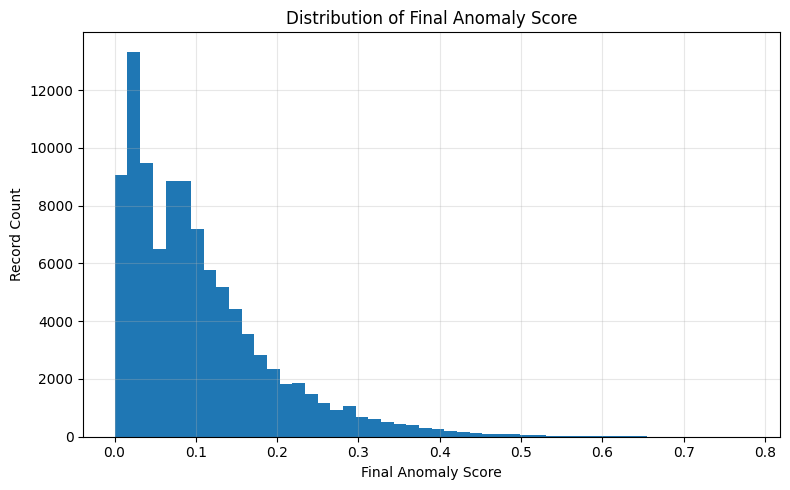

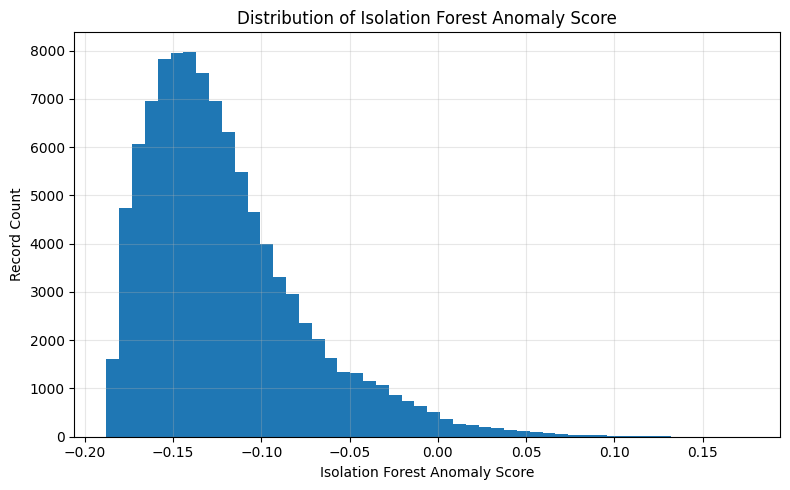

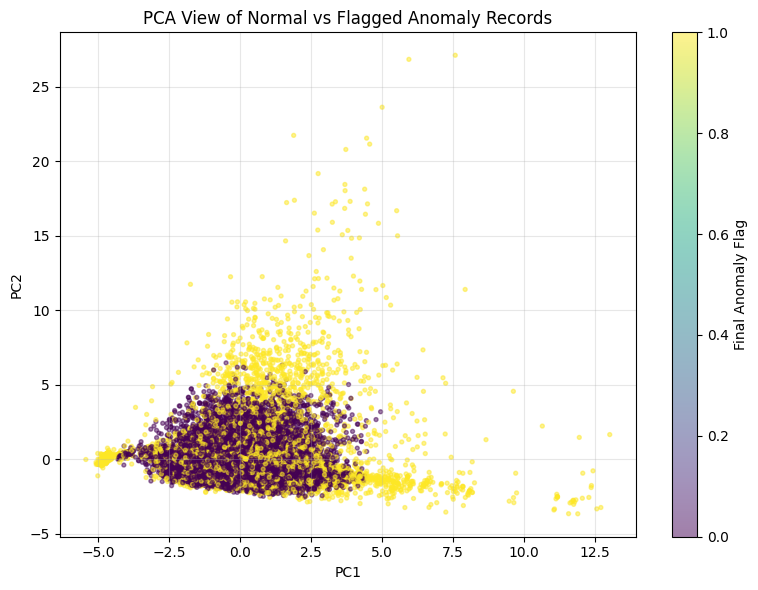

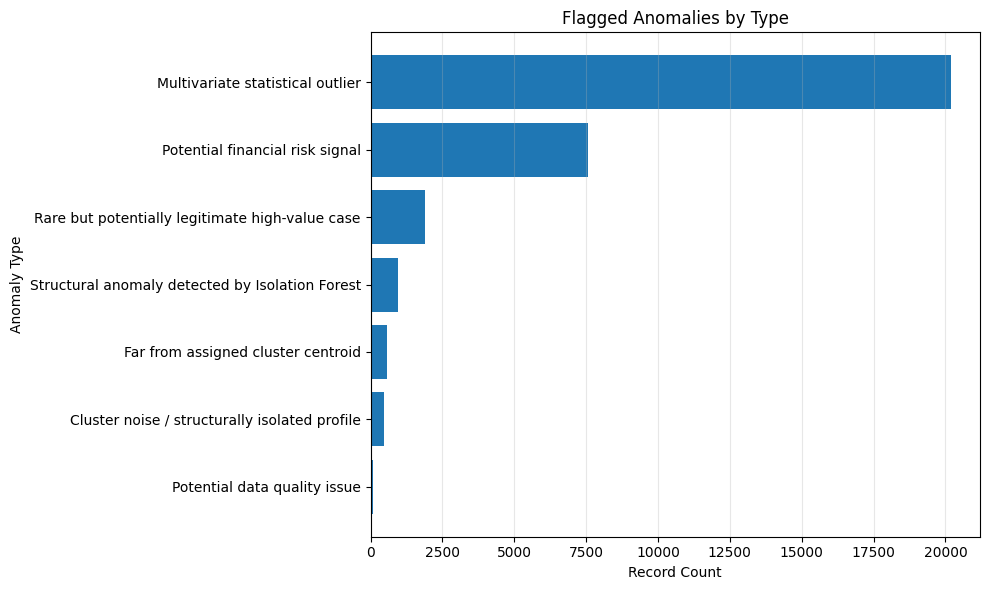


PHASE 4 COMPLETED
{
  "input_file": "D:\\Projects\\DM\\HMDA Mortgage\\data\\processed\\hmda_2022_clustered_phase2.csv",
  "rows": 99994,
  "features_used": [
    "income",
    "debt_to_income_ratio_midpoint",
    "loan_amount",
    "property_value",
    "combined_loan_to_value_ratio",
    "loan_term",
    "interest_rate",
    "rate_spread",
    "total_loan_costs",
    "total_points_and_fees",
    "origination_charges",
    "discount_points",
    "lender_credits",
    "tract_population",
    "tract_minority_population_percent",
    "ffiec_msa_md_median_family_income",
    "tract_to_msa_income_percentage",
    "tract_owner_occupied_units",
    "tract_one_to_four_family_homes",
    "tract_median_age_of_housing_units"
  ],
  "iqr_multiplier": 1.5,
  "zscore_threshold": 3.0,
  "isolation_forest": {
    "contamination": 0.02,
    "anomaly_count": 2000,
    "anomaly_percent": 2.0001
  },
  "final_anomalies": {
    "flagged_count": 31690,
    "flagged_percent": 31.6919,
    "score_threshold_t

In [7]:
# ============================================================
# PHASE 4: ANOMALY AND OUTLIER DETECTION
# Project: HMDA Mortgage 2022
# Owner: Data Engineer and Pattern Analyst
#
# Goals:
# 1. Apply statistical methods: IQR and Z-score
# 2. Use Isolation Forest for structural anomaly discovery
# 3. Cross-reference anomalies with cluster outliers from Phase 2
# 4. Investigate anomaly type:
#    - possible data quality issue
#    - rare but legitimate case
#    - potential financial/risk signal
# 5. Deliverable:
#    - anomaly-scored dataset
#    - flagged anomaly records
#    - anomaly explanation report
#    - business interpretation
# ============================================================

import os
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

warnings.filterwarnings("ignore")

# ============================================================
# 0. AUTO-DETECT PROJECT ROOT
# ============================================================

def find_project_root():
    current = Path.cwd().resolve()

    for candidate in [current] + list(current.parents):
        if (candidate / "data").exists() and (candidate / "notebooks").exists():
            return candidate

    return current

PROJECT_ROOT = find_project_root()
os.chdir(PROJECT_ROOT)

print(f"[INFO] Project root detected: {PROJECT_ROOT}")

# ============================================================
# 1. PATH CONFIGURATION
# ============================================================

PHASE2_FILE = PROJECT_ROOT / "data" / "processed" / "hmda_2022_clustered_phase2.csv"
PHASE1_FILE = PROJECT_ROOT / "data" / "processed" / "hmda_2022_clean_phase1.csv"

DATA_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
REPORT_DIR = PROJECT_ROOT / "reports" / "anomaly_detection"
PLOT_DIR = REPORT_DIR / "plots"

DATA_PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

ANOMALY_SCORED_FILE = DATA_PROCESSED_DIR / "hmda_2022_anomaly_scored_phase4.csv"
FLAGGED_ANOMALIES_FILE = REPORT_DIR / "phase4_flagged_anomaly_records.csv"
TOP_ANOMALIES_FILE = REPORT_DIR / "phase4_top_anomalies_for_review.csv"
STATISTICAL_OUTLIER_REPORT_FILE = REPORT_DIR / "phase4_statistical_outlier_report.csv"
ISOLATION_FOREST_REPORT_FILE = REPORT_DIR / "phase4_isolation_forest_report.csv"
ANOMALY_TYPE_SUMMARY_FILE = REPORT_DIR / "phase4_anomaly_type_summary.csv"
CLUSTER_CROSS_REFERENCE_FILE = REPORT_DIR / "phase4_cluster_cross_reference.csv"
ANOMALY_REPORT_FILE = REPORT_DIR / "phase4_anomaly_detection_report.md"

ANOMALY_SCORE_DISTRIBUTION_PLOT = PLOT_DIR / "phase4_anomaly_score_distribution.png"
IFOREST_SCORE_DISTRIBUTION_PLOT = PLOT_DIR / "phase4_isolation_forest_score_distribution.png"
PCA_ANOMALY_PLOT = PLOT_DIR / "phase4_pca_anomaly_visualization.png"
ANOMALY_TYPE_PLOT = PLOT_DIR / "phase4_anomaly_type_counts.png"

if PHASE2_FILE.exists():
    INPUT_FILE = PHASE2_FILE
    print(f"[INFO] Using Phase 2 clustered dataset: {INPUT_FILE}")
elif PHASE1_FILE.exists():
    INPUT_FILE = PHASE1_FILE
    print(f"[WARNING] Phase 2 file not found. Using Phase 1 clean dataset: {INPUT_FILE}")
else:
    raise FileNotFoundError(
        "Tidak ditemukan file Phase 2 maupun Phase 1.\n"
        f"Expected Phase 2: {PHASE2_FILE}\n"
        f"Expected Phase 1: {PHASE1_FILE}"
    )

# ============================================================
# 2. LOAD DATASET
# ============================================================

df = pd.read_csv(INPUT_FILE, low_memory=False)

print("=" * 80)
print("PHASE 4 - ANOMALY AND OUTLIER DETECTION")
print("=" * 80)
print(f"Input file : {INPUT_FILE}")
print(f"Rows       : {df.shape[0]:,}")
print(f"Columns    : {df.shape[1]:,}")

# ============================================================
# 3. SELECT FEATURES FOR ANOMALY DETECTION
# ============================================================

# Fokus anomaly detection:
# - financial profile
# - risk / pricing
# - loan/property characteristics
# - tract context
#
# Sensitive demographic attributes tidak digunakan sebagai input anomaly model.
# Namun tetap boleh dianalisis setelah flag anomaly terbentuk untuk EDA/fairness insight.

preferred_anomaly_features = [
    # Borrower financial profile
    "income",
    "debt_to_income_ratio_midpoint",

    # Loan and property profile
    "loan_amount",
    "property_value",
    "combined_loan_to_value_ratio",
    "loan_term",

    # Pricing / cost
    "interest_rate",
    "rate_spread",
    "total_loan_costs",
    "total_points_and_fees",
    "origination_charges",
    "discount_points",
    "lender_credits",

    # Tract / area context
    "tract_population",
    "tract_minority_population_percent",
    "ffiec_msa_md_median_family_income",
    "tract_to_msa_income_percentage",
    "tract_owner_occupied_units",
    "tract_one_to_four_family_homes",
    "tract_median_age_of_housing_units"
]

available_features = [
    col for col in preferred_anomaly_features
    if col in df.columns
]

if len(available_features) < 3:
    raise ValueError(
        "Fitur numerik untuk anomaly detection terlalu sedikit. "
        "Pastikan Phase 1 berhasil membersihkan numeric columns."
    )

print("\n[INFO] Anomaly detection features used:")
for col in available_features:
    print(f"- {col}")

X_raw = df[available_features].copy()

for col in X_raw.columns:
    X_raw[col] = pd.to_numeric(X_raw[col], errors="coerce")

X_raw = X_raw.replace([np.inf, -np.inf], np.nan)

# Median imputation
for col in X_raw.columns:
    median_value = X_raw[col].median()

    if pd.isna(median_value):
        median_value = 0

    X_raw[col] = X_raw[col].fillna(median_value)

# Scaling for z-score / Isolation Forest / PCA
scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(X_raw)

X_scaled = pd.DataFrame(
    X_scaled_array,
    columns=[f"{col}_scaled" for col in available_features],
    index=df.index
)

print(f"\n[INFO] Feature matrix shape: {X_scaled.shape[0]:,} rows x {X_scaled.shape[1]:,} columns")

# ============================================================
# 4. STATISTICAL OUTLIER DETECTION: IQR AND Z-SCORE
# ============================================================

IQR_MULTIPLIER = 1.5
ZSCORE_THRESHOLD = 3.0

statistical_records = []

df_anomaly = df.copy()

iqr_flag_cols = []
zscore_flag_cols = []

for col in available_features:
    s = X_raw[col].copy()

    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - IQR_MULTIPLIER * iqr
    upper_bound = q3 + IQR_MULTIPLIER * iqr

    iqr_flag_col = f"{col}_iqr_outlier"
    zscore_flag_col = f"{col}_zscore_outlier"
    zscore_value_col = f"{col}_zscore_value"

    if iqr == 0 or pd.isna(iqr):
        df_anomaly[iqr_flag_col] = 0
    else:
        df_anomaly[iqr_flag_col] = (
            (s < lower_bound) | (s > upper_bound)
        ).astype(int)

    z_values = X_scaled[f"{col}_scaled"]
    df_anomaly[zscore_value_col] = z_values
    df_anomaly[zscore_flag_col] = (z_values.abs() > ZSCORE_THRESHOLD).astype(int)

    iqr_count = int(df_anomaly[iqr_flag_col].sum())
    zscore_count = int(df_anomaly[zscore_flag_col].sum())

    statistical_records.append({
        "feature": col,
        "min": float(s.min()),
        "q1": float(q1),
        "median": float(s.median()),
        "q3": float(q3),
        "max": float(s.max()),
        "iqr": float(iqr),
        "iqr_lower_bound": float(lower_bound),
        "iqr_upper_bound": float(upper_bound),
        "iqr_outlier_count": iqr_count,
        "iqr_outlier_percent": round(iqr_count / len(df_anomaly) * 100, 4),
        "zscore_threshold": ZSCORE_THRESHOLD,
        "zscore_outlier_count": zscore_count,
        "zscore_outlier_percent": round(zscore_count / len(df_anomaly) * 100, 4)
    })

    iqr_flag_cols.append(iqr_flag_col)
    zscore_flag_cols.append(zscore_flag_col)

statistical_outlier_report_df = pd.DataFrame(statistical_records).sort_values(
    "iqr_outlier_percent",
    ascending=False
)

statistical_outlier_report_df.to_csv(STATISTICAL_OUTLIER_REPORT_FILE, index=False)

df_anomaly["iqr_outlier_feature_count"] = df_anomaly[iqr_flag_cols].sum(axis=1)
df_anomaly["zscore_outlier_feature_count"] = df_anomaly[zscore_flag_cols].sum(axis=1)

df_anomaly["statistical_outlier_flag"] = (
    (df_anomaly["iqr_outlier_feature_count"] > 0)
    | (df_anomaly["zscore_outlier_feature_count"] > 0)
).astype(int)

print("\n[REPORT] Statistical outlier summary:")
display(statistical_outlier_report_df.head(15))

# ============================================================
# 5. ISOLATION FOREST
# ============================================================

# Contamination adalah perkiraan proporsi anomaly.
# Untuk HMDA 100k, 2% cukup konservatif untuk top structural anomalies.
IFOREST_CONTAMINATION = 0.02
IFOREST_RANDOM_STATE = 42

isolation_forest = IsolationForest(
    n_estimators=300,
    contamination=IFOREST_CONTAMINATION,
    random_state=IFOREST_RANDOM_STATE,
    n_jobs=-1
)

iforest_pred = isolation_forest.fit_predict(X_scaled)

# sklearn IsolationForest:
# prediction -1 = anomaly, 1 = normal
# decision_function semakin kecil = semakin anomalous
iforest_decision_score = isolation_forest.decision_function(X_scaled)
iforest_anomaly_score = -iforest_decision_score

df_anomaly["isolation_forest_prediction"] = iforest_pred
df_anomaly["isolation_forest_flag"] = (iforest_pred == -1).astype(int)
df_anomaly["isolation_forest_score"] = iforest_anomaly_score

iforest_threshold = df_anomaly.loc[
    df_anomaly["isolation_forest_flag"] == 1,
    "isolation_forest_score"
].min()

iforest_count = int(df_anomaly["isolation_forest_flag"].sum())
iforest_percent = round(iforest_count / len(df_anomaly) * 100, 4)

isolation_forest_report_df = pd.DataFrame([{
    "model": "Isolation Forest",
    "n_estimators": 300,
    "contamination": IFOREST_CONTAMINATION,
    "random_state": IFOREST_RANDOM_STATE,
    "anomaly_count": iforest_count,
    "anomaly_percent": iforest_percent,
    "score_threshold_min_among_flagged": float(iforest_threshold)
}])

isolation_forest_report_df.to_csv(ISOLATION_FOREST_REPORT_FILE, index=False)

print("\n[REPORT] Isolation Forest summary:")
display(isolation_forest_report_df)

# ============================================================
# 6. CROSS-REFERENCE WITH PHASE 2 CLUSTER OUTLIERS
# ============================================================

# Phase 2 output may include:
# - cluster_dbscan: -1 means DBSCAN noise
# - cluster_kmeans: segmentation label
# - pca_1, pca_2
#
# Selain DBSCAN noise, kita juga hitung ulang K-Means distance-to-centroid
# sebagai cluster-distance anomaly.

if "cluster_dbscan" in df_anomaly.columns:
    df_anomaly["dbscan_noise_flag"] = (
        pd.to_numeric(df_anomaly["cluster_dbscan"], errors="coerce") == -1
    ).astype(int)
else:
    df_anomaly["dbscan_noise_flag"] = 0

if "cluster_kmeans" in df_anomaly.columns:
    cluster_labels = pd.to_numeric(df_anomaly["cluster_kmeans"], errors="coerce")

    df_anomaly["kmeans_cluster_distance"] = np.nan
    df_anomaly["kmeans_distance_outlier_flag"] = 0

    # Distance dari record ke centroid cluster masing-masing
    for cluster_id in sorted(cluster_labels.dropna().unique()):
        cluster_idx = cluster_labels[cluster_labels == cluster_id].index

        if len(cluster_idx) == 0:
            continue

        cluster_X = X_scaled.loc[cluster_idx]
        centroid = cluster_X.mean(axis=0).values

        distances = np.linalg.norm(cluster_X.values - centroid, axis=1)

        df_anomaly.loc[cluster_idx, "kmeans_cluster_distance"] = distances

        # Top 5% distance within each cluster dianggap cluster-distance outlier
        threshold = np.percentile(distances, 95)

        df_anomaly.loc[
            cluster_idx,
            "kmeans_distance_outlier_flag"
        ] = (distances > threshold).astype(int)

else:
    df_anomaly["kmeans_cluster_distance"] = np.nan
    df_anomaly["kmeans_distance_outlier_flag"] = 0

cluster_cross_reference_records = []

if "cluster_kmeans" in df_anomaly.columns:
    for cluster_id, cluster_df in df_anomaly.groupby("cluster_kmeans"):
        record = {
            "cluster_kmeans": cluster_id,
            "record_count": len(cluster_df),
            "statistical_outlier_count": int(cluster_df["statistical_outlier_flag"].sum()),
            "isolation_forest_count": int(cluster_df["isolation_forest_flag"].sum()),
            "dbscan_noise_count": int(cluster_df["dbscan_noise_flag"].sum()),
            "kmeans_distance_outlier_count": int(cluster_df["kmeans_distance_outlier_flag"].sum()),
            "avg_anomaly_score_placeholder": np.nan
        }

        cluster_cross_reference_records.append(record)

cluster_cross_reference_df = pd.DataFrame(cluster_cross_reference_records)

if not cluster_cross_reference_df.empty:
    cluster_cross_reference_df["statistical_outlier_percent"] = (
        cluster_cross_reference_df["statistical_outlier_count"]
        / cluster_cross_reference_df["record_count"] * 100
    ).round(4)

    cluster_cross_reference_df["isolation_forest_percent"] = (
        cluster_cross_reference_df["isolation_forest_count"]
        / cluster_cross_reference_df["record_count"] * 100
    ).round(4)

    cluster_cross_reference_df["dbscan_noise_percent"] = (
        cluster_cross_reference_df["dbscan_noise_count"]
        / cluster_cross_reference_df["record_count"] * 100
    ).round(4)

    cluster_cross_reference_df["kmeans_distance_outlier_percent"] = (
        cluster_cross_reference_df["kmeans_distance_outlier_count"]
        / cluster_cross_reference_df["record_count"] * 100
    ).round(4)

cluster_cross_reference_df.to_csv(CLUSTER_CROSS_REFERENCE_FILE, index=False)

print("\n[REPORT] Cluster cross-reference summary:")
display(cluster_cross_reference_df)

# ============================================================
# 7. DOMAIN-SPECIFIC RULE-BASED ANOMALY CHECKS
# ============================================================

# Rules below are not "errors" automatically.
# They flag records requiring investigation.

def safe_numeric(row, col):
    if col not in row.index:
        return np.nan

    return pd.to_numeric(row[col], errors="coerce")


def build_domain_anomaly_flags(row):
    flags = []

    income = safe_numeric(row, "income")
    loan_amount = safe_numeric(row, "loan_amount")
    property_value = safe_numeric(row, "property_value")
    cltv = safe_numeric(row, "combined_loan_to_value_ratio")
    dti = safe_numeric(row, "debt_to_income_ratio_midpoint")
    interest_rate = safe_numeric(row, "interest_rate")
    rate_spread = safe_numeric(row, "rate_spread")
    loan_term = safe_numeric(row, "loan_term")
    total_loan_costs = safe_numeric(row, "total_loan_costs")

    # Potential data quality checks
    if pd.notna(loan_amount) and loan_amount <= 0:
        flags.append("loan_amount_non_positive")

    if pd.notna(property_value) and property_value <= 0:
        flags.append("property_value_non_positive")

    if pd.notna(income) and income < 0:
        flags.append("income_negative")

    if pd.notna(interest_rate) and interest_rate < 0:
        flags.append("interest_rate_negative")

    if pd.notna(loan_term) and loan_term <= 0:
        flags.append("loan_term_non_positive")

    # HMDA plausible extreme checks
    if pd.notna(cltv) and cltv > 120:
        flags.append("very_high_cltv_above_120")

    if pd.notna(dti) and dti >= 60:
        flags.append("very_high_dti_60_plus")

    if pd.notna(interest_rate) and interest_rate >= 10:
        flags.append("very_high_interest_rate_10_plus")

    if pd.notna(rate_spread) and rate_spread >= 5:
        flags.append("very_high_rate_spread_5_plus")

    # Potential rare legitimate cases
    if pd.notna(loan_amount) and loan_amount >= df_anomaly["loan_amount"].quantile(0.99):
        flags.append("top_1_percent_loan_amount")

    if pd.notna(property_value) and property_value >= df_anomaly["property_value"].quantile(0.99):
        flags.append("top_1_percent_property_value")

    if pd.notna(income) and income >= df_anomaly["income"].quantile(0.99):
        flags.append("top_1_percent_income")

    # Potential mismatch patterns
    if pd.notna(income) and pd.notna(loan_amount):
        if income <= df_anomaly["income"].quantile(0.10) and loan_amount >= df_anomaly["loan_amount"].quantile(0.90):
            flags.append("low_income_high_loan_amount_combination")

    if pd.notna(property_value) and pd.notna(loan_amount):
        if property_value <= df_anomaly["property_value"].quantile(0.10) and loan_amount >= df_anomaly["loan_amount"].quantile(0.90):
            flags.append("low_property_value_high_loan_amount_combination")

    if pd.notna(total_loan_costs) and pd.notna(loan_amount):
        if loan_amount > 0 and total_loan_costs / loan_amount > 0.20:
            flags.append("loan_costs_above_20_percent_of_loan")

    return flags


domain_flags = df_anomaly.apply(build_domain_anomaly_flags, axis=1)

df_anomaly["domain_anomaly_flags"] = domain_flags.apply(lambda flags: "; ".join(flags) if len(flags) > 0 else "")
df_anomaly["domain_anomaly_flag_count"] = domain_flags.apply(len)
df_anomaly["domain_anomaly_flag"] = (df_anomaly["domain_anomaly_flag_count"] > 0).astype(int)

# ============================================================
# 8. FINAL ANOMALY SCORE
# ============================================================

# Normalize Isolation Forest score to 0-1
score_min = df_anomaly["isolation_forest_score"].min()
score_max = df_anomaly["isolation_forest_score"].max()

if score_max == score_min:
    df_anomaly["isolation_forest_score_norm"] = 0
else:
    df_anomaly["isolation_forest_score_norm"] = (
        (df_anomaly["isolation_forest_score"] - score_min)
        / (score_max - score_min)
    )

# Normalize KMeans distance to 0-1
kdist_min = df_anomaly["kmeans_cluster_distance"].min()
kdist_max = df_anomaly["kmeans_cluster_distance"].max()

if pd.isna(kdist_min) or pd.isna(kdist_max) or kdist_max == kdist_min:
    df_anomaly["kmeans_cluster_distance_norm"] = 0
else:
    df_anomaly["kmeans_cluster_distance_norm"] = (
        (df_anomaly["kmeans_cluster_distance"] - kdist_min)
        / (kdist_max - kdist_min)
    )

# Cap count effects agar fitur banyak tidak terlalu mendominasi
df_anomaly["iqr_count_score"] = np.minimum(df_anomaly["iqr_outlier_feature_count"], 5) / 5
df_anomaly["zscore_count_score"] = np.minimum(df_anomaly["zscore_outlier_feature_count"], 5) / 5
df_anomaly["domain_count_score"] = np.minimum(df_anomaly["domain_anomaly_flag_count"], 5) / 5

# Weighted final score
df_anomaly["final_anomaly_score"] = (
    0.30 * df_anomaly["isolation_forest_score_norm"]
    + 0.20 * df_anomaly["iqr_count_score"]
    + 0.15 * df_anomaly["zscore_count_score"]
    + 0.15 * df_anomaly["kmeans_cluster_distance_norm"]
    + 0.10 * df_anomaly["dbscan_noise_flag"]
    + 0.10 * df_anomaly["domain_count_score"]
)

# Flag final anomaly:
# record dianggap anomaly jika:
# - Isolation Forest flag, atau
# - statistical outlier di minimal 2 fitur, atau
# - domain anomaly, atau
# - DBSCAN noise, atau
# - top 5% final anomaly score
score_threshold_top5 = df_anomaly["final_anomaly_score"].quantile(0.95)

df_anomaly["final_anomaly_flag"] = (
    (df_anomaly["isolation_forest_flag"] == 1)
    | (df_anomaly["iqr_outlier_feature_count"] >= 2)
    | (df_anomaly["zscore_outlier_feature_count"] >= 2)
    | (df_anomaly["domain_anomaly_flag"] == 1)
    | (df_anomaly["dbscan_noise_flag"] == 1)
    | (df_anomaly["kmeans_distance_outlier_flag"] == 1)
    | (df_anomaly["final_anomaly_score"] >= score_threshold_top5)
).astype(int)

# ============================================================
# 9. ANOMALY TYPOLOGY AND EXPLANATION
# ============================================================

def identify_top_outlier_features(row, max_features=5):
    reasons = []

    for col in available_features:
        iqr_flag_col = f"{col}_iqr_outlier"
        zscore_flag_col = f"{col}_zscore_outlier"
        zscore_value_col = f"{col}_zscore_value"

        iqr_flag = row.get(iqr_flag_col, 0)
        z_flag = row.get(zscore_flag_col, 0)
        z_val = row.get(zscore_value_col, 0)

        if iqr_flag == 1 or z_flag == 1:
            direction = "high" if z_val > 0 else "low"
            reasons.append((col, abs(z_val), direction))

    reasons = sorted(reasons, key=lambda x: x[1], reverse=True)

    formatted = [
        f"{feature}={direction}_outlier(z={z:.2f})"
        for feature, z, direction in reasons[:max_features]
    ]

    return "; ".join(formatted)


def classify_anomaly_type(row):
    domain_flags_text = str(row.get("domain_anomaly_flags", ""))

    data_quality_keywords = [
        "non_positive",
        "negative",
        "loan_term_non_positive",
        "interest_rate_negative"
    ]

    risk_keywords = [
        "very_high_cltv",
        "very_high_dti",
        "very_high_interest",
        "very_high_rate_spread",
        "low_income_high_loan_amount",
        "loan_costs_above_20_percent"
    ]

    rare_legitimate_keywords = [
        "top_1_percent_loan_amount",
        "top_1_percent_property_value",
        "top_1_percent_income"
    ]

    if any(keyword in domain_flags_text for keyword in data_quality_keywords):
        return "Potential data quality issue"

    if row.get("dbscan_noise_flag", 0) == 1:
        return "Cluster noise / structurally isolated profile"

    if any(keyword in domain_flags_text for keyword in risk_keywords):
        return "Potential financial risk signal"

    if any(keyword in domain_flags_text for keyword in rare_legitimate_keywords):
        return "Rare but potentially legitimate high-value case"

    if row.get("isolation_forest_flag", 0) == 1:
        return "Structural anomaly detected by Isolation Forest"

    if row.get("iqr_outlier_feature_count", 0) >= 2 or row.get("zscore_outlier_feature_count", 0) >= 2:
        return "Multivariate statistical outlier"

    if row.get("kmeans_distance_outlier_flag", 0) == 1:
        return "Far from assigned cluster centroid"

    return "Minor anomaly / requires manual review"


def build_anomaly_explanation(row):
    explanation_parts = []

    if row.get("isolation_forest_flag", 0) == 1:
        explanation_parts.append("flagged by Isolation Forest")

    if row.get("iqr_outlier_feature_count", 0) > 0:
        explanation_parts.append(f"IQR outlier in {int(row.get('iqr_outlier_feature_count', 0))} feature(s)")

    if row.get("zscore_outlier_feature_count", 0) > 0:
        explanation_parts.append(f"Z-score outlier in {int(row.get('zscore_outlier_feature_count', 0))} feature(s)")

    if row.get("dbscan_noise_flag", 0) == 1:
        explanation_parts.append("identified as DBSCAN noise in Phase 2")

    if row.get("kmeans_distance_outlier_flag", 0) == 1:
        explanation_parts.append("far from its K-Means cluster centroid")

    if row.get("domain_anomaly_flag", 0) == 1:
        explanation_parts.append(f"domain flags: {row.get('domain_anomaly_flags', '')}")

    top_features = row.get("top_outlier_features", "")

    if top_features:
        explanation_parts.append(f"top outlier features: {top_features}")

    if len(explanation_parts) == 0:
        return "No strong anomaly explanation; manual review required."

    return "; ".join(explanation_parts)


def build_business_interpretation(row):
    anomaly_type = row.get("anomaly_type", "Unknown")
    score = row.get("final_anomaly_score", np.nan)

    action_taken = row.get("action_taken_label", row.get("action_taken", "Unknown"))
    cluster = row.get("cluster_kmeans", "Unknown")

    base = (
        f"This record has anomaly score {score:.4f} and is categorized as '{anomaly_type}'. "
        f"Application outcome: {action_taken}. K-Means cluster: {cluster}. "
    )

    if anomaly_type == "Potential data quality issue":
        return base + "Recommended action: verify source fields before using this record for modeling or business conclusions."

    if anomaly_type == "Potential financial risk signal":
        return base + "Recommended action: investigate whether the pattern reflects elevated credit/pricing risk or a special underwriting condition."

    if anomaly_type == "Rare but potentially legitimate high-value case":
        return base + "Recommended action: treat as a rare high-value case rather than automatically removing it."

    if anomaly_type == "Cluster noise / structurally isolated profile":
        return base + "Recommended action: compare with Phase 2 cluster profiles because this profile does not fit dense segments."

    if anomaly_type == "Structural anomaly detected by Isolation Forest":
        return base + "Recommended action: inspect the combination of financial and loan attributes because the structure is unusual across multiple dimensions."

    if anomaly_type == "Multivariate statistical outlier":
        return base + "Recommended action: examine which numeric variables drive the statistical deviation."

    if anomaly_type == "Far from assigned cluster centroid":
        return base + "Recommended action: inspect whether this is a boundary case or a separate small segment."

    return base + "Recommended action: review manually if it appears in top-ranked anomalies."

df_anomaly["top_outlier_features"] = df_anomaly.apply(identify_top_outlier_features, axis=1)
df_anomaly["anomaly_type"] = df_anomaly.apply(classify_anomaly_type, axis=1)
df_anomaly["anomaly_explanation"] = df_anomaly.apply(build_anomaly_explanation, axis=1)
df_anomaly["business_interpretation"] = df_anomaly.apply(build_business_interpretation, axis=1)

# Update cluster cross-reference with final anomaly score if available
if not cluster_cross_reference_df.empty and "cluster_kmeans" in df_anomaly.columns:
    avg_score_by_cluster = df_anomaly.groupby("cluster_kmeans")["final_anomaly_score"].mean()

    cluster_cross_reference_df["avg_anomaly_score"] = cluster_cross_reference_df["cluster_kmeans"].map(avg_score_by_cluster).round(4)

    cluster_cross_reference_df = cluster_cross_reference_df.drop(
        columns=["avg_anomaly_score_placeholder"],
        errors="ignore"
    )

    cluster_cross_reference_df.to_csv(CLUSTER_CROSS_REFERENCE_FILE, index=False)

# ============================================================
# 10. FLAGGED ANOMALIES OUTPUT
# ============================================================

important_context_cols = [
    "action_taken",
    "action_taken_label",
    "loan_type",
    "loan_type_label",
    "loan_purpose",
    "loan_purpose_label",
    "derived_loan_product_type",
    "derived_dwelling_category",
    "state_code",
    "county_code",
    "census_tract",
    "cluster_kmeans",
    "cluster_dbscan"
]

important_context_cols = [col for col in important_context_cols if col in df_anomaly.columns]

score_cols = [
    "final_anomaly_score",
    "final_anomaly_flag",
    "anomaly_type",
    "anomaly_explanation",
    "business_interpretation",
    "isolation_forest_flag",
    "isolation_forest_score",
    "statistical_outlier_flag",
    "iqr_outlier_feature_count",
    "zscore_outlier_feature_count",
    "dbscan_noise_flag",
    "kmeans_distance_outlier_flag",
    "kmeans_cluster_distance",
    "domain_anomaly_flag",
    "domain_anomaly_flag_count",
    "domain_anomaly_flags",
    "top_outlier_features"
]

score_cols = [col for col in score_cols if col in df_anomaly.columns]

export_cols = (
    score_cols
    + important_context_cols
    + available_features
)

export_cols = list(dict.fromkeys([col for col in export_cols if col in df_anomaly.columns]))

flagged_anomalies_df = df_anomaly[df_anomaly["final_anomaly_flag"] == 1].copy()
flagged_anomalies_df = flagged_anomalies_df.sort_values(
    "final_anomaly_score",
    ascending=False
)

top_anomalies_df = flagged_anomalies_df.head(200).copy()

flagged_anomalies_df[export_cols].to_csv(FLAGGED_ANOMALIES_FILE, index=False)
top_anomalies_df[export_cols].to_csv(TOP_ANOMALIES_FILE, index=False)

df_anomaly.to_csv(ANOMALY_SCORED_FILE, index=False)

print("\n[REPORT] Flagged anomaly summary:")
print(f"Flagged anomalies : {len(flagged_anomalies_df):,}")
print(f"Flagged percent   : {len(flagged_anomalies_df) / len(df_anomaly) * 100:.2f}%")

print("\nTop anomalies for review:")
display(top_anomalies_df[export_cols].head(20))

# ============================================================
# 11. ANOMALY TYPE SUMMARY
# ============================================================

anomaly_type_summary_df = (
    flagged_anomalies_df["anomaly_type"]
    .value_counts()
    .reset_index()
)

anomaly_type_summary_df.columns = ["anomaly_type", "record_count"]
anomaly_type_summary_df["record_percent_of_flagged"] = (
    anomaly_type_summary_df["record_count"]
    / len(flagged_anomalies_df)
    * 100
).round(4)

anomaly_type_summary_df["record_percent_of_all_data"] = (
    anomaly_type_summary_df["record_count"]
    / len(df_anomaly)
    * 100
).round(4)

anomaly_type_summary_df.to_csv(ANOMALY_TYPE_SUMMARY_FILE, index=False)

print("\nAnomaly type summary:")
display(anomaly_type_summary_df)

# ============================================================
# 12. VISUALIZATION
# ============================================================

plt.figure(figsize=(8, 5))
plt.hist(df_anomaly["final_anomaly_score"], bins=50)
plt.title("Distribution of Final Anomaly Score")
plt.xlabel("Final Anomaly Score")
plt.ylabel("Record Count")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(ANOMALY_SCORE_DISTRIBUTION_PLOT, dpi=150)
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(df_anomaly["isolation_forest_score"], bins=50)
plt.title("Distribution of Isolation Forest Anomaly Score")
plt.xlabel("Isolation Forest Anomaly Score")
plt.ylabel("Record Count")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(IFOREST_SCORE_DISTRIBUTION_PLOT, dpi=150)
plt.show()

# PCA visualization
pca = PCA(n_components=2, random_state=42)
pca_components = pca.fit_transform(X_scaled)

df_anomaly["phase4_pca_1"] = pca_components[:, 0]
df_anomaly["phase4_pca_2"] = pca_components[:, 1]

plot_sample_size = min(30_000, len(df_anomaly))
plot_df = df_anomaly.sample(n=plot_sample_size, random_state=42)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    plot_df["phase4_pca_1"],
    plot_df["phase4_pca_2"],
    c=plot_df["final_anomaly_flag"],
    s=8,
    alpha=0.5
)
plt.title("PCA View of Normal vs Flagged Anomaly Records")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(scatter, label="Final Anomaly Flag")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(PCA_ANOMALY_PLOT, dpi=150)
plt.show()

if len(anomaly_type_summary_df) > 0:
    plot_type_df = anomaly_type_summary_df.sort_values("record_count", ascending=True)

    plt.figure(figsize=(10, 6))
    plt.barh(
        plot_type_df["anomaly_type"],
        plot_type_df["record_count"]
    )
    plt.title("Flagged Anomalies by Type")
    plt.xlabel("Record Count")
    plt.ylabel("Anomaly Type")
    plt.grid(True, axis="x", alpha=0.3)
    plt.tight_layout()
    plt.savefig(ANOMALY_TYPE_PLOT, dpi=150)
    plt.show()

# Save updated anomaly scored dataset again after PCA columns
df_anomaly.to_csv(ANOMALY_SCORED_FILE, index=False)

# ============================================================
# 13. WRITE PHASE 4 REPORT
# ============================================================

report_lines = []

report_lines.append("# Phase 4 Anomaly and Outlier Detection Report")
report_lines.append("")
report_lines.append("## Project")
report_lines.append("HMDA Mortgage 2022 - Anomaly and Outlier Detection")
report_lines.append("")
report_lines.append("## Phase Goal")
report_lines.append(
    "Identify records that deviate substantially from the rest of the data and determine whether each deviation "
    "represents a data quality issue, an unusual but valid case, or a signal worth escalating."
)
report_lines.append("")
report_lines.append("## Input Dataset")
report_lines.append(f"- Input file: `{INPUT_FILE}`")
report_lines.append(f"- Rows: {df.shape[0]:,}")
report_lines.append(f"- Columns: {df.shape[1]:,}")
report_lines.append("")
report_lines.append("## Features Used")
report_lines.append("The anomaly detection feature set focuses on financial, risk, pricing, loan, property, and tract-level attributes.")
report_lines.append("")
for col in available_features:
    report_lines.append(f"- `{col}`")
report_lines.append("")
report_lines.append("Sensitive demographic attributes were not used as input features for the anomaly model. They may still be analyzed after anomaly labels are created for EDA and fairness-oriented interpretation.")
report_lines.append("")
report_lines.append("## Methods")
report_lines.append("### 1. Statistical Outlier Detection")
report_lines.append(f"- IQR rule: value below Q1 - {IQR_MULTIPLIER} × IQR or above Q3 + {IQR_MULTIPLIER} × IQR.")
report_lines.append(f"- Z-score rule: absolute z-score greater than {ZSCORE_THRESHOLD}.")
report_lines.append(f"- Statistical outlier report: `{STATISTICAL_OUTLIER_REPORT_FILE}`")
report_lines.append("")
report_lines.append("### 2. Isolation Forest")
report_lines.append("- Isolation Forest was used as a structural anomaly detection method.")
report_lines.append(f"- Contamination parameter: {IFOREST_CONTAMINATION}")
report_lines.append(f"- Isolation Forest anomalies: {iforest_count:,} records ({iforest_percent:.2f}%).")
report_lines.append(f"- Isolation Forest report: `{ISOLATION_FOREST_REPORT_FILE}`")
report_lines.append("")
report_lines.append("### 3. Cluster Cross-Reference")
report_lines.append("- DBSCAN noise labels from Phase 2 were used as cluster-based anomaly evidence when available.")
report_lines.append("- K-Means distance-to-centroid was recomputed to identify records far from their assigned cluster center.")
report_lines.append(f"- Cluster cross-reference file: `{CLUSTER_CROSS_REFERENCE_FILE}`")
report_lines.append("")
report_lines.append("### 4. Domain-Specific Anomaly Rules")
report_lines.append("- Additional flags were created for suspicious values or unusual combinations such as very high CLTV, very high DTI, very high pricing, high loan amount, high property value, and low-income/high-loan combinations.")
report_lines.append("")
report_lines.append("## Overall Results")
report_lines.append(f"- Final flagged anomalies: {len(flagged_anomalies_df):,}")
report_lines.append(f"- Final flagged anomaly percentage: {len(flagged_anomalies_df) / len(df_anomaly) * 100:.2f}%")
report_lines.append(f"- Top anomaly score threshold used for final score evidence: {score_threshold_top5:.4f}")
report_lines.append("")
report_lines.append("## Anomaly Type Summary")

for _, row in anomaly_type_summary_df.iterrows():
    report_lines.append(
        f"- {row['anomaly_type']}: {int(row['record_count']):,} records "
        f"({row['record_percent_of_flagged']:.2f}% of flagged, "
        f"{row['record_percent_of_all_data']:.2f}% of all data)"
    )

report_lines.append("")
report_lines.append("## Top Records for Review")
report_lines.append("The top 200 anomaly records were exported for manual review. Below are the first 10 highest-scored anomalies.")

for idx, row in top_anomalies_df.head(10).iterrows():
    report_lines.append("")
    report_lines.append(f"### Review Record Index {idx}")
    report_lines.append(f"- Anomaly score: {row['final_anomaly_score']:.4f}")
    report_lines.append(f"- Type: {row['anomaly_type']}")
    report_lines.append(f"- Explanation: {row['anomaly_explanation']}")
    report_lines.append(f"- Business interpretation: {row['business_interpretation']}")

report_lines.append("")
report_lines.append("## Deliverables")
report_lines.append(f"- Anomaly scored dataset: `{ANOMALY_SCORED_FILE}`")
report_lines.append(f"- Flagged anomaly records: `{FLAGGED_ANOMALIES_FILE}`")
report_lines.append(f"- Top anomalies for review: `{TOP_ANOMALIES_FILE}`")
report_lines.append(f"- Statistical outlier report: `{STATISTICAL_OUTLIER_REPORT_FILE}`")
report_lines.append(f"- Isolation Forest report: `{ISOLATION_FOREST_REPORT_FILE}`")
report_lines.append(f"- Anomaly type summary: `{ANOMALY_TYPE_SUMMARY_FILE}`")
report_lines.append(f"- Cluster cross-reference: `{CLUSTER_CROSS_REFERENCE_FILE}`")
report_lines.append("")
report_lines.append("## Visualizations")
report_lines.append(f"- Final anomaly score distribution: `{ANOMALY_SCORE_DISTRIBUTION_PLOT}`")
report_lines.append(f"- Isolation Forest score distribution: `{IFOREST_SCORE_DISTRIBUTION_PLOT}`")
report_lines.append(f"- PCA anomaly visualization: `{PCA_ANOMALY_PLOT}`")
report_lines.append(f"- Anomaly type count plot: `{ANOMALY_TYPE_PLOT}`")
report_lines.append("")
report_lines.append("## Interpretation Notes")
report_lines.append("- A flagged anomaly is not automatically an error.")
report_lines.append("- Statistical outliers may represent rare but legitimate mortgage profiles.")
report_lines.append("- Domain rules are used to guide review, not to prove misconduct or data error.")
report_lines.append("- Isolation Forest detects unusual multivariate structure, not causal risk.")
report_lines.append("- DBSCAN noise and K-Means distance outliers should be compared with Phase 2 cluster profiles.")
report_lines.append("")
report_lines.append("## Recommended Next Step")
report_lines.append("- Use `phase4_top_anomalies_for_review.csv` for manual investigation.")
report_lines.append("- Compare anomaly types with cluster profiles and association rules from previous phases.")
report_lines.append("- Use the anomaly summary in the final dashboard/storytelling phase.")

ANOMALY_REPORT_FILE.write_text("\n".join(report_lines), encoding="utf-8")

# ============================================================
# 14. FINAL SUMMARY
# ============================================================

phase4_summary = {
    "input_file": str(INPUT_FILE),
    "rows": int(df.shape[0]),
    "features_used": available_features,
    "iqr_multiplier": float(IQR_MULTIPLIER),
    "zscore_threshold": float(ZSCORE_THRESHOLD),
    "isolation_forest": {
        "contamination": float(IFOREST_CONTAMINATION),
        "anomaly_count": int(iforest_count),
        "anomaly_percent": float(iforest_percent)
    },
    "final_anomalies": {
        "flagged_count": int(len(flagged_anomalies_df)),
        "flagged_percent": float(round(len(flagged_anomalies_df) / len(df_anomaly) * 100, 4)),
        "score_threshold_top5": float(score_threshold_top5)
    },
    "outputs": {
        "anomaly_scored_dataset": str(ANOMALY_SCORED_FILE),
        "flagged_anomaly_records": str(FLAGGED_ANOMALIES_FILE),
        "top_anomalies_for_review": str(TOP_ANOMALIES_FILE),
        "statistical_outlier_report": str(STATISTICAL_OUTLIER_REPORT_FILE),
        "isolation_forest_report": str(ISOLATION_FOREST_REPORT_FILE),
        "anomaly_type_summary": str(ANOMALY_TYPE_SUMMARY_FILE),
        "cluster_cross_reference": str(CLUSTER_CROSS_REFERENCE_FILE),
        "anomaly_report": str(ANOMALY_REPORT_FILE)
    },
    "plots": {
        "anomaly_score_distribution": str(ANOMALY_SCORE_DISTRIBUTION_PLOT),
        "isolation_forest_score_distribution": str(IFOREST_SCORE_DISTRIBUTION_PLOT),
        "pca_anomaly_visualization": str(PCA_ANOMALY_PLOT),
        "anomaly_type_plot": str(ANOMALY_TYPE_PLOT)
    }
}

print("\n" + "=" * 80)
print("PHASE 4 COMPLETED")
print("=" * 80)
print(json.dumps(phase4_summary, indent=2))

print("\nSaved files:")
print(f"- Anomaly scored dataset      : {ANOMALY_SCORED_FILE}")
print(f"- Flagged anomaly records     : {FLAGGED_ANOMALIES_FILE}")
print(f"- Top anomalies for review    : {TOP_ANOMALIES_FILE}")
print(f"- Statistical outlier report  : {STATISTICAL_OUTLIER_REPORT_FILE}")
print(f"- Isolation Forest report     : {ISOLATION_FOREST_REPORT_FILE}")
print(f"- Anomaly type summary        : {ANOMALY_TYPE_SUMMARY_FILE}")
print(f"- Cluster cross-reference     : {CLUSTER_CROSS_REFERENCE_FILE}")
print(f"- Phase 4 report              : {ANOMALY_REPORT_FILE}")

[INFO] Project root detected: D:\Projects\DM\HMDA Mortgage
[INFO] Using input: Phase 4 anomaly-scored dataset
[INFO] File: D:\Projects\DM\HMDA Mortgage\data\processed\hmda_2022_anomaly_scored_phase4.csv
PHASE 5 - VISUALIZATION AND KNOWLEDGE PRESENTATION
Rows    : 99,994
Columns : 290

KPI Summary:


,total_records,originated_count,originated_percent,denied_count,denied_percent,withdrawn_count,withdrawn_percent,incomplete_count,incomplete_percent,anomaly_count,anomaly_percent,cluster_count,avg_income,median_income,avg_loan_amount,median_loan_amount,avg_property_value,avg_interest_rate,avg_rate_spread
0,99994,52346,52.3491,15344,15.3449,13659,13.6598,5014,5.0143,31690,31.6919,4,161.890733,95.0,309465.267916,225000.0,504550.273016,4.772116,0.389691



Dashboard files created:
- D:\Projects\DM\HMDA Mortgage\dashboard\data\dashboard_main_sample.csv
- D:\Projects\DM\HMDA Mortgage\dashboard\data\dashboard_kpi_summary.csv
- D:\Projects\DM\HMDA Mortgage\dashboard\data\dashboard_action_taken_summary.csv
- D:\Projects\DM\HMDA Mortgage\dashboard\data\dashboard_cluster_summary.csv
- D:\Projects\DM\HMDA Mortgage\dashboard\data\dashboard_top_rules.csv
- D:\Projects\DM\HMDA Mortgage\dashboard\data\dashboard_anomaly_summary.csv


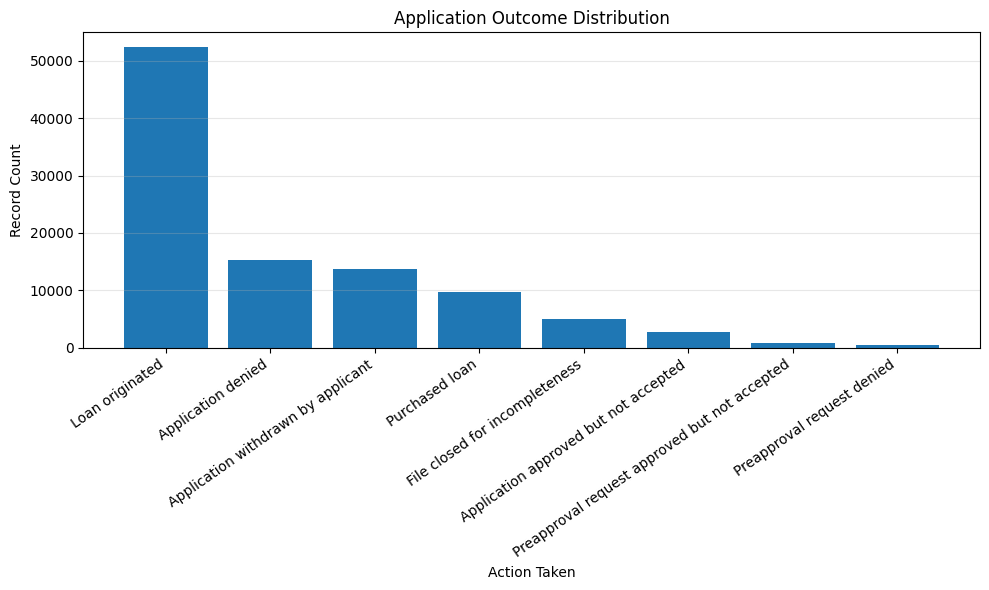

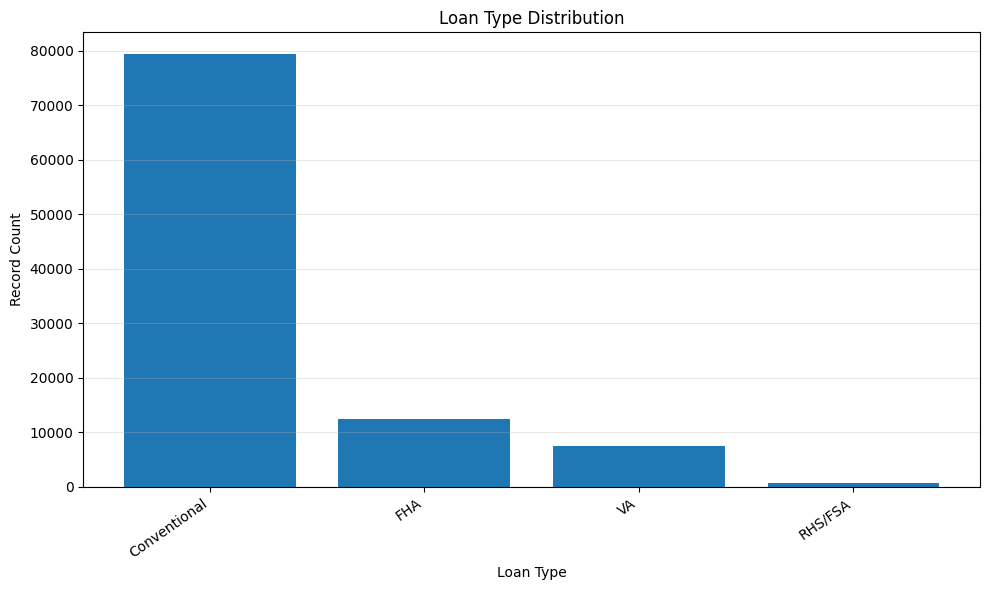

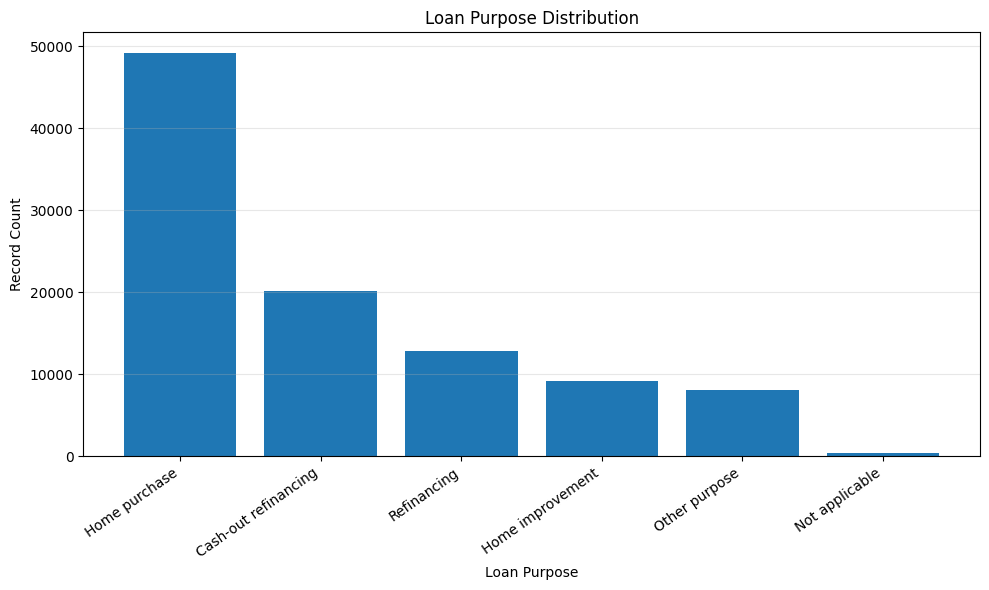

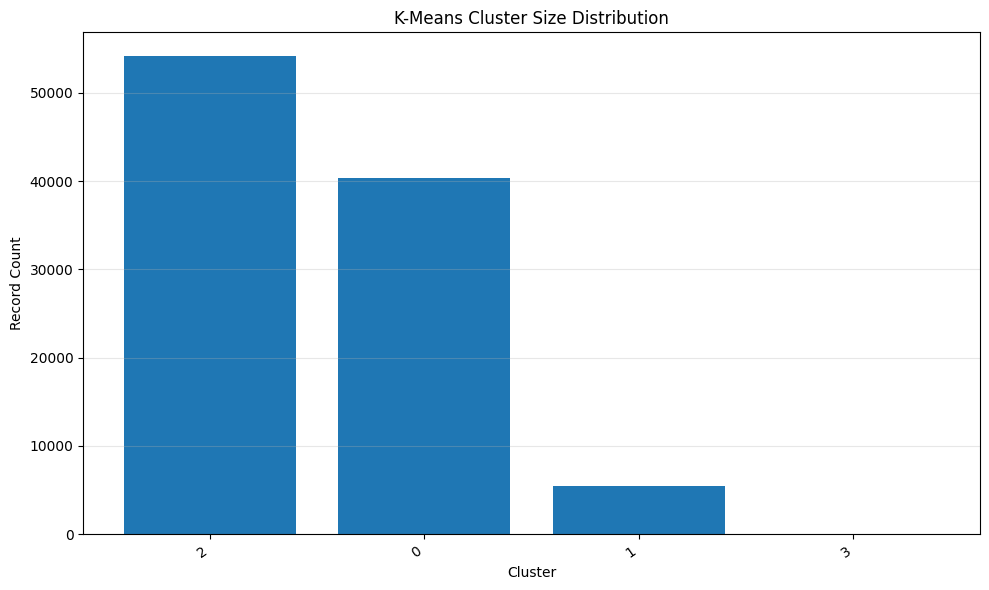

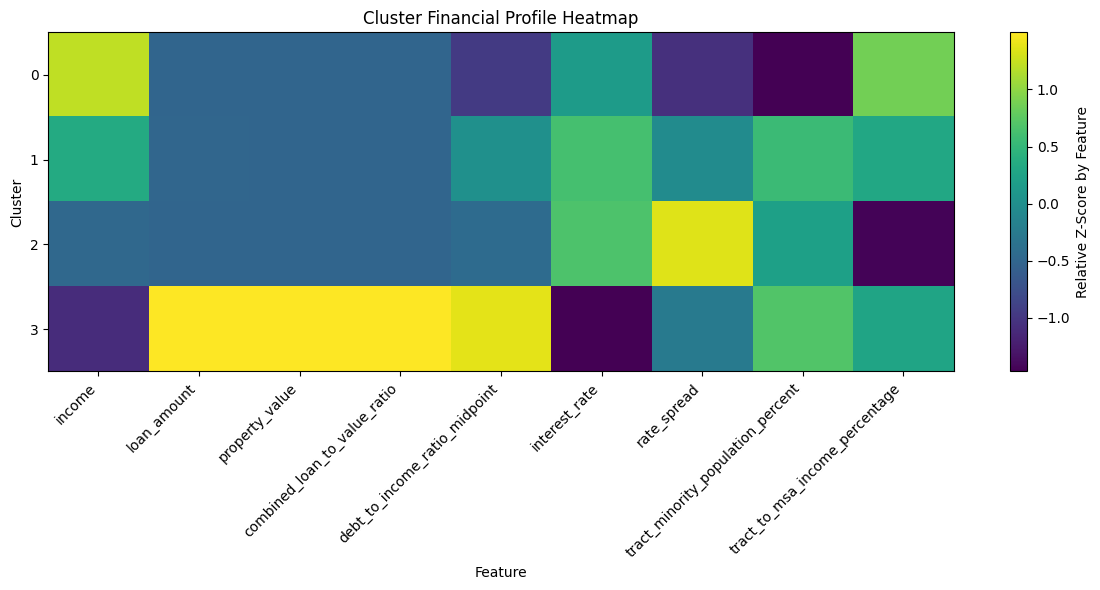

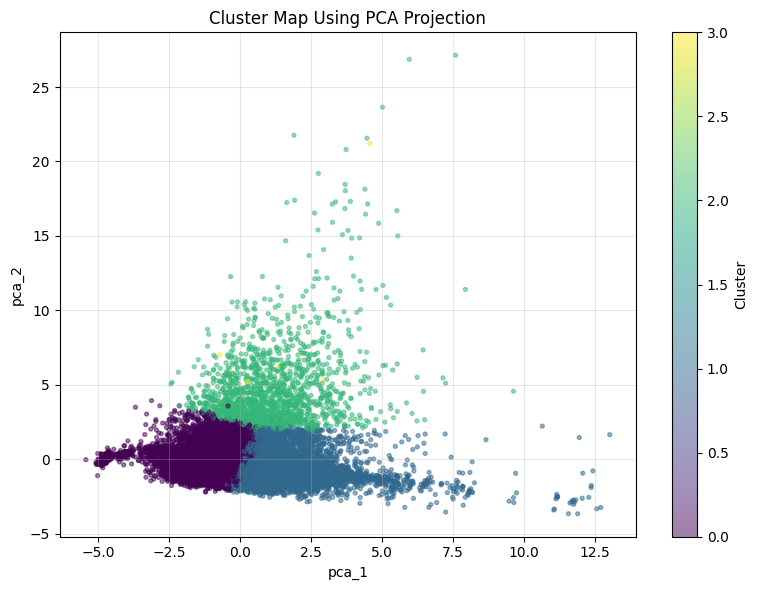

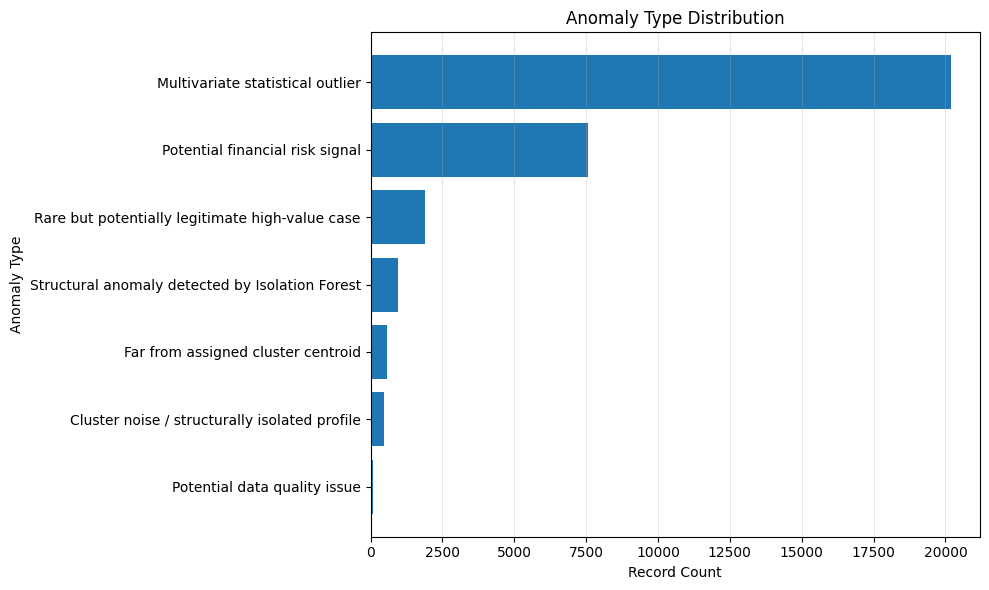

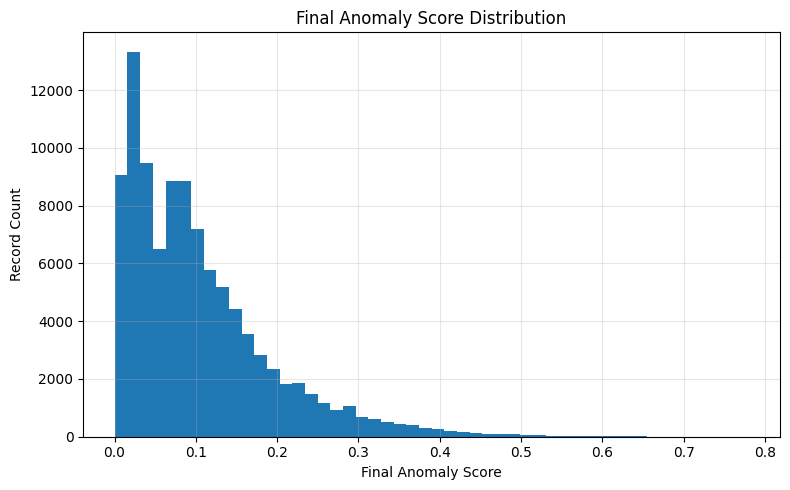

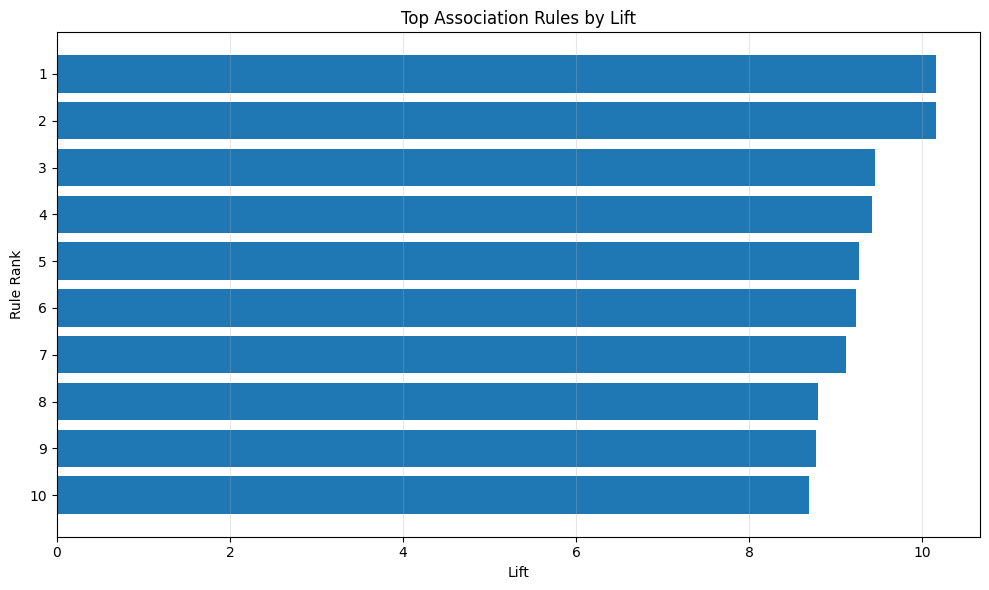

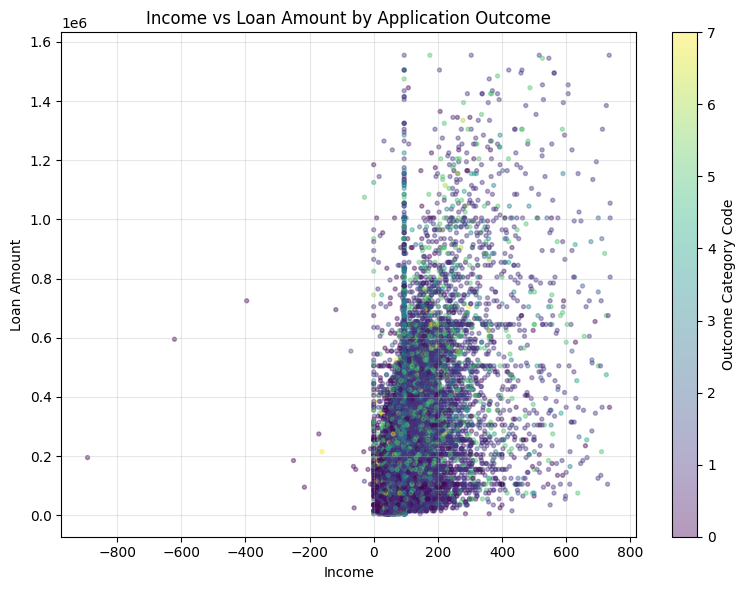

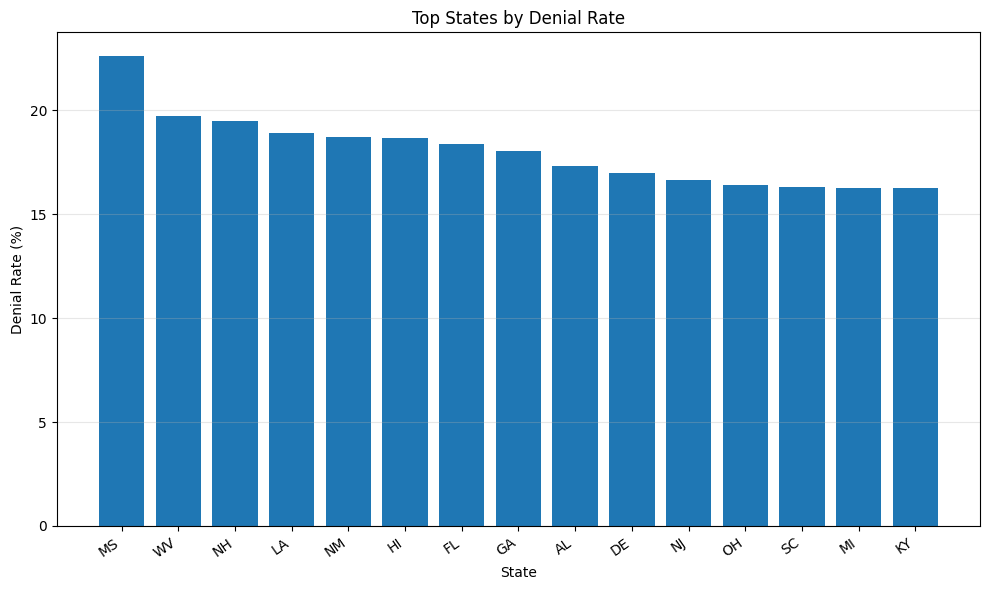


Extracted insights:


,title,finding,business_meaning
0,Dominant application outcome,The most common application outcome is `Loan o...,This gives the baseline context for interpreti...
1,Clusters show different outcome profiles,Cluster `2` has the highest denial rate (17.44...,This means segmentation reveals different fina...
2,Anomalies are not one single type,The most frequent flagged anomaly type is `Mul...,Anomaly detection should not be interpreted as...
3,Association rules reveal non-obvious co-occurr...,The strongest top rule by lift is `applicant_a...,Lift above 1 indicates the consequent appears ...
4,Geographic summaries show uneven outcome rates,Among states with at least 200 records in the ...,Geographic variation may reflect differences i...



PHASE 5 COMPLETED
{
  "input_file": "D:\\Projects\\DM\\HMDA Mortgage\\data\\processed\\hmda_2022_anomaly_scored_phase4.csv",
  "rows": 99994,
  "dashboard_files": {
    "main_sample": "D:\\Projects\\DM\\HMDA Mortgage\\dashboard\\data\\dashboard_main_sample.csv",
    "kpi_summary": "D:\\Projects\\DM\\HMDA Mortgage\\dashboard\\data\\dashboard_kpi_summary.csv",
    "action_summary": "D:\\Projects\\DM\\HMDA Mortgage\\dashboard\\data\\dashboard_action_taken_summary.csv",
    "loan_type_summary": "D:\\Projects\\DM\\HMDA Mortgage\\dashboard\\data\\dashboard_loan_type_summary.csv",
    "loan_purpose_summary": "D:\\Projects\\DM\\HMDA Mortgage\\dashboard\\data\\dashboard_loan_purpose_summary.csv",
    "cluster_summary": "D:\\Projects\\DM\\HMDA Mortgage\\dashboard\\data\\dashboard_cluster_summary.csv",
    "cluster_financial_profile": "D:\\Projects\\DM\\HMDA Mortgage\\dashboard\\data\\dashboard_cluster_financial_profile.csv",
    "rules_summary": "D:\\Projects\\DM\\HMDA Mortgage\\dashboard\\data

In [8]:
# ============================================================
# PHASE 5: VISUALIZATION AND KNOWLEDGE PRESENTATION
# Project: HMDA Mortgage 2022
# Owner: Insight Communicator
#
# Goals:
# 1. Build dashboard-ready datasets for Looker Studio / Power BI / Tableau / Python
# 2. Visualize cluster profiles, association rules, anomaly patterns, and key distributions
# 3. Translate technical outputs into plain business language
# 4. Answer: "What did we discover that was not obvious from the raw data?"
# 5. Deliverables:
#    - dashboard-ready CSV files
#    - static visualization plots
#    - knowledge discovery report
#    - executive summary
# ============================================================

import os
import json
import textwrap
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# ============================================================
# 0. AUTO-DETECT PROJECT ROOT
# ============================================================

def find_project_root():
    current = Path.cwd().resolve()

    for candidate in [current] + list(current.parents):
        if (candidate / "data").exists() and (candidate / "notebooks").exists():
            return candidate

    return current

PROJECT_ROOT = find_project_root()
os.chdir(PROJECT_ROOT)

print(f"[INFO] Project root detected: {PROJECT_ROOT}")

# ============================================================
# 1. PATH CONFIGURATION
# ============================================================

PHASE4_FILE = PROJECT_ROOT / "data" / "processed" / "hmda_2022_anomaly_scored_phase4.csv"
PHASE2_FILE = PROJECT_ROOT / "data" / "processed" / "hmda_2022_clustered_phase2.csv"
PHASE1_FILE = PROJECT_ROOT / "data" / "processed" / "hmda_2022_clean_phase1.csv"

REPORTS_DIR = PROJECT_ROOT / "reports"
VIS_REPORT_DIR = REPORTS_DIR / "visualization"
PLOT_DIR = VIS_REPORT_DIR / "plots"
DASHBOARD_DIR = PROJECT_ROOT / "dashboard"
DASHBOARD_DATA_DIR = DASHBOARD_DIR / "data"

VIS_REPORT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)
DASHBOARD_DIR.mkdir(parents=True, exist_ok=True)
DASHBOARD_DATA_DIR.mkdir(parents=True, exist_ok=True)

# Inputs from previous phases
CLUSTER_PROFILE_FILE = REPORTS_DIR / "clustering" / "phase2_cluster_profile_readable.csv"
KMEANS_EVAL_FILE = REPORTS_DIR / "clustering" / "phase2_kmeans_evaluation.csv"
TOP10_RULES_FILE = REPORTS_DIR / "association_rules" / "phase3_top10_business_rules.csv"
FILTERED_RULES_FILE = REPORTS_DIR / "association_rules" / "phase3_association_rules_filtered.csv"
ANOMALY_TYPE_SUMMARY_FILE = REPORTS_DIR / "anomaly_detection" / "phase4_anomaly_type_summary.csv"
TOP_ANOMALIES_FILE = REPORTS_DIR / "anomaly_detection" / "phase4_top_anomalies_for_review.csv"

# Outputs: dashboard-ready data
DASHBOARD_MAIN_FILE = DASHBOARD_DATA_DIR / "dashboard_main_sample.csv"
DASHBOARD_KPI_FILE = DASHBOARD_DATA_DIR / "dashboard_kpi_summary.csv"
DASHBOARD_ACTION_FILE = DASHBOARD_DATA_DIR / "dashboard_action_taken_summary.csv"
DASHBOARD_LOAN_TYPE_FILE = DASHBOARD_DATA_DIR / "dashboard_loan_type_summary.csv"
DASHBOARD_LOAN_PURPOSE_FILE = DASHBOARD_DATA_DIR / "dashboard_loan_purpose_summary.csv"
DASHBOARD_CLUSTER_FILE = DASHBOARD_DATA_DIR / "dashboard_cluster_summary.csv"
DASHBOARD_CLUSTER_FINANCIAL_FILE = DASHBOARD_DATA_DIR / "dashboard_cluster_financial_profile.csv"
DASHBOARD_RULES_FILE = DASHBOARD_DATA_DIR / "dashboard_top_rules.csv"
DASHBOARD_ANOMALY_FILE = DASHBOARD_DATA_DIR / "dashboard_anomaly_summary.csv"
DASHBOARD_STATE_FILE = DASHBOARD_DATA_DIR / "dashboard_state_summary.csv"

# Outputs: reports
KNOWLEDGE_REPORT_FILE = VIS_REPORT_DIR / "phase5_knowledge_discovery_report.md"
EXECUTIVE_SUMMARY_FILE = VIS_REPORT_DIR / "phase5_executive_summary.md"
DASHBOARD_GUIDE_FILE = DASHBOARD_DIR / "dashboard_guide.md"
FINAL_PRESENTATION_OUTLINE_FILE = VIS_REPORT_DIR / "phase5_10_minute_presentation_outline.md"

# Outputs: plots
ACTION_DISTRIBUTION_PLOT = PLOT_DIR / "phase5_action_taken_distribution.png"
LOAN_TYPE_DISTRIBUTION_PLOT = PLOT_DIR / "phase5_loan_type_distribution.png"
LOAN_PURPOSE_DISTRIBUTION_PLOT = PLOT_DIR / "phase5_loan_purpose_distribution.png"
CLUSTER_SIZE_PLOT = PLOT_DIR / "phase5_cluster_size_distribution.png"
CLUSTER_FINANCIAL_HEATMAP = PLOT_DIR / "phase5_cluster_financial_profile_heatmap.png"
PCA_CLUSTER_PLOT = PLOT_DIR / "phase5_pca_cluster_visualization.png"
ANOMALY_TYPE_PLOT = PLOT_DIR / "phase5_anomaly_type_distribution.png"
ANOMALY_SCORE_PLOT = PLOT_DIR / "phase5_anomaly_score_distribution.png"
TOP_RULES_LIFT_PLOT = PLOT_DIR / "phase5_top_rules_by_lift.png"
INCOME_LOAN_SCATTER_PLOT = PLOT_DIR / "phase5_income_vs_loan_amount_sample.png"
STATE_DENIAL_RATE_PLOT = PLOT_DIR / "phase5_top_state_denial_rate.png"

# Pick latest available dataset
if PHASE4_FILE.exists():
    INPUT_FILE = PHASE4_FILE
    INPUT_PHASE = "Phase 4 anomaly-scored dataset"
elif PHASE2_FILE.exists():
    INPUT_FILE = PHASE2_FILE
    INPUT_PHASE = "Phase 2 clustered dataset"
elif PHASE1_FILE.exists():
    INPUT_FILE = PHASE1_FILE
    INPUT_PHASE = "Phase 1 clean dataset"
else:
    raise FileNotFoundError(
        "Tidak ditemukan dataset output dari Phase 1/2/4.\n"
        f"Expected Phase 4: {PHASE4_FILE}\n"
        f"Expected Phase 2: {PHASE2_FILE}\n"
        f"Expected Phase 1: {PHASE1_FILE}"
    )

print(f"[INFO] Using input: {INPUT_PHASE}")
print(f"[INFO] File: {INPUT_FILE}")

# ============================================================
# 2. LOAD DATA AND SUPPORTING REPORTS
# ============================================================

df = pd.read_csv(INPUT_FILE, low_memory=False)

def read_optional_csv(path):
    if path.exists():
        return pd.read_csv(path, low_memory=False)
    return pd.DataFrame()

cluster_profile_df = read_optional_csv(CLUSTER_PROFILE_FILE)
kmeans_eval_df = read_optional_csv(KMEANS_EVAL_FILE)
top_rules_df = read_optional_csv(TOP10_RULES_FILE)
filtered_rules_df = read_optional_csv(FILTERED_RULES_FILE)
anomaly_type_summary_df = read_optional_csv(ANOMALY_TYPE_SUMMARY_FILE)
top_anomalies_df = read_optional_csv(TOP_ANOMALIES_FILE)

print("=" * 80)
print("PHASE 5 - VISUALIZATION AND KNOWLEDGE PRESENTATION")
print("=" * 80)
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]:,}")

# ============================================================
# 3. HELPER FUNCTIONS
# ============================================================

def safe_numeric(series):
    return pd.to_numeric(series, errors="coerce")

def percent(part, whole):
    if whole == 0:
        return 0
    return round(part / whole * 100, 4)

def safe_col(df, col, default="Unknown"):
    if col in df.columns:
        return df[col].fillna(default).astype(str)
    return pd.Series([default] * len(df), index=df.index)

def add_action_taken_label_if_needed(df):
    action_map = {
        "1": "Loan originated",
        "2": "Application approved but not accepted",
        "3": "Application denied",
        "4": "Application withdrawn by applicant",
        "5": "File closed for incompleteness",
        "6": "Purchased loan",
        "7": "Preapproval request denied",
        "8": "Preapproval request approved but not accepted"
    }

    if "action_taken_label" not in df.columns and "action_taken" in df.columns:
        df["action_taken_label"] = df["action_taken"].astype(str).map(action_map).fillna("Other / Unknown")

    return df

def add_loan_type_label_if_needed(df):
    loan_type_map = {
        "1": "Conventional",
        "2": "FHA",
        "3": "VA",
        "4": "RHS/FSA"
    }

    if "loan_type_label" not in df.columns and "loan_type" in df.columns:
        df["loan_type_label"] = df["loan_type"].astype(str).map(loan_type_map).fillna("Other / Unknown")

    return df

def add_loan_purpose_label_if_needed(df):
    loan_purpose_map = {
        "1": "Home purchase",
        "2": "Home improvement",
        "31": "Refinancing",
        "32": "Cash-out refinancing",
        "4": "Other purpose",
        "5": "Not applicable"
    }

    if "loan_purpose_label" not in df.columns and "loan_purpose" in df.columns:
        df["loan_purpose_label"] = df["loan_purpose"].astype(str).map(loan_purpose_map).fillna("Other / Unknown")

    return df

def save_bar_plot(data, x_col, y_col, title, xlabel, ylabel, output_file, horizontal=False, top_n=None):
    plot_data = data.copy()

    if top_n is not None:
        plot_data = plot_data.head(top_n)

    plt.figure(figsize=(10, 6))

    if horizontal:
        plot_data = plot_data.sort_values(y_col, ascending=True)
        plt.barh(plot_data[x_col].astype(str), plot_data[y_col])
        plt.xlabel(ylabel)
        plt.ylabel(xlabel)
    else:
        plt.bar(plot_data[x_col].astype(str), plot_data[y_col])
        plt.xlabel(xlabel)
        plt.ylabel(ylabel)
        plt.xticks(rotation=35, ha="right")

    plt.title(title)
    plt.grid(True, axis="y" if not horizontal else "x", alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_file, dpi=150)
    plt.show()

def make_plain_business_rule(row):
    if "business_commentary" in row and pd.notna(row["business_commentary"]):
        return row["business_commentary"]

    rule = row.get("rule", "Rule not available")
    support = row.get("support_percent", np.nan)
    confidence = row.get("confidence_percent", np.nan)
    lift = row.get("lift", np.nan)

    return (
        f"Rule `{rule}` appears in {support:.2f}% of records, has confidence "
        f"{confidence:.2f}%, and lift {lift:.2f}. It indicates co-occurrence, not causation."
    )

def interpret_cluster_row(row):
    if "business_interpretation" in row and pd.notna(row["business_interpretation"]):
        return row["business_interpretation"]

    cluster = row.get("cluster_kmeans", row.get("cluster", "Unknown"))
    count = row.get("record_count", "Unknown")
    pct = row.get("record_percent", "Unknown")

    return f"Cluster {cluster} contains {count} records ({pct}%). Manual interpretation is required."

def wrap_text(text, width=100):
    return "\n".join(textwrap.wrap(str(text), width=width))

# ============================================================
# 4. STANDARDIZE IMPORTANT LABELS
# ============================================================

df = add_action_taken_label_if_needed(df)
df = add_loan_type_label_if_needed(df)
df = add_loan_purpose_label_if_needed(df)

# Create practical outcome flags
if "action_taken" in df.columns:
    df["is_originated"] = (df["action_taken"].astype(str) == "1").astype(int)
    df["is_denied"] = (df["action_taken"].astype(str) == "3").astype(int)
    df["is_withdrawn"] = (df["action_taken"].astype(str) == "4").astype(int)
    df["is_incomplete"] = (df["action_taken"].astype(str) == "5").astype(int)
else:
    df["is_originated"] = 0
    df["is_denied"] = 0
    df["is_withdrawn"] = 0
    df["is_incomplete"] = 0

# Ensure anomaly columns exist
if "final_anomaly_flag" not in df.columns:
    df["final_anomaly_flag"] = 0

if "final_anomaly_score" not in df.columns:
    df["final_anomaly_score"] = 0

if "anomaly_type" not in df.columns:
    df["anomaly_type"] = "Not available"

if "cluster_kmeans" not in df.columns:
    df["cluster_kmeans"] = "Not available"

# Ensure numeric columns
numeric_dashboard_cols = [
    "income",
    "loan_amount",
    "property_value",
    "combined_loan_to_value_ratio",
    "debt_to_income_ratio_midpoint",
    "interest_rate",
    "rate_spread",
    "tract_minority_population_percent",
    "tract_to_msa_income_percentage",
    "final_anomaly_score"
]

for col in numeric_dashboard_cols:
    if col in df.columns:
        df[col] = safe_numeric(df[col])

# ============================================================
# 5. KPI SUMMARY
# ============================================================

total_records = len(df)
originated_count = int(df["is_originated"].sum())
denied_count = int(df["is_denied"].sum())
withdrawn_count = int(df["is_withdrawn"].sum())
incomplete_count = int(df["is_incomplete"].sum())
anomaly_count = int(df["final_anomaly_flag"].sum()) if "final_anomaly_flag" in df.columns else 0
cluster_count = df["cluster_kmeans"].nunique(dropna=True) if "cluster_kmeans" in df.columns else 0

kpi_summary = {
    "total_records": total_records,
    "originated_count": originated_count,
    "originated_percent": percent(originated_count, total_records),
    "denied_count": denied_count,
    "denied_percent": percent(denied_count, total_records),
    "withdrawn_count": withdrawn_count,
    "withdrawn_percent": percent(withdrawn_count, total_records),
    "incomplete_count": incomplete_count,
    "incomplete_percent": percent(incomplete_count, total_records),
    "anomaly_count": anomaly_count,
    "anomaly_percent": percent(anomaly_count, total_records),
    "cluster_count": int(cluster_count),
    "avg_income": float(df["income"].mean()) if "income" in df.columns else np.nan,
    "median_income": float(df["income"].median()) if "income" in df.columns else np.nan,
    "avg_loan_amount": float(df["loan_amount"].mean()) if "loan_amount" in df.columns else np.nan,
    "median_loan_amount": float(df["loan_amount"].median()) if "loan_amount" in df.columns else np.nan,
    "avg_property_value": float(df["property_value"].mean()) if "property_value" in df.columns else np.nan,
    "avg_interest_rate": float(df["interest_rate"].mean()) if "interest_rate" in df.columns else np.nan,
    "avg_rate_spread": float(df["rate_spread"].mean()) if "rate_spread" in df.columns else np.nan
}

kpi_df = pd.DataFrame([kpi_summary])
kpi_df.to_csv(DASHBOARD_KPI_FILE, index=False)

print("\nKPI Summary:")
display(kpi_df)

# ============================================================
# 6. DASHBOARD SUMMARY TABLES
# ============================================================

# 6.1 Action taken summary
action_summary_df = (
    df.groupby("action_taken_label", dropna=False)
    .agg(
        record_count=("action_taken_label", "size"),
        avg_income=("income", "mean") if "income" in df.columns else ("is_denied", "mean"),
        avg_loan_amount=("loan_amount", "mean") if "loan_amount" in df.columns else ("is_denied", "mean"),
        avg_interest_rate=("interest_rate", "mean") if "interest_rate" in df.columns else ("is_denied", "mean"),
        anomaly_rate=("final_anomaly_flag", "mean")
    )
    .reset_index()
)

action_summary_df["record_percent"] = action_summary_df["record_count"] / total_records * 100
action_summary_df["anomaly_rate"] = action_summary_df["anomaly_rate"] * 100
action_summary_df = action_summary_df.sort_values("record_count", ascending=False)
action_summary_df.to_csv(DASHBOARD_ACTION_FILE, index=False)

# 6.2 Loan type summary
if "loan_type_label" in df.columns:
    loan_type_summary_df = (
        df.groupby("loan_type_label", dropna=False)
        .agg(
            record_count=("loan_type_label", "size"),
            originated_rate=("is_originated", "mean"),
            denial_rate=("is_denied", "mean"),
            anomaly_rate=("final_anomaly_flag", "mean"),
            avg_loan_amount=("loan_amount", "mean") if "loan_amount" in df.columns else ("is_denied", "mean"),
            avg_interest_rate=("interest_rate", "mean") if "interest_rate" in df.columns else ("is_denied", "mean")
        )
        .reset_index()
    )
    loan_type_summary_df["record_percent"] = loan_type_summary_df["record_count"] / total_records * 100
    loan_type_summary_df["originated_rate"] = loan_type_summary_df["originated_rate"] * 100
    loan_type_summary_df["denial_rate"] = loan_type_summary_df["denial_rate"] * 100
    loan_type_summary_df["anomaly_rate"] = loan_type_summary_df["anomaly_rate"] * 100
else:
    loan_type_summary_df = pd.DataFrame()

loan_type_summary_df.to_csv(DASHBOARD_LOAN_TYPE_FILE, index=False)

# 6.3 Loan purpose summary
if "loan_purpose_label" in df.columns:
    loan_purpose_summary_df = (
        df.groupby("loan_purpose_label", dropna=False)
        .agg(
            record_count=("loan_purpose_label", "size"),
            originated_rate=("is_originated", "mean"),
            denial_rate=("is_denied", "mean"),
            anomaly_rate=("final_anomaly_flag", "mean"),
            avg_loan_amount=("loan_amount", "mean") if "loan_amount" in df.columns else ("is_denied", "mean")
        )
        .reset_index()
    )
    loan_purpose_summary_df["record_percent"] = loan_purpose_summary_df["record_count"] / total_records * 100
    loan_purpose_summary_df["originated_rate"] = loan_purpose_summary_df["originated_rate"] * 100
    loan_purpose_summary_df["denial_rate"] = loan_purpose_summary_df["denial_rate"] * 100
    loan_purpose_summary_df["anomaly_rate"] = loan_purpose_summary_df["anomaly_rate"] * 100
else:
    loan_purpose_summary_df = pd.DataFrame()

loan_purpose_summary_df.to_csv(DASHBOARD_LOAN_PURPOSE_FILE, index=False)

# 6.4 Cluster summary
cluster_group = df.groupby("cluster_kmeans", dropna=False)

cluster_summary_df = cluster_group.agg(
    record_count=("cluster_kmeans", "size"),
    originated_rate=("is_originated", "mean"),
    denial_rate=("is_denied", "mean"),
    anomaly_rate=("final_anomaly_flag", "mean"),
    avg_anomaly_score=("final_anomaly_score", "mean"),
    avg_income=("income", "mean") if "income" in df.columns else ("is_denied", "mean"),
    avg_loan_amount=("loan_amount", "mean") if "loan_amount" in df.columns else ("is_denied", "mean"),
    avg_property_value=("property_value", "mean") if "property_value" in df.columns else ("is_denied", "mean"),
    avg_interest_rate=("interest_rate", "mean") if "interest_rate" in df.columns else ("is_denied", "mean"),
    avg_rate_spread=("rate_spread", "mean") if "rate_spread" in df.columns else ("is_denied", "mean")
).reset_index()

cluster_summary_df["record_percent"] = cluster_summary_df["record_count"] / total_records * 100
cluster_summary_df["originated_rate"] = cluster_summary_df["originated_rate"] * 100
cluster_summary_df["denial_rate"] = cluster_summary_df["denial_rate"] * 100
cluster_summary_df["anomaly_rate"] = cluster_summary_df["anomaly_rate"] * 100

# Add cluster names if available from Phase 2
if not cluster_profile_df.empty and "cluster_kmeans" in cluster_profile_df.columns:
    cluster_profile_df["cluster_kmeans"] = cluster_profile_df["cluster_kmeans"].astype(str)
    cluster_summary_df["cluster_kmeans"] = cluster_summary_df["cluster_kmeans"].astype(str)

    merge_cols = ["cluster_kmeans"]

    optional_cols = []
    for col in ["cluster_name", "business_interpretation"]:
        if col in cluster_profile_df.columns:
            optional_cols.append(col)

    if optional_cols:
        cluster_summary_df = cluster_summary_df.merge(
            cluster_profile_df[merge_cols + optional_cols],
            on="cluster_kmeans",
            how="left"
        )

cluster_summary_df.to_csv(DASHBOARD_CLUSTER_FILE, index=False)

# 6.5 Cluster financial profile for heatmap
financial_profile_cols = [
    "income",
    "loan_amount",
    "property_value",
    "combined_loan_to_value_ratio",
    "debt_to_income_ratio_midpoint",
    "interest_rate",
    "rate_spread",
    "tract_minority_population_percent",
    "tract_to_msa_income_percentage"
]

financial_profile_cols = [col for col in financial_profile_cols if col in df.columns]

cluster_financial_df = (
    df.groupby("cluster_kmeans")[financial_profile_cols]
    .mean()
    .reset_index()
)

cluster_financial_df.to_csv(DASHBOARD_CLUSTER_FINANCIAL_FILE, index=False)

# 6.6 Anomaly summary
if "anomaly_type" in df.columns:
    anomaly_summary_df = (
        df[df["final_anomaly_flag"] == 1]
        .groupby("anomaly_type", dropna=False)
        .agg(
            record_count=("anomaly_type", "size"),
            avg_anomaly_score=("final_anomaly_score", "mean"),
            avg_loan_amount=("loan_amount", "mean") if "loan_amount" in df.columns else ("final_anomaly_score", "mean"),
            avg_interest_rate=("interest_rate", "mean") if "interest_rate" in df.columns else ("final_anomaly_score", "mean")
        )
        .reset_index()
        .sort_values("record_count", ascending=False)
    )

    if len(anomaly_summary_df) > 0:
        anomaly_summary_df["record_percent_of_anomalies"] = anomaly_summary_df["record_count"] / anomaly_summary_df["record_count"].sum() * 100
    else:
        anomaly_summary_df["record_percent_of_anomalies"] = []
else:
    anomaly_summary_df = pd.DataFrame()

anomaly_summary_df.to_csv(DASHBOARD_ANOMALY_FILE, index=False)

# 6.7 State summary
if "state_code" in df.columns:
    state_summary_df = (
        df.groupby("state_code", dropna=False)
        .agg(
            record_count=("state_code", "size"),
            originated_rate=("is_originated", "mean"),
            denial_rate=("is_denied", "mean"),
            anomaly_rate=("final_anomaly_flag", "mean"),
            avg_income=("income", "mean") if "income" in df.columns else ("is_denied", "mean"),
            avg_loan_amount=("loan_amount", "mean") if "loan_amount" in df.columns else ("is_denied", "mean")
        )
        .reset_index()
    )

    state_summary_df["originated_rate"] = state_summary_df["originated_rate"] * 100
    state_summary_df["denial_rate"] = state_summary_df["denial_rate"] * 100
    state_summary_df["anomaly_rate"] = state_summary_df["anomaly_rate"] * 100
    state_summary_df = state_summary_df.sort_values("record_count", ascending=False)
else:
    state_summary_df = pd.DataFrame()

state_summary_df.to_csv(DASHBOARD_STATE_FILE, index=False)

# 6.8 Rules dashboard
if not top_rules_df.empty:
    rules_dashboard_df = top_rules_df.copy()

    keep_rule_cols = [
        "rank",
        "rule",
        "rule_category",
        "antecedents_text",
        "consequents_text",
        "support_percent",
        "confidence_percent",
        "lift",
        "business_commentary"
    ]

    keep_rule_cols = [col for col in keep_rule_cols if col in rules_dashboard_df.columns]
    rules_dashboard_df = rules_dashboard_df[keep_rule_cols]
else:
    rules_dashboard_df = pd.DataFrame(columns=[
        "rank",
        "rule",
        "rule_category",
        "antecedents_text",
        "consequents_text",
        "support_percent",
        "confidence_percent",
        "lift",
        "business_commentary"
    ])

rules_dashboard_df.to_csv(DASHBOARD_RULES_FILE, index=False)

# 6.9 Main dashboard sample
dashboard_cols = [
    "action_taken",
    "action_taken_label",
    "loan_type_label",
    "loan_purpose_label",
    "state_code",
    "county_code",
    "cluster_kmeans",
    "final_anomaly_flag",
    "final_anomaly_score",
    "anomaly_type",
    "income",
    "loan_amount",
    "property_value",
    "combined_loan_to_value_ratio",
    "debt_to_income_ratio_midpoint",
    "interest_rate",
    "rate_spread",
    "tract_minority_population_percent",
    "tract_to_msa_income_percentage",
    "pca_1",
    "pca_2",
    "phase4_pca_1",
    "phase4_pca_2"
]

# Sensitive attributes for fairness-oriented EDA only
sensitive_eda_cols = [
    "derived_race",
    "derived_ethnicity",
    "derived_sex",
    "applicant_age",
    "applicant_age_above_62"
]

dashboard_cols = [col for col in dashboard_cols + sensitive_eda_cols if col in df.columns]

dashboard_sample_size = min(100_000, len(df))
dashboard_main_df = df[dashboard_cols].sample(n=dashboard_sample_size, random_state=42).copy()
dashboard_main_df.to_csv(DASHBOARD_MAIN_FILE, index=False)

print("\nDashboard files created:")
print(f"- {DASHBOARD_MAIN_FILE}")
print(f"- {DASHBOARD_KPI_FILE}")
print(f"- {DASHBOARD_ACTION_FILE}")
print(f"- {DASHBOARD_CLUSTER_FILE}")
print(f"- {DASHBOARD_RULES_FILE}")
print(f"- {DASHBOARD_ANOMALY_FILE}")

# ============================================================
# 7. VISUALIZATION PLOTS
# ============================================================

# 7.1 Action taken distribution
if not action_summary_df.empty:
    save_bar_plot(
        data=action_summary_df,
        x_col="action_taken_label",
        y_col="record_count",
        title="Application Outcome Distribution",
        xlabel="Action Taken",
        ylabel="Record Count",
        output_file=ACTION_DISTRIBUTION_PLOT
    )

# 7.2 Loan type distribution
if not loan_type_summary_df.empty:
    save_bar_plot(
        data=loan_type_summary_df.sort_values("record_count", ascending=False),
        x_col="loan_type_label",
        y_col="record_count",
        title="Loan Type Distribution",
        xlabel="Loan Type",
        ylabel="Record Count",
        output_file=LOAN_TYPE_DISTRIBUTION_PLOT
    )

# 7.3 Loan purpose distribution
if not loan_purpose_summary_df.empty:
    save_bar_plot(
        data=loan_purpose_summary_df.sort_values("record_count", ascending=False),
        x_col="loan_purpose_label",
        y_col="record_count",
        title="Loan Purpose Distribution",
        xlabel="Loan Purpose",
        ylabel="Record Count",
        output_file=LOAN_PURPOSE_DISTRIBUTION_PLOT
    )

# 7.4 Cluster size distribution
if not cluster_summary_df.empty:
    save_bar_plot(
        data=cluster_summary_df.sort_values("record_count", ascending=False),
        x_col="cluster_kmeans",
        y_col="record_count",
        title="K-Means Cluster Size Distribution",
        xlabel="Cluster",
        ylabel="Record Count",
        output_file=CLUSTER_SIZE_PLOT
    )

# 7.5 Cluster financial profile heatmap
if not cluster_financial_df.empty and len(financial_profile_cols) > 0:
    heatmap_df = cluster_financial_df.copy()
    heatmap_df["cluster_kmeans"] = heatmap_df["cluster_kmeans"].astype(str)
    heatmap_matrix = heatmap_df[financial_profile_cols].copy()

    # Standardize per feature for heatmap comparability
    heatmap_matrix_z = heatmap_matrix.copy()

    for col in heatmap_matrix_z.columns:
        std = heatmap_matrix_z[col].std()
        mean = heatmap_matrix_z[col].mean()

        if pd.isna(std) or std == 0:
            heatmap_matrix_z[col] = 0
        else:
            heatmap_matrix_z[col] = (heatmap_matrix_z[col] - mean) / std

    plt.figure(figsize=(12, 6))
    plt.imshow(heatmap_matrix_z.values, aspect="auto")
    plt.colorbar(label="Relative Z-Score by Feature")
    plt.xticks(
        ticks=np.arange(len(financial_profile_cols)),
        labels=financial_profile_cols,
        rotation=45,
        ha="right"
    )
    plt.yticks(
        ticks=np.arange(len(heatmap_df)),
        labels=heatmap_df["cluster_kmeans"]
    )
    plt.title("Cluster Financial Profile Heatmap")
    plt.xlabel("Feature")
    plt.ylabel("Cluster")
    plt.tight_layout()
    plt.savefig(CLUSTER_FINANCIAL_HEATMAP, dpi=150)
    plt.show()

# 7.6 PCA cluster visualization
pca_x = None
pca_y = None

if "pca_1" in df.columns and "pca_2" in df.columns:
    pca_x = "pca_1"
    pca_y = "pca_2"
elif "phase4_pca_1" in df.columns and "phase4_pca_2" in df.columns:
    pca_x = "phase4_pca_1"
    pca_y = "phase4_pca_2"

if pca_x and pca_y:
    plot_df = df.sample(n=min(30_000, len(df)), random_state=42).copy()
    cluster_numeric = pd.factorize(plot_df["cluster_kmeans"].astype(str))[0]

    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(
        plot_df[pca_x],
        plot_df[pca_y],
        c=cluster_numeric,
        s=8,
        alpha=0.5
    )
    plt.title("Cluster Map Using PCA Projection")
    plt.xlabel(pca_x)
    plt.ylabel(pca_y)
    plt.colorbar(scatter, label="Cluster")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(PCA_CLUSTER_PLOT, dpi=150)
    plt.show()

# 7.7 Anomaly type distribution
if not anomaly_summary_df.empty:
    save_bar_plot(
        data=anomaly_summary_df.sort_values("record_count", ascending=False),
        x_col="anomaly_type",
        y_col="record_count",
        title="Anomaly Type Distribution",
        xlabel="Anomaly Type",
        ylabel="Record Count",
        output_file=ANOMALY_TYPE_PLOT,
        horizontal=True
    )

# 7.8 Anomaly score distribution
if "final_anomaly_score" in df.columns:
    plt.figure(figsize=(8, 5))
    plt.hist(df["final_anomaly_score"].dropna(), bins=50)
    plt.title("Final Anomaly Score Distribution")
    plt.xlabel("Final Anomaly Score")
    plt.ylabel("Record Count")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(ANOMALY_SCORE_PLOT, dpi=150)
    plt.show()

# 7.9 Top rules by lift
if not rules_dashboard_df.empty and "lift" in rules_dashboard_df.columns:
    rules_plot_df = rules_dashboard_df.sort_values("lift", ascending=True).tail(10).copy()

    if "rank" not in rules_plot_df.columns:
        rules_plot_df["rank"] = range(1, len(rules_plot_df) + 1)

    plt.figure(figsize=(10, 6))
    plt.barh(rules_plot_df["rank"].astype(str), rules_plot_df["lift"])
    plt.title("Top Association Rules by Lift")
    plt.xlabel("Lift")
    plt.ylabel("Rule Rank")
    plt.grid(True, axis="x", alpha=0.3)
    plt.tight_layout()
    plt.savefig(TOP_RULES_LIFT_PLOT, dpi=150)
    plt.show()

# 7.10 Income vs loan amount scatter sample
if "income" in df.columns and "loan_amount" in df.columns:
    scatter_df = df.sample(n=min(20_000, len(df)), random_state=42).copy()

    # Avoid extreme visual compression by clipping at 99th percentile for plot only
    income_clip = scatter_df["income"].quantile(0.99)
    loan_clip = scatter_df["loan_amount"].quantile(0.99)

    scatter_df = scatter_df[
        (scatter_df["income"] <= income_clip)
        & (scatter_df["loan_amount"] <= loan_clip)
    ]

    outcome_numeric = pd.factorize(scatter_df["action_taken_label"].astype(str))[0]

    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(
        scatter_df["income"],
        scatter_df["loan_amount"],
        c=outcome_numeric,
        s=8,
        alpha=0.4
    )
    plt.title("Income vs Loan Amount by Application Outcome")
    plt.xlabel("Income")
    plt.ylabel("Loan Amount")
    plt.colorbar(scatter, label="Outcome Category Code")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(INCOME_LOAN_SCATTER_PLOT, dpi=150)
    plt.show()

# 7.11 Top state denial rate
if not state_summary_df.empty:
    # Only states with enough observations
    state_plot_df = state_summary_df[state_summary_df["record_count"] >= 200].copy()
    state_plot_df = state_plot_df.sort_values("denial_rate", ascending=False).head(15)

    if not state_plot_df.empty:
        save_bar_plot(
            data=state_plot_df,
            x_col="state_code",
            y_col="denial_rate",
            title="Top States by Denial Rate",
            xlabel="State",
            ylabel="Denial Rate (%)",
            output_file=STATE_DENIAL_RATE_PLOT
        )

# ============================================================
# 8. INSIGHT EXTRACTION
# ============================================================

insights = []

# Insight 1: Outcome distribution
top_action = action_summary_df.iloc[0] if not action_summary_df.empty else None

if top_action is not None:
    insights.append({
        "title": "Dominant application outcome",
        "finding": (
            f"The most common application outcome is `{top_action['action_taken_label']}`, "
            f"covering {top_action['record_percent']:.2f}% of the sample."
        ),
        "business_meaning": (
            "This gives the baseline context for interpreting all later rules and clusters. "
            "A high-confidence rule is only interesting when it improves meaningfully over this baseline."
        )
    })

# Insight 2: Cluster differences
if not cluster_summary_df.empty:
    highest_denial_cluster = cluster_summary_df.sort_values("denial_rate", ascending=False).iloc[0]
    lowest_denial_cluster = cluster_summary_df.sort_values("denial_rate", ascending=True).iloc[0]

    insights.append({
        "title": "Clusters show different outcome profiles",
        "finding": (
            f"Cluster `{highest_denial_cluster['cluster_kmeans']}` has the highest denial rate "
            f"({highest_denial_cluster['denial_rate']:.2f}%), while cluster "
            f"`{lowest_denial_cluster['cluster_kmeans']}` has the lowest denial rate "
            f"({lowest_denial_cluster['denial_rate']:.2f}%)."
        ),
        "business_meaning": (
            "This means segmentation reveals different financial/application profiles that are not visible "
            "from the raw table alone."
        )
    })

# Insight 3: Anomaly pattern
if not anomaly_summary_df.empty:
    top_anomaly_type = anomaly_summary_df.iloc[0]

    insights.append({
        "title": "Anomalies are not one single type",
        "finding": (
            f"The most frequent flagged anomaly type is `{top_anomaly_type['anomaly_type']}`, "
            f"with {int(top_anomaly_type['record_count']):,} records."
        ),
        "business_meaning": (
            "Anomaly detection should not be interpreted as automatic error detection. "
            "Some cases may be rare legitimate loans, some may be risk signals, and some may need data validation."
        )
    })

# Insight 4: Association rules
if not rules_dashboard_df.empty and "lift" in rules_dashboard_df.columns:
    best_rule = rules_dashboard_df.sort_values("lift", ascending=False).iloc[0]
    rule_text = best_rule.get("rule", "Rule not available")
    lift_val = best_rule.get("lift", np.nan)

    insights.append({
        "title": "Association rules reveal non-obvious co-occurrence",
        "finding": (
            f"The strongest top rule by lift is `{rule_text}` with lift {lift_val:.2f}."
        ),
        "business_meaning": (
            "Lift above 1 indicates the consequent appears more often under the antecedent condition "
            "than it does overall. This is useful for pattern discovery, not causal proof."
        )
    })

# Insight 5: State variation
if not state_summary_df.empty and "denial_rate" in state_summary_df.columns:
    state_filtered = state_summary_df[state_summary_df["record_count"] >= 200].copy()

    if not state_filtered.empty:
        highest_state = state_filtered.sort_values("denial_rate", ascending=False).iloc[0]
        insights.append({
            "title": "Geographic summaries show uneven outcome rates",
            "finding": (
                f"Among states with at least 200 records in the sample, `{highest_state['state_code']}` "
                f"has one of the highest denial rates at {highest_state['denial_rate']:.2f}%."
            ),
            "business_meaning": (
                "Geographic variation may reflect differences in local markets, borrower profiles, lender activity, "
                "or sample composition. It requires careful interpretation."
            )
        })

insights_df = pd.DataFrame(insights)

print("\nExtracted insights:")
display(insights_df)

# ============================================================
# 9. KNOWLEDGE DISCOVERY REPORT
# ============================================================

report_lines = []

report_lines.append("# Phase 5 Knowledge Discovery Report")
report_lines.append("")
report_lines.append("## Project")
report_lines.append("HMDA Mortgage 2022 - Visualization and Knowledge Presentation")
report_lines.append("")
report_lines.append("## Phase Goal")
report_lines.append(
    "Communicate discovered knowledge to a non-technical audience clearly and convincingly. "
    "The measure of success is whether findings are actionable and non-trivial, not whether a model achieved high accuracy."
)
report_lines.append("")
report_lines.append("## Input Data")
report_lines.append(f"- Input dataset: `{INPUT_FILE}`")
report_lines.append(f"- Source phase: {INPUT_PHASE}")
report_lines.append(f"- Records analyzed: {len(df):,}")
report_lines.append(f"- Columns available: {df.shape[1]:,}")
report_lines.append("")
report_lines.append("## Executive KPI Summary")
report_lines.append(f"- Total records: {total_records:,}")
report_lines.append(f"- Originated loans: {originated_count:,} ({kpi_summary['originated_percent']:.2f}%)")
report_lines.append(f"- Denied applications: {denied_count:,} ({kpi_summary['denied_percent']:.2f}%)")
report_lines.append(f"- Withdrawn applications: {withdrawn_count:,} ({kpi_summary['withdrawn_percent']:.2f}%)")
report_lines.append(f"- Incomplete files: {incomplete_count:,} ({kpi_summary['incomplete_percent']:.2f}%)")
report_lines.append(f"- Flagged anomalies: {anomaly_count:,} ({kpi_summary['anomaly_percent']:.2f}%)")
report_lines.append(f"- Number of K-Means clusters: {cluster_count}")
report_lines.append("")
report_lines.append("## What We Discovered That Was Not Obvious From the Raw Data")
report_lines.append("")

for i, insight in enumerate(insights, start=1):
    report_lines.append(f"### Discovery {i}: {insight['title']}")
    report_lines.append(f"**Finding:** {insight['finding']}")
    report_lines.append("")
    report_lines.append(f"**Business meaning:** {insight['business_meaning']}")
    report_lines.append("")

report_lines.append("## Cluster Story")
report_lines.append("")

if not cluster_summary_df.empty:
    report_lines.append(
        "Clustering converted raw numeric financial and loan attributes into interpretable borrower/application segments. "
        "Instead of looking at individual variables separately, the cluster view shows groups of records with similar combined profiles."
    )
    report_lines.append("")

    for _, row in cluster_summary_df.sort_values("record_count", ascending=False).iterrows():
        cluster_id = row["cluster_kmeans"]
        record_count = int(row["record_count"])
        record_percent = row["record_percent"]
        denial_rate = row["denial_rate"]
        anomaly_rate = row["anomaly_rate"]

        cluster_name = row.get("cluster_name", f"Cluster {cluster_id}")

        report_lines.append(f"### {cluster_name}")
        report_lines.append(f"- Cluster ID: `{cluster_id}`")
        report_lines.append(f"- Size: {record_count:,} records ({record_percent:.2f}%)")
        report_lines.append(f"- Denial rate: {denial_rate:.2f}%")
        report_lines.append(f"- Anomaly rate: {anomaly_rate:.2f}%")

        if "business_interpretation" in row and pd.notna(row["business_interpretation"]):
            report_lines.append(f"- Interpretation: {row['business_interpretation']}")

        report_lines.append("")
else:
    report_lines.append("Cluster output was not available. Run Phase 2 to generate cluster profiles.")
    report_lines.append("")

report_lines.append("## Association Rule Story")
report_lines.append("")

if not rules_dashboard_df.empty:
    report_lines.append(
        "Association Rule Mining was used to find co-occurrence patterns across discretized and categorical attributes. "
        "The main metrics are Support, Confidence, and Lift. Support tells how often a pattern appears, Confidence tells "
        "how often the consequent appears when the antecedent appears, and Lift compares that relationship against the baseline."
    )
    report_lines.append("")

    for _, row in rules_dashboard_df.head(10).iterrows():
        rank = row.get("rank", "")
        rule = row.get("rule", "Rule not available")
        lift = row.get("lift", np.nan)
        support = row.get("support_percent", np.nan)
        confidence = row.get("confidence_percent", np.nan)

        report_lines.append(f"### Rule {rank}")
        report_lines.append(f"- Rule: `{rule}`")

        if pd.notna(support):
            report_lines.append(f"- Support: {support:.2f}%")

        if pd.notna(confidence):
            report_lines.append(f"- Confidence: {confidence:.2f}%")

        if pd.notna(lift):
            report_lines.append(f"- Lift: {lift:.2f}")

        commentary = row.get("business_commentary", "")
        if pd.notna(commentary) and commentary != "":
            report_lines.append(f"- Business interpretation: {commentary}")

        report_lines.append("")
else:
    report_lines.append("Association rule output was not available. Run Phase 3 to generate top rules.")
    report_lines.append("")

report_lines.append("## Anomaly Story")
report_lines.append("")

if not anomaly_summary_df.empty:
    report_lines.append(
        "Anomaly detection was used to flag records that deviate from normal patterns. "
        "The anomaly flag should not be interpreted as automatic error or fraud. It is a review signal."
    )
    report_lines.append("")

    for _, row in anomaly_summary_df.iterrows():
        report_lines.append(
            f"- {row['anomaly_type']}: {int(row['record_count']):,} records "
            f"({row.get('record_percent_of_anomalies', 0):.2f}% of flagged anomalies)"
        )

    report_lines.append("")
else:
    report_lines.append("Anomaly output was not available. Run Phase 4 to generate anomaly labels and explanations.")
    report_lines.append("")

report_lines.append("## Dashboard Design")
report_lines.append("")
report_lines.append("The dashboard should be structured into five pages:")
report_lines.append("")
report_lines.append("1. **Executive Overview**: KPIs, action_taken distribution, loan type, loan purpose.")
report_lines.append("2. **Segmentation View**: cluster size, cluster financial profile, PCA cluster map.")
report_lines.append("3. **Pattern Mining View**: top association rules, lift/confidence/support explanation.")
report_lines.append("4. **Anomaly View**: anomaly type distribution, anomaly score distribution, top review cases.")
report_lines.append("5. **Fairness / Demographic EDA View**: demographic distributions and outcomes for analysis only, not predictive modeling.")
report_lines.append("")
report_lines.append("## Ethical Note")
report_lines.append(
    "Sensitive demographic attributes can be retained for analysis and fairness-oriented insight discovery. "
    "However, they should be removed if building classification or predictive models, consistent with the project guidance on ECOA-related concerns."
)
report_lines.append("")
report_lines.append("## Deliverables")
report_lines.append(f"- Dashboard main data: `{DASHBOARD_MAIN_FILE}`")
report_lines.append(f"- KPI summary: `{DASHBOARD_KPI_FILE}`")
report_lines.append(f"- Action summary: `{DASHBOARD_ACTION_FILE}`")
report_lines.append(f"- Cluster summary: `{DASHBOARD_CLUSTER_FILE}`")
report_lines.append(f"- Rules summary: `{DASHBOARD_RULES_FILE}`")
report_lines.append(f"- Anomaly summary: `{DASHBOARD_ANOMALY_FILE}`")
report_lines.append(f"- State summary: `{DASHBOARD_STATE_FILE}`")
report_lines.append(f"- Visualization plots folder: `{PLOT_DIR}`")
report_lines.append("")
report_lines.append("## Final Answer to the Central Question")
report_lines.append("")
report_lines.append(
    "The project discovered that HMDA mortgage application records contain structured patterns beyond simple raw fields. "
    "Clustering reveals groups of applications with distinct financial and risk profiles; association rules reveal combinations "
    "of attributes that co-occur more strongly than baseline; anomaly detection separates unusual records into data quality issues, "
    "rare legitimate profiles, and possible risk signals. These findings are non-trivial because they require combining multiple "
    "attributes and mining techniques rather than reading individual columns one by one."
)

KNOWLEDGE_REPORT_FILE.write_text("\n".join(report_lines), encoding="utf-8")

# ============================================================
# 10. EXECUTIVE SUMMARY
# ============================================================

exec_lines = []

exec_lines.append("# Executive Summary - HMDA Mortgage 2022")
exec_lines.append("")
exec_lines.append("## One-Sentence Summary")
exec_lines.append(
    "This project uses the KDD framework to transform raw HMDA mortgage application data into interpretable segments, "
    "association patterns, anomaly signals, and dashboard-ready business insights."
)
exec_lines.append("")
exec_lines.append("## Key Numbers")
exec_lines.append(f"- Records analyzed: {total_records:,}")
exec_lines.append(f"- Originated loans: {originated_count:,} ({kpi_summary['originated_percent']:.2f}%)")
exec_lines.append(f"- Denied applications: {denied_count:,} ({kpi_summary['denied_percent']:.2f}%)")
exec_lines.append(f"- Clusters discovered: {cluster_count}")
exec_lines.append(f"- Flagged anomalies: {anomaly_count:,} ({kpi_summary['anomaly_percent']:.2f}%)")
exec_lines.append("")
exec_lines.append("## Main Discoveries")

for i, insight in enumerate(insights, start=1):
    exec_lines.append(f"{i}. **{insight['title']}** — {insight['finding']}")

exec_lines.append("")
exec_lines.append("## Business Interpretation")
exec_lines.append(
    "The dataset is not just a list of mortgage applications. After preprocessing and mining, it shows distinguishable applicant/loan profiles, "
    "non-obvious co-occurrence rules, and unusual cases that deserve review. The most valuable result is not a prediction score, but a structured "
    "understanding of how financial, loan, geographic, and application attributes appear together."
)
exec_lines.append("")
exec_lines.append("## Recommended Use")
exec_lines.append("- Use the dashboard for presentation and exploration.")
exec_lines.append("- Use cluster profiles to explain market/application segments.")
exec_lines.append("- Use association rules as storytelling evidence for hidden patterns.")
exec_lines.append("- Use anomaly reports as a review queue, not as automatic fraud/error labels.")
exec_lines.append("- Use demographic features only for EDA/fairness insight, not predictive modeling.")

EXECUTIVE_SUMMARY_FILE.write_text("\n".join(exec_lines), encoding="utf-8")

# ============================================================
# 11. DASHBOARD GUIDE
# ============================================================

guide_lines = []

guide_lines.append("# Dashboard Guide - HMDA Mortgage 2022")
guide_lines.append("")
guide_lines.append("## Recommended Tool")
guide_lines.append("Google Looker Studio, Power BI, Tableau Public, or Python dashboard tools can use the exported CSV files.")
guide_lines.append("")
guide_lines.append("## Main Data Files")
guide_lines.append("")
guide_lines.append(f"1. `{DASHBOARD_MAIN_FILE}`")
guide_lines.append("   - Use for record-level exploration, scatter plots, filtering, and drill-down.")
guide_lines.append("")
guide_lines.append(f"2. `{DASHBOARD_KPI_FILE}`")
guide_lines.append("   - Use for KPI cards.")
guide_lines.append("")
guide_lines.append(f"3. `{DASHBOARD_ACTION_FILE}`")
guide_lines.append("   - Use for application outcome distribution.")
guide_lines.append("")
guide_lines.append(f"4. `{DASHBOARD_CLUSTER_FILE}`")
guide_lines.append("   - Use for cluster size, denial rate, anomaly rate, and cluster interpretation.")
guide_lines.append("")
guide_lines.append(f"5. `{DASHBOARD_RULES_FILE}`")
guide_lines.append("   - Use for top association rules table.")
guide_lines.append("")
guide_lines.append(f"6. `{DASHBOARD_ANOMALY_FILE}`")
guide_lines.append("   - Use for anomaly type distribution.")
guide_lines.append("")
guide_lines.append(f"7. `{DASHBOARD_STATE_FILE}`")
guide_lines.append("   - Use for geographic summaries.")
guide_lines.append("")
guide_lines.append("## Suggested Dashboard Pages")
guide_lines.append("")
guide_lines.append("### Page 1 - Executive Overview")
guide_lines.append("- KPI cards: total records, originated %, denied %, anomaly %.")
guide_lines.append("- Bar chart: action_taken distribution.")
guide_lines.append("- Bar chart: loan type and loan purpose.")
guide_lines.append("")
guide_lines.append("### Page 2 - Segmentation")
guide_lines.append("- Cluster size distribution.")
guide_lines.append("- Cluster financial profile heatmap.")
guide_lines.append("- Cluster table with business interpretation.")
guide_lines.append("")
guide_lines.append("### Page 3 - Association Rule Mining")
guide_lines.append("- Top 10 rules table.")
guide_lines.append("- Lift bar chart.")
guide_lines.append("- Short explanation of support, confidence, and lift.")
guide_lines.append("")
guide_lines.append("### Page 4 - Anomaly Detection")
guide_lines.append("- Anomaly type distribution.")
guide_lines.append("- Anomaly score histogram.")
guide_lines.append("- Top anomaly records table.")
guide_lines.append("")
guide_lines.append("### Page 5 - Fairness-Oriented EDA")
guide_lines.append("- Outcome summaries by race, ethnicity, sex, and age group.")
guide_lines.append("- Include clear note: demographic features are used for analysis, not predictive modeling.")
guide_lines.append("")
guide_lines.append("## Interpretation Warning")
guide_lines.append("Association rules and clustering show patterns, not causal relationships. Anomaly detection shows unusual profiles, not automatic fraud or error.")

DASHBOARD_GUIDE_FILE.write_text("\n".join(guide_lines), encoding="utf-8")

# ============================================================
# 12. 10-MINUTE PRESENTATION OUTLINE
# ============================================================

slides_lines = []

slides_lines.append("# 10-Minute Presentation Outline - HMDA Mortgage 2022")
slides_lines.append("")
slides_lines.append("## Slide 1 - Title and Team Roles")
slides_lines.append("- Project title: HMDA Mortgage 2022 Data Mining")
slides_lines.append("- Mention roles: Data Engineer, Segmentation Specialist, Pattern Analyst, Insight Communicator.")
slides_lines.append("")
slides_lines.append("## Slide 2 - Problem and Dataset")
slides_lines.append("- Dataset: HMDA 2022 mortgage application records.")
slides_lines.append("- Goal: discover hidden knowledge, not maximize prediction accuracy.")
slides_lines.append("")
slides_lines.append("## Slide 3 - KDD Workflow")
slides_lines.append("- Phase 1: preprocessing")
slides_lines.append("- Phase 2: clustering")
slides_lines.append("- Phase 3: association rules")
slides_lines.append("- Phase 4: anomaly detection")
slides_lines.append("- Phase 5: visualization and knowledge presentation")
slides_lines.append("")
slides_lines.append("## Slide 4 - Data Understanding and Preprocessing")
slides_lines.append("- Explain missing values, mixed types, binning, normalization, and feature selection.")
slides_lines.append("- Mention special HMDA tokens: NA, Exempt, blank, 8888, 9999.")
slides_lines.append("")
slides_lines.append("## Slide 5 - Clustering Results")
slides_lines.append("- Show cluster size chart.")
slides_lines.append("- Show cluster financial profile heatmap.")
slides_lines.append("- Explain 2–3 meaningful cluster profiles.")
slides_lines.append("")
slides_lines.append("## Slide 6 - Association Rule Mining")
slides_lines.append("- Explain support, confidence, and lift in plain language.")
slides_lines.append("- Show top 3 strongest business rules.")
slides_lines.append("")
slides_lines.append("## Slide 7 - Anomaly Detection")
slides_lines.append("- Explain IQR, Z-score, Isolation Forest, and cluster outliers.")
slides_lines.append("- Show anomaly type distribution.")
slides_lines.append("- Emphasize anomaly is review signal, not automatic fraud/error.")
slides_lines.append("")
slides_lines.append("## Slide 8 - Dashboard")
slides_lines.append("- Show dashboard pages or screenshots.")
slides_lines.append("- Explain how non-technical users can explore results.")
slides_lines.append("")
slides_lines.append("## Slide 9 - Key Discoveries")
slides_lines.append("- Present 3–5 discoveries from the knowledge report.")
slides_lines.append("- Focus on non-obvious findings from combined mining methods.")
slides_lines.append("")
slides_lines.append("## Slide 10 - Conclusion and Ethical Note")
slides_lines.append("- Sensitive demographic features used for EDA/fairness insight.")
slides_lines.append("- Sensitive demographic features should be removed for predictive classification.")
slides_lines.append("- Final message: the project transforms raw HMDA data into actionable knowledge.")

FINAL_PRESENTATION_OUTLINE_FILE.write_text("\n".join(slides_lines), encoding="utf-8")

# ============================================================
# 13. FINAL SUMMARY
# ============================================================

phase5_summary = {
    "input_file": str(INPUT_FILE),
    "rows": int(len(df)),
    "dashboard_files": {
        "main_sample": str(DASHBOARD_MAIN_FILE),
        "kpi_summary": str(DASHBOARD_KPI_FILE),
        "action_summary": str(DASHBOARD_ACTION_FILE),
        "loan_type_summary": str(DASHBOARD_LOAN_TYPE_FILE),
        "loan_purpose_summary": str(DASHBOARD_LOAN_PURPOSE_FILE),
        "cluster_summary": str(DASHBOARD_CLUSTER_FILE),
        "cluster_financial_profile": str(DASHBOARD_CLUSTER_FINANCIAL_FILE),
        "rules_summary": str(DASHBOARD_RULES_FILE),
        "anomaly_summary": str(DASHBOARD_ANOMALY_FILE),
        "state_summary": str(DASHBOARD_STATE_FILE)
    },
    "reports": {
        "knowledge_discovery_report": str(KNOWLEDGE_REPORT_FILE),
        "executive_summary": str(EXECUTIVE_SUMMARY_FILE),
        "dashboard_guide": str(DASHBOARD_GUIDE_FILE),
        "presentation_outline": str(FINAL_PRESENTATION_OUTLINE_FILE)
    },
    "plots": {
        "action_distribution": str(ACTION_DISTRIBUTION_PLOT),
        "loan_type_distribution": str(LOAN_TYPE_DISTRIBUTION_PLOT),
        "loan_purpose_distribution": str(LOAN_PURPOSE_DISTRIBUTION_PLOT),
        "cluster_size": str(CLUSTER_SIZE_PLOT),
        "cluster_financial_heatmap": str(CLUSTER_FINANCIAL_HEATMAP),
        "pca_cluster": str(PCA_CLUSTER_PLOT),
        "anomaly_type": str(ANOMALY_TYPE_PLOT),
        "anomaly_score": str(ANOMALY_SCORE_PLOT),
        "top_rules_lift": str(TOP_RULES_LIFT_PLOT),
        "income_loan_scatter": str(INCOME_LOAN_SCATTER_PLOT),
        "state_denial_rate": str(STATE_DENIAL_RATE_PLOT)
    },
    "kpis": kpi_summary,
    "number_of_extracted_insights": int(len(insights))
}

print("\n" + "=" * 80)
print("PHASE 5 COMPLETED")
print("=" * 80)
print(json.dumps(phase5_summary, indent=2))

print("\nMain outputs:")
print(f"- Dashboard data folder       : {DASHBOARD_DATA_DIR}")
print(f"- Knowledge report            : {KNOWLEDGE_REPORT_FILE}")
print(f"- Executive summary           : {EXECUTIVE_SUMMARY_FILE}")
print(f"- Dashboard guide             : {DASHBOARD_GUIDE_FILE}")
print(f"- Presentation outline        : {FINAL_PRESENTATION_OUTLINE_FILE}")
print(f"- Visualization plots folder  : {PLOT_DIR}")